# Language Model Project

![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)

This project was developed by the "**Mario Tchou**" group:
- [**Francesco Panattoni**](https://github.com/Tenshin000)
- [**Leonardo Ceccarelli**](https://github.com/cecco01)

In this project, we set out to build a Language Model (LM) system by employing established natural language processing methodologies, using the code developed during the ***Multimedia Information Retrieval and Computer Vision*** course laboratories as the foundation for our implementation.

## Abstract
This **project** presents a **lightweight reimplementation of the Chain-of-Diagnosis framework** (*FreedomIntelligence, 2024*) for interpretable AI-assisted diagnosis under hardware constraints. Unlike the original 34B-parameter model trained on eight NVIDIA A100 GPUs, this work uses a 3B-parameter `Llama-3.2-3B-Instruct` model fine-tuned with RS-LoRA under 4-bit quantization via Unsloth, enabling deployment on a single NVIDIA T4 GPU. The system reproduces the five CoD stages: symptom abstraction, disease recall, diagnostic reasoning, confidence estimation, and threshold-based decision making, using the **CoD-PatientSymDisease** dataset (39,149 synthetic cases with 8,222 diseases).

A key contribution is a custom **Learning-to-Rank Disease Retriever** that combines dense retrieval (fine-tuned S-PubMedBERT with FAISS), BM25 lexical matching, and Cross-encoder re-ranking, enhanced with negation-aware penalization. On the test set, it achieved **Recall@3 of 69.02%**, and **MRR@100 of 0.67**, within 2-8 percentage points of the original system despite significantly reduced model size and compute. Ablation studies showed that BM25 and cross-encoder re-ranking independently improved retrieval performance, while a 50/50 fusion between dense and neural scores provided the best balance.

The complete AdvancedDiagnosisAgentCoD pipeline was evaluated on *DxBench*, *Dxy*, and *Muzhi*, achieving **Diagnostic Accuracies of 51.05%, 51.92%, and 51.41%**, respectively. While below the original *34B DiagnosisGPT* results, the system maintained similar inquiry efficiency and consistently reduced diagnostic uncertainty through interactive questioning. Stable training and validation losses further indicated good generalization.

The performance gap is primarily attributed to model capacity and training resources rather than architectural limitations. Future improvements include scaling to larger backbones, optimizing retrieval and fusion strategies, integrating knowledge graphs, and developing adaptive confidence-based reasoning policies. Overall, the results demonstrate that a compact, privacy-preserving diagnostic agent can reproduce the core Chain of Diagnosis capabilities.


## Chain-of-Diagnosis

### Introduction

The **Chain-of-Diagnosis** (**CoD**) project is a complete ecosystem released by **FreedomIntelligence** together with the paper "[CoD, Towards an Interpretable Medical Agent using Chain of Diagnosis](https://arxiv.org/abs/2407.13301)" (July 2024). The goal is to train **Large Language Models** (**LLMs**) that perform interpretable medical diagnosis by explicitly following the same reasoning steps as physicians instead of directly predicting a disease, with a *Chain of Thought* approach. [DiagnosisGPT](https://huggingface.co/FreedomIntelligence/DiagnosisGPT-34B) is their medical LLM. Its structure is shown in the following image.

![CoD.png](https://raw.githubusercontent.com/FreedomIntelligence/Chain-of-Diagnosis/main/assets/CoD.png)

### Framework

#### 1. Symptom Abstraction
A user describes their symptoms in natural language (e.g., "I've had a severe headache since yesterday and I feel weak"). The AI agent doesn't use this raw sentence to search for information, but instead initially performs *Symptom Abstraction*. In this phase, the model extracts and normalizes key clinical concepts, separating confirmed (positive) symptoms from denied ones, creating a structured query (e.g., ['severe headache', 'fatigue']).

#### 2. Candidate Disease Recall
To limit hallucinations and anchor the model to real data, the architecture includes a search module (**Disease Retriever**). Abstract symptoms are used to query a medical database. This step returns a subset of candidate diseases, providing the LLM with a verified clinical perimeter on which to base its reasoning.

#### 3. Diagnostic Reasoning
Equipped with the patient's symptoms and the information retrieved from the database on candidate diseases, the linguistic model enters the *reasoning phase*. Instead of jumping to conclusions, the model is trained (through prompt engineering and fine-tuning) to perform a textual analysis. It evaluates the correspondences between the patient's clinical presentation and the etiology of the retrieved diseases, weighing the pros and cons of each hypothesis.

#### 4. Confidence Distribution
The output of the model is not a single disease, but a probability distribution (example: Migraine 70%, Flu 20%, COVID-19 10%). This mathematically quantifies the AI's level of certainty for each candidate disease, extrapolating the maximum confidence value ($C_{max}$).

#### 5. Decision Making
The system evaluates the $C_{max}$ value by comparing it to a predefined, deterministic uncertainty *tolerance threshold*, denoted by $\tau$ (Tau). From here, the flow splits into two branches:
* **Branch A: Final Diagnosis.** If the probability of the primary pathology is sufficiently high ($C_{max} \ge \tau$), the system believes it has enough evidence to reach a confident conclusion. The iterative cycle stops, and the agent communicates the final diagnosis to the patient.
* **Branch B: Targeted Inquiry.** If the uncertainty is still too high ($C_{max} < \tau$), the system refuses to diagnose. At this point, an **Entropy-based Algorithmic Controller** (**Information Gain**, which is a measure of how well a feature reduces uncertainty about a target variable) takes over. This module mathematically calculates which symptom, among those of the candidate pathologies, would maximize the Information Gain. The system then asks the patient a targeted question (e.g., "Do you also have a high fever?"). The patient's response is added to the initial input, triggering a new cycle.

### Building Datasets

The authors generated the **training data** entirely from **synthetic patient cases** to avoid privacy issues and enable large-scale data creation. They first built a **disease knowledge base** by extracting key information, such as disease overviews, symptoms, and treatments from online disease encyclopedias, resulting in a database covering 9,604 diseases.

Using this knowledge base, GPT-4 was then used to generate structured synthetic patient cases, producing 48,020 unique cases. These cases were subsequently transformed into the **CoD training dataset**, which contains 48,020 training instances.

For **evaluation**, they used the public Muzhi and Dxy benchmarks, both derived from real doctor-patient consultations. They also introduced **DxBench**, a new benchmark created from the [MedDialog dataset](https://www.kaggle.com/datasets/xuehaihe/medical-dialogue-dataset) by selecting cases with complete dialogues and confirmed diagnoses. GPT-4 extracted the relevant patient information, followed by manual refinement to produce 1,148 high-quality cases spanning 461 diseases across 15 medical departments. Each case includes three candidate diagnoses, one of which is the correct diagnosis.

> *For more information on the structure of the datasets, see the "Datasets" section.*

## Goals
We want to **fine-tune a model** and write a **retrieval system** that follows this framework, using CoD datasets.

**The project, however, does not aim to fully replicate the Chain of Diagnosis study infrastructure, but rather to create a compact and optimized version, seeking to make it feasible in contexts with limited hardware resources.**

To this end, a 3-billion-parameter language model was adopted, designing a fine-tuning and inference pipeline compatible with the memory of a single standard GPU (such as the **NVIDIA T4** offered by [Google Colab](https://colab.research.google.com/)). The original infrastructure was simplified using an Information Retrieval module based on a selected knowledge base, seeking to maintain a certain semantic precision while simultaneously reducing latency and resource consumption.

The optimization also allows for completely local execution, eliminating reliance on cloud services. This reduces operating costs and ensures the privacy of healthcare data, which always remains within the execution environment.

## Environment Setup

All libraries and dependencies required for the project are downloaded and imported in this phase.

> NOTE: *After the installation process, the environment may request a session restart. When installing complex packages such as* `Unsloth`*,* `PyTorch`*, or* `xFormer`*, core* `PyTorch` *and* `CUDA` *libraries may be updated or replaced. Since Google Colab preloads some of these libraries at startup, they remain cached in memory. Restarting the runtime is therefore required to avoid compatibility issues or segmentation faults caused by mixing cached libraries with newly installed versions. You can comment out the installation commands in subsequent executions to avoid unnecessary dependency checks, and then restart.*



In [ ]:
# After the installation you have to restart the session and the runtime
!pip install accelerate
!pip install bitsandbytes
!pip install datasets
!pip install evaluate
!pip install faiss-cpu
!pip install peft
!pip install rank_bm25
!pip install sentence-transformers
!pip install transformers
!pip install unsloth

Since analyzing medical text using the *Chain of Diagnosis* strategy and model fine-tuning are computationally intensive, we use `Unsloth`, a framework built on top of the **Hugging Face** ecosystem that optimizes both performance and GPU memory usage without changing the mathematical behavior of the model. The practical result is that a model that previously required a very large GPU can be scaled to smaller machines or services like Google Colab.

The environment is also configured with the libraries required for **Parameter-Efficient Fine-Tuning** (**PEFT**). In particular, `bitsandbytes` provides support for 4-bit quantization, substantially reducing the memory footprint of the 3B-parameter model and making it suitable for GPUs with limited VRAM, such as the **NVIDIA T4**. The `peft` library implements parameter-efficient adaptation methods, including **Low-Rank Adaptation** (**LoRA**), while `trl` supplies the training components needed for **Supervised Fine-Tuning** (**SFT**). Together, these libraries enable efficient fine-tuning by updating only a small subset of trainable parameters instead of the entire model.

In [ ]:
# Environment Setup
import os
os.environ["TRL_DISABLE_ENTROPY"] = "1"
os.environ["UNSLOTH_RETURN_LOGITS"] = "1"
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers.modeling_attn_mask_utils")
# warnings.filterwarnings("ignore", message=".*Accessing `is_flash_linear_attention_available`.*")
import unsloth
from unsloth import FastLanguageModel, is_bfloat16_supported

# Standard Library Imports
import ast
import json
import math
import pickle
import platform
import psutil
import random
import re
import requests
import subprocess
import sys
import time

# Third-Party Libraries Imports
import evaluate
import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import trl.trainer.sft_trainer

# From Libraries Section
from collections import Counter
from datasets import DatasetDict, concatenate_datasets, load_dataset, load_from_disk
from google.colab import drive, userdata
from peft import LoraConfig, get_peft_model
from rank_bm25 import BM25Okapi
from sentence_transformers import InputExample, SentenceTransformer, CrossEncoder
from sentence_transformers.cross_encoder.evaluation import CERerankingEvaluator
from sentence_transformers.sentence_transformer import losses
from sentence_transformers.sentence_transformer.evaluation import InformationRetrievalEvaluator, SentenceEvaluator
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.nn import CrossEntropyLoss
from torch.nn.functional import softmax
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import DataCollatorForSeq2Seq, EarlyStoppingCallback, Trainer, TrainingArguments
from transformers.trainer_utils import get_last_checkpoint
from trl import SFTTrainer, SFTConfig
from typing import List, Dict, Optional, Tuple

# Mount Google Drive in Colab
drive.mount('/content/drive')

# Use the GPU (CUDA) if available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Code performance depends on dataset characteristics, implementation efficiency, and hardware configuration. Since Colab allocates varying resources across sessions, documenting the exact environment is essential for reproducibility and accurate evaluation of execution time, latency, and throughput.

In [ ]:
def get_experiment_environment(print_info: bool = True, save_requirements: bool = False) -> dict:
    """
    Retrieves and optionally saves or prints system environment details, including OS,
    Python version, CPU, RAM, and GPU information, to support experiment reproducibility
    in Google Colab environment.

    Args:
        print_info (bool, optional): If True, prints the gathered system specifications
            to the standard output. Defaults to True.
        save_requirements (bool, optional): If True, saves the current pip environment
            dependencies to an 'experiment_requirements.txt' file. Defaults to False.

    Returns:
        dict: A dictionary containing the gathered system specifications and the status
            of the requirements saving process.
    """
    # Dictionary to store all reproducibility data
    system_specs = {}

    # Operating System & Python Version
    system_specs['os_info'] = platform.platform()
    system_specs['python_version'] = sys.version.replace('\n', ' ')

    # Fetching CPU model information from /proc/cpuinfo
    try:
        cpu_info = subprocess.check_output(
            "cat /proc/cpuinfo | grep 'model name' | uniq",
            shell=True
        ).decode('utf-8').strip()
        system_specs['cpu_model'] = cpu_info.split(':')[1].strip()
    except Exception:
        system_specs['cpu_model'] = "CPU info not available"

    system_specs['cpu_cores_logical'] = psutil.cpu_count(logical=True)
    system_specs['cpu_cores_physical'] = psutil.cpu_count(logical=False)

    # RAM Information. We convert bytes to GB for readability
    total_ram_gb = round(psutil.virtual_memory().total / (1024 ** 3), 2)
    system_specs['total_ram_gb'] = f"{total_ram_gb} GB"

    # GPU Information
    try:
        gpu_info = subprocess.check_output(
            "nvidia-smi --query-gpu=gpu_name,memory.total --format=csv,noheader",
            shell=True
        ).decode('utf-8').strip()
        system_specs['gpu_info'] = gpu_info
    except Exception:
        system_specs['gpu_info'] = "No GPU detected or GPU runtime disabled"

    # Saves pip package states only if the flag is True
    if save_requirements:
        subprocess.run("pip freeze > experiment_requirements.txt", shell=True)
        system_specs['requirements_saved'] = True
    else:
        system_specs['requirements_saved'] = False

    # Print information
    if print_info:
        print("[*] Experiment Environment Details")
        for key, value in system_specs.items():
            # Handle the print for the requirements flag gracefully
            if key == 'requirements_saved':
                if value:
                    print("\n[!] Saved all pip dependencies to 'experiment_requirements.txt'")
                continue

            print(f"{key}: {value}")

    return system_specs

In [ ]:
# This will automatically print the details and return the dictionary
current_environment = get_experiment_environment()

[*] Experiment Environment Details
os_info: Linux-6.6.122+-x86_64-with-glibc2.35
python_version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
cpu_model: Intel(R) Xeon(R) CPU @ 2.00GHz
cpu_cores_logical: 2
cpu_cores_physical: 1
total_ram_gb: 12.67 GB
gpu_info: Tesla T4, 15360 MiB


## Model Initialization

This script implements a fault-tolerant initialization pipeline for loading the pre-trained **Small Language Model** (**SLM**) `Llama-3.2-3B-Instruct`. The **Instruct** variant was chosen over the base model because the *Chain of Diagnosis* task relies on accurate instruction following and consistently structured outputs. Starting from an instruction-tuned checkpoint enables the model to focus on adapting to medical reasoning tasks rather than acquiring general conversational capabilities. The pipeline follows an offline-first caching strategy to reduce reliance on external resources, applies persistent temporal backoff mechanisms to handle API latency and availability issues, and enforces 4-bit weight quantization to significantly reduce GPU memory consumption.

In [ ]:
# Set the cache directory to a folder inside your Google Drive
cache_dir = '/content/drive/Shareddrives/MIRCV/LM_Project_Cache'
os.makedirs(cache_dir, exist_ok=True)

# Retrieve your Hugging Face token
hf_token = "YOUR_TOKEN"

# Define the exact Instruct model name
model_name = "meta-llama/Llama-3.2-3B-Instruct"

print(f"Checking if {model_name} is already cached locally in Drive...")

model_loaded = False

# FIRST ATTEMPT: Try loading strictly from the local Drive cache
# Using local_files_only=True completely bypasses Hugging Face servers, avoiding timeouts
try:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=2048,
        dtype=None,
        load_in_4bit=True,
        token=hf_token,
        cache_dir=cache_dir,
        local_files_only=True  # OFFLINE LOADING
    )
    print("\n[+] Success! Model found in local cache and loaded without network.")
    model_loaded = True
except Exception:
    print("\n[-] Model not found locally or incomplete. Proceeding with download...")

# SECOND ATTEMPT: Download with retry mechanism (only if not loaded yet)
if not model_loaded:
    print(f"Starting the download and loading of {model_name}...")

    # We use an infinite loop that breaks only when the loading is successful
    while True:
        try:
            model, tokenizer = FastLanguageModel.from_pretrained(
                model_name=model_name,
                max_seq_length=2048,
                dtype=None,
                load_in_4bit=True,
                token=hf_token,
                cache_dir=cache_dir
            )
            # If the code reaches this line, the model downloaded successfully!
            break

        except Exception as e:
            error_message = str(e)

            # Check if the error is related to the Hugging Face timeout
            if "Timeout" in error_message or "HuggingFace seems to be down" in error_message:
                print("\n[!] Timeout encountered: Hugging Face servers are currently busy.")
                print("Waiting for 60 seconds before retrying automatically...\n")
                time.sleep(60) # Pause execution to avoid API rate limits
            else:
                # If it's a completely different error, stop the loop and raise the error normally
                print("\n[!] An unexpected error occurred.")
                raise e

print("\nModel and tokenizer successfully loaded into GPU memory!")
print("GPU VRAM used so far:", round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")

Checking if meta-llama/Llama-3.2-3B-Instruct is already cached locally in Drive...
==((====))==  Unsloth 2026.7.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.



[+] Success! Model found in local cache and loaded without network.

Model and tokenizer successfully loaded into GPU memory!
GPU VRAM used so far: 2.24 GB


## Datasets

The **CoD project** includes several datasets with different purposes: training, knowledge retrieval, and evaluation.
- The **CoD-PatientSymDisease** dataset is the main training dataset. It contains synthetic patient cases paired with diagnostic conversations generated following the CoD framework. Each sample includes *symptoms*, the *target disease*, and a *multi-step diagnostic dialogue* where the model learns how to analyze symptoms, consider possible diseases, ask for additional information, and reach a final diagnosis. It is designed for supervised fine-tuning of medical language models.
- The **Disease_Database** dataset is not a training dataset but a *medical knowledge resource*. It is not a textual dataset of conversations, but a structured *Knowledge Graph*. It contains structured information about diseases, including disease descriptions, symptoms, and related medical information. It is used as an external knowledge base for *retrieval-augmented generation* (RAG), allowing a model to retrieve relevant disease information during diagnosis rather than relying only on its internal parameters.
- The **DxBench** dataset is an evaluation benchmark. Unlike *CoD-PatientSymDisease*, it does not provide reasoning chains for training. Instead, it contains real-world-style patient-doctor dialogue cases used to test whether a model can correctly identify diseases. Each case includes patient information, symptoms, candidate diseases, and the correct diagnosis. It measures the diagnostic ability of trained models.
- The **Dxy** and **Muzhi** subsets are another evaluation subset of *DxBench*, focused on pediatric diagnosis.

### Download

We download the datasets and save them locally.

In [ ]:
dataset_dir = cache_dir + '/Datasets'
os.makedirs(dataset_dir, exist_ok=True)

# Define a dictionary mapping the desired local filenames to their raw Hugging Face URLs
dataset_files = {
    "patient_sym_disease.json": "https://huggingface.co/datasets/FreedomIntelligence/CoD-PatientSymDisease/resolve/main/CoD_en.json",
    "disease_database.json": "https://huggingface.co/datasets/FreedomIntelligence/Disease_Database/resolve/main/disease_database_en.json",
    "dxbench.json": "https://huggingface.co/datasets/FreedomIntelligence/DxBench/resolve/main/English/DxBench_en.json",
    "dxy.json": "https://huggingface.co/datasets/FreedomIntelligence/DxBench/resolve/main/English/Dxy_en.json",
    "muzhi.json": "https://huggingface.co/datasets/FreedomIntelligence/DxBench/resolve/main/English/Muzhi_en.json"
}

# Download Hugging Face Datasets
print("DOWNLOADING HUGGING FACE DATASETS")
for filename, url in dataset_files.items():
    file_path = os.path.join(dataset_dir, filename)

    if os.path.exists(file_path):
        print(f"File already exists, skipping download: {filename}")
    else:
        print(f"Downloading {filename}...")
        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(file_path, 'wb') as file_handler:
            for chunk in response.iter_content(chunk_size=8192):
                file_handler.write(chunk)
        print(f"Successfully downloaded: {filename}")

# Load the local files into datasets
print("\nLOADING DATASETS")
# Load CoD-PatientSymDisease (English version)
patient_dataset = load_dataset(
    "FreedomIntelligence/CoD-PatientSymDisease",
    "en",
    split="train"
)

# Load Disease Database (English version)
disease_database = load_dataset(
    "FreedomIntelligence/Disease_Database",
    "en",
    split="train"
)

# Load DxBench (English version)
dxbench_dataset = load_dataset(
    "FreedomIntelligence/DxBench",
    data_files="English/DxBench_en.json",
    split="train"
)

# Load Dxy (English version)
dxy_dataset = load_dataset(
    "FreedomIntelligence/DxBench",
    data_files="English/Dxy_en.json",
    split="train",
)

# Load Muzhi (English version)
muzhi_dataset = load_dataset(
    "FreedomIntelligence/DxBench",
    data_files="English/Muzhi_en.json",
    split="train"
)

print("\nSuccessfully loaded all datasets!")
print(f"Patient dataset size: {len(patient_dataset)} rows")
print(f"Disease database size: {len(disease_database)} rows")
print(f"DxBench size: {len(dxbench_dataset)} rows")
print(f"Dxy size: {len(dxy_dataset)} rows")
print(f"Muzhi size: {len(muzhi_dataset)} rows")

DOWNLOADING HUGGING FACE DATASETS
File already exists, skipping download: patient_sym_disease.json
File already exists, skipping download: disease_database.json
File already exists, skipping download: dxbench.json
File already exists, skipping download: dxy.json
File already exists, skipping download: muzhi.json

LOADING DATASETS

Successfully loaded all datasets!
Patient dataset size: 39149 rows
Disease database size: 9620 rows
DxBench size: 1148 rows
Dxy size: 104 rows
Muzhi size: 142 rows


### Data Exploration

#### Data Structure
In these cells, we display only the first five rows to examine the structure of the various datasets.

In [ ]:
df = patient_dataset.to_pandas()
df.head()

,target_disease,case_id,explicit_symptom,implicit_symptom,CoD_conversations
0,Extrinsic Allergic Alveolitis,en_2103_2,[Chest tightness],"[Slight weight loss, Night sweats, Malaise]","[{""from"": ""human"", ""provided_symptom"": [[""Ches..."
1,Congenital Blepharophimosis Syndrome,en_7584_1,[Significant reduction in horizontal palpebral...,"[Abnormally wide intercanthal distance, Depres...","[{""from"": ""human"", ""provided_symptom"": [[""Sign..."
2,Pediatric Achalasia,en_10782_5,"[Dysphagia, Chest pain, Vomiting, GERD symptom...","[Abdominal pain, Anemia]","[{""from"": ""human"", ""provided_symptom"": [[""Dysp..."
3,Mixed Angina,en_1236_3,"[Precordial pain, Palpitations]","[Light-headedness, Nausea]","[{""from"": ""human"", ""provided_symptom"": [[""Prec..."
4,Carbuncle,en_22783_2,[Ulcers],"[Seropurulent secretions, Pain, Lymphadenopathy]","[{""from"": ""human"", ""provided_symptom"": [[""Ulce..."


In [ ]:
sample = patient_dataset[0]
print(sample.keys())
print(sample["case_id"])
print(sample["target_disease"])
print(sample["explicit_symptom"])
print(sample["implicit_symptom"])
conversations = json.loads(sample["CoD_conversations"])
print(type(conversations))
print(len(conversations))
print(conversations[0])

dict_keys(['target_disease', 'case_id', 'explicit_symptom', 'implicit_symptom', 'CoD_conversations'])
en_2103_2
Extrinsic Allergic Alveolitis
['Chest tightness']
['Slight weight loss', 'Night sweats', 'Malaise']
<class 'list'>
6
{'from': 'human', 'provided_symptom': [['Chest tightness', 'True']], 'value': "Doctor, I've been feeling this tightness in my chest lately. It's been making me really uncomfortable and worried. I just don't feel like myself."}


In [ ]:
df = disease_database.to_pandas()
df.head()

,disease,disease_id,common_symptom,treatment
0,Carotid Sinus Syndrome,1656164150939770881,"Syncope, Cardiac Arrest, Dizziness, Fatigue, T...",The treatment strategies for Carotid Sinus Syn...
1,Cranial Osteomyelitis,1656164157617102850,"Headache and fever, localized scalp redness, s...",What are the treatment methods for cranial ost...
2,Tuberculous Osteomyelitis,1656164143901728770,"Low-grade fever, fatigue, night sweats, loss o...",The modalities for treating Tuberculous Osteom...
3,Lipodystrophy,1656164192798924801,"Hematuria, pyuria, acute abdominal pain, edema...",There are currently no effective treatments fo...
4,Vulvar Pemphigus,1656164179163242497,"Blisters, pain, anorexia, mucosal damage, hype...",Treatment for Vulvar Pemphigus includes severa...


We will avoid using the "*treatment*" because we do not want the model to provide disease-curing recommendations. Instead, the role of the model is limited to identifying the possible disease and then directing the case to a more experienced physician for further evaluation.

In [ ]:
df = dxbench_dataset.to_pandas()
df.head()

,id,department,explicit_symptoms,implicit_symptoms,candidate_diseases,disease
0,DxBench_1,Surgery,"[[Dizziness, True], [Headache, True]]","[[unsteady vision, True], [Numbness in the lef...","[Cervical Spondylosis of Sympathetic Type, Cer...",Lacunar Stroke
1,DxBench_2,Surgery,"[[Poor hand function, True], [Hand stiffness, ...","[[Wrist cut by glass, True], [Thirteen Tendon ...","[Tenosynovitis, Distal Radius Fracture, Neural...",Neural Damage
2,DxBench_3,Surgery,"[[Left chest pain upon pressure, True]]","[[Increased body temperature, True], [Headache...","[Mastitis, Breast Hyperplasia, Lactational Mas...",Lactational Mastitis
3,DxBench_4,Surgery,"[[Tumor Healing, True], [Newly developed lump,...","[[Delayed menstruation, True], [Prolactin test...","[Plasma Cell Mastitis, Lactational Mastitis, M...",Plasma Cell Mastitis
4,DxBench_5,Surgery,[[Uneven lymph nodes in the internal neck and ...,"[[Low autoimmunity, True], [Acne, True]]","[Lymphadenitis, Lymphoma, Thyroid Nodules]",Lymphadenitis


In [ ]:
df = dxy_dataset.to_pandas()
df.head()

,id,explicit_symptoms,implicit_symptoms,candidate_diseases,disease
0,Dxy_1,"[[Restlessness, True], [fever, True], [Rash, T...","[[herpes, True], [Lethargy, True], [Cough, Fal...","[Pneumonia, Allergic Rhinitis, Hand, Foot and ...","Hand, Foot and Mouth Disease in Children"
1,Dxy_2,"[[Restlessness, True], [fever, True], [Diarrhe...","[[Anorexia, True]]","[Pneumonia, Allergic Rhinitis, Hand, Foot and ...",Pediatric Diarrhea
2,Dxy_3,"[[Nasal congestion, True], [Sneezing, True], [...","[[Rubbing Nose, True]]","[Pneumonia, Allergic Rhinitis, Hand, Foot and ...",Allergic Rhinitis
3,Dxy_4,"[[herpes, True], [Rash, True]]",[],"[Pneumonia, Allergic Rhinitis, Hand, Foot and ...","Hand, Foot and Mouth Disease in Children"
4,Dxy_5,"[[herpes, True], [Cough, True], [Restlessness,...","[[fever, False]]","[Pneumonia, Allergic Rhinitis, Hand, Foot and ...","Hand, Foot and Mouth Disease in Children"


In [ ]:
df = muzhi_dataset.to_pandas()
df.head()

,id,explicit_symptoms,implicit_symptoms,candidate_diseases,disease
0,Muzhi_1,"[[Fever, True]]","[[Moderate Fever, True], [Fever Reduction, True]]","[Pediatric Diarrhea, Pediatric Bronchitis, Ped...",Upper Respiratory Tract Infection
1,Muzhi_2,"[[Cough, True], [Tracheitis, True], [Low-grade...","[[Lethargy, True], [Fever, True], [Recurrent f...","[Pediatric Diarrhea, Pediatric Bronchitis, Ped...",Pediatric Bronchitis
2,Muzhi_3,"[[Indigestion, True], [Diarrhea, True]]","[[Constipation, True], [flatulence, True]]","[Pediatric Diarrhea, Pediatric Bronchitis, Ped...",Pediatric Dyspepsia
3,Muzhi_4,"[[Pneumonia, True], [Diarrhea, True]]","[[Vomiting, False]]","[Pediatric Diarrhea, Pediatric Bronchitis, Ped...",Pediatric Dyspepsia
4,Muzhi_5,"[[Fever, True], [Cough, True], [sneeze, True],...","[[Common Cold, True]]","[Pediatric Diarrhea, Pediatric Bronchitis, Ped...",Pediatric Bronchitis


#### Diseases
This part of the Data Exploration focuses on analyzing the diseases represented in the dataset to identify relevant informations.

In [ ]:
df = patient_dataset.to_pandas()
total_diseases = len(disease_database)
print(f"Total number of unique diseases in database: {total_diseases}")

Total number of unique diseases in database: 9620


In [ ]:
df["target_disease"].describe()

,target_disease
count,39149
unique,8222
top,Erysipelas
freq,28


The analysis shows that the 39,149 clinical cases cover 8,222 distinct diseases, representing a substantial portion of the Disease Database, though **not its entirety**.

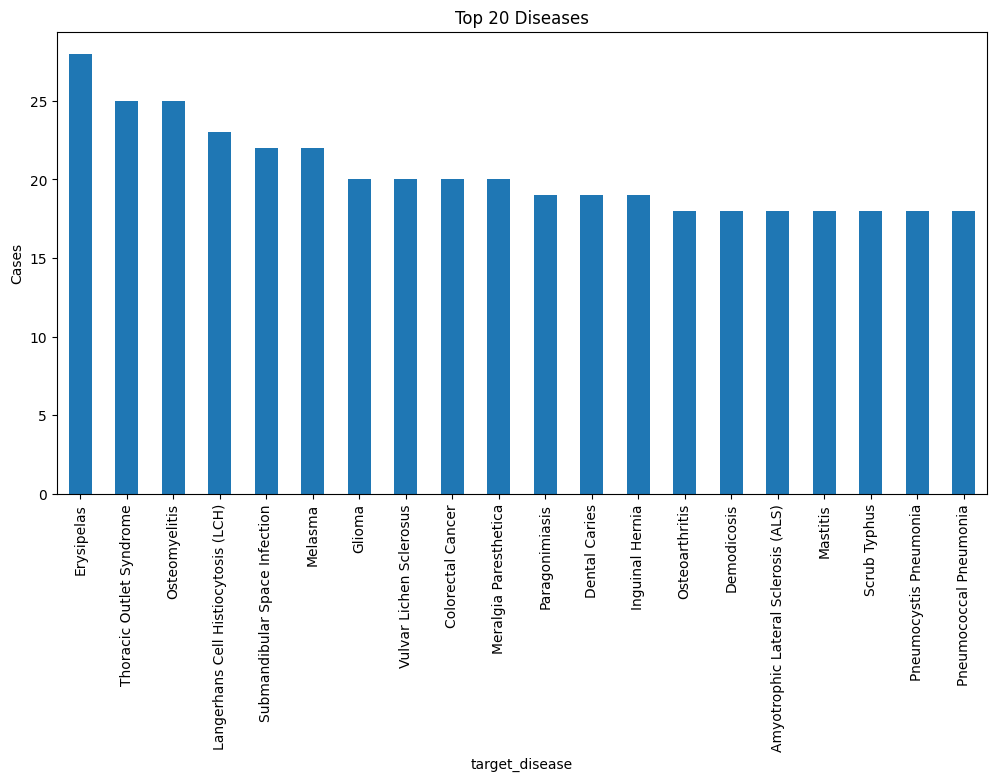

In [ ]:
plt.figure(figsize=(12,6))

disease_counts = (
    df["target_disease"]
    .value_counts()
)
disease_counts.head(20).plot(kind="bar")


plt.title("Top 20 Diseases")
plt.ylabel("Cases")
plt.show()

The graph shows that **no single disease dominates the dataset**, with even the most frequent diseases represented by only a few dozen cases. This indicates a broad and highly granular distribution, consistent with a complex multiclass diagnostic problem.

In [ ]:
print("Most frequent disease:")
print(disease_counts.head())

print("\nLeast frequent disease:")
print(disease_counts.tail())

Most frequent disease:
target_disease
Erysipelas                             28
Thoracic Outlet Syndrome               25
Osteomyelitis                          25
Langerhans Cell Histiocytosis (LCH)    23
Submandibular Space Infection          22
Name: count, dtype: int64

Least frequent disease:
target_disease
Congenital Bronchogenic Cyst    1
Asphalt Poisoning               1
Pleomorphic Adenoma             1
Pediatric Summertime Fever      1
Thoracic Duct Injury            1
Name: count, dtype: int64


The distribution exhibits a typical long-tail pattern: a few diseases have multiple examples, while many are represented by only one or a few cases. This high class imbalance supports the use of an embedding-based retriever with contrastive learning, which is better suited to handling rare diseases than a traditional supervised classifier.

#### Symptoms
Here, we focus on analyzing the symptoms present in the dataset.

In [ ]:
df["n_explicit"] = df["explicit_symptom"].apply(len)

df["n_explicit"].describe()

,n_explicit
count,39149.000000
mean,2.182125
std,1.127300
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,6.000000


Each patient presents on average just over two explicit symptoms, with a minimum of one and a maximum of six. This indicates that the diagnostic process generally starts with limited information, making subsequent iterative reasoning necessary.

In [ ]:
df["n_implicit"] = df["implicit_symptom"].apply(len)

df["n_implicit"].describe()

,n_implicit
count,39149.000000
mean,2.862117
std,0.518969
min,1.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,6.000000


Implicit symptoms represent information that the model can only obtain through dialogue with the patient. The dataset contains an average of about three implicit symptoms per case, a slightly higher number than explicit symptoms.

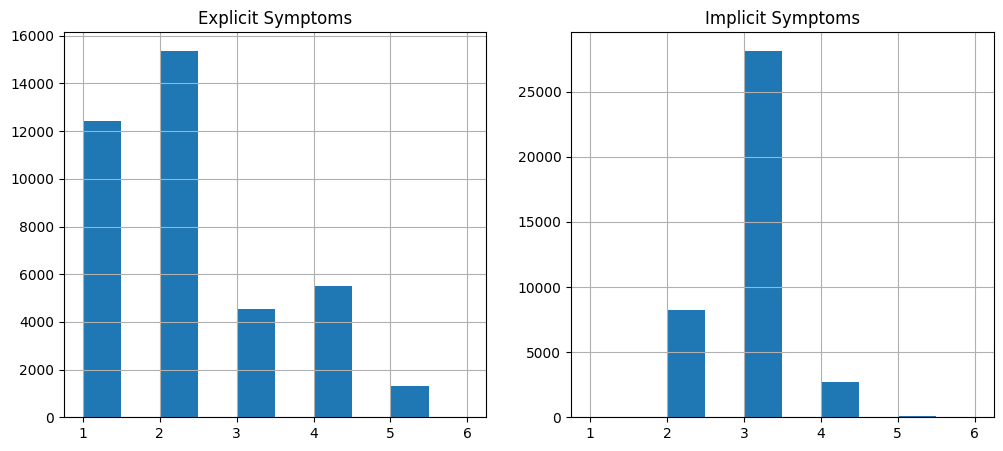

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

df["n_explicit"].hist(ax=ax[0])
ax[0].set_title("Explicit Symptoms")

df["n_implicit"].hist(ax=ax[1])
ax[1].set_title("Implicit Symptoms")

plt.show()

Descriptive statistics alone do not allow us to observe the shape of the distribution. Histograms, however, reveal that most cases contain a limited number of symptoms, reflecting realistic clinical scenarios where diagnoses must be inferred from partial information rather than exhaustive descriptions.

In [ ]:
counter = Counter()

for symptoms in df["explicit_symptom"]:
    counter.update(symptoms)

top_symptoms = pd.DataFrame(
    counter.most_common(20),
    columns=["symptom","count"]
)

top_symptoms

,symptom,count
0,Child,5386
1,Fever,1483
2,Abdominal pain,1399
3,Headache,1055
4,Pain,999
5,Fatigue,932
6,Vomiting,895
7,Dizziness,739
8,Cough,730
9,Newborn,719


Among the most frequent symptoms are very **generic manifestations**, such as *Fever*, *Abdominal Pain*, *Headache* and *Fatigue*, together with some **demographic information** such as *Child*, *Newborn*, *Female* and *Elderly*, which in the dataset are treated as clinically relevant attributes.

#### Conversations
Let's see if we can also find useful information from the conversations reported in the dataset.

In [ ]:
df["conversation"] = (
    df["CoD_conversations"]
    .apply(json.loads)
)

In [ ]:
df["n_turns"] = df["conversation"].apply(len)

df["n_turns"].describe()

,n_turns
count,39149.000000
mean,4.535442
std,2.927184
min,2.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,22.000000


The conversations averaged approximately 4.5 turns, with dialogues ranging from a minimum of 2 to 22 turns. This confirms that the dataset contains both very simple cases and cases that require numerous interactions before reaching a final diagnosis.

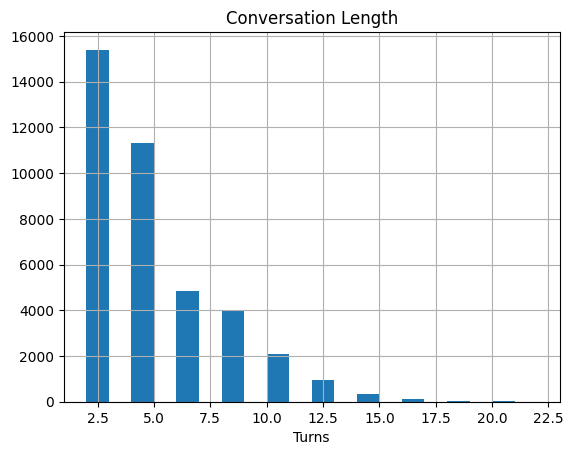

In [ ]:
df["n_turns"].hist(bins=20)

plt.title("Conversation Length")
plt.xlabel("Turns")
plt.show()

Most cases involve a small number of turns, while only a small portion require very long conversations.

One of the distinctive aspects of the Chain of Diagnosis framework is that the model does not immediately produce a diagnosis, but progressively collects new information. Now let's count, for each conversation, how many times the model decides to perform an INQUIRY, that is, to ask the patient further questions before formulating the diagnosis.

In [ ]:
def count_inquiries(conv):

    n = 0

    for turn in conv:

        if (
            turn["from"] == "gpt"
            and turn.get("decision") == "inquiry"
        ):
            n += 1

    return n

df["n_inquiries"] = (
    df["conversation"]
    .apply(count_inquiries)
)

df["n_inquiries"].describe()

,n_inquiries
count,39149.000000
mean,1.267721
std,1.463592
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,10.000000


On average, conversations contain little more than one inquiry, but there are cases where the model asks no additional questions at all, and others where it asks up to ten inquiries. This confirms that the number of interactions depends on the difficulty of the clinical case and the model's level of uncertainty.

In [ ]:
def reasoning_length(conv):
    lengths = []
    for turn in conv:
        if (
            turn["from"] == "gpt"
            and "diagnostic_reasoning" in turn
        ):

            lengths.append(
                len(
                    turn["diagnostic_reasoning"]
                    .split()
                )
            )
    return np.mean(lengths)

df["reasoning_words"] = (
    df["conversation"]
    .apply(reasoning_length)
)

df["reasoning_words"].describe()

,reasoning_words
count,39149.000000
mean,148.890669
std,23.888172
min,28.000000
25%,134.000000
50%,149.000000
75%,163.500000
max,328.000000


Explicit reasoning is one of the most important pieces of information to learn during fine-tuning. The analysis shows that the dataset contains detailed diagnostic explanations rather than simple labels. With an average of 149 words per reasoning statement, it provides rich decision-making traces suitable for LLM fine-tuning.

#### Confidence
The Chain of Diagnosis not only produces a diagnosis, but associates a confidence distribution with each hypothesis. We are going to look at the confidence of the model that generated the data.

In [ ]:
def max_confidence(conv):
    vals = []
    for turn in conv:
        if (
            turn["from"] == "gpt"
            and "confidence_assessment" in turn
        ):
            vals.append(
                max(
                    turn["confidence_assessment"]
                    .values()
                )
            )
    return np.mean(vals) if vals else np.nan

df["avg_max_confidence"] = (
    df["conversation"]
    .apply(max_confidence)
)

df["avg_max_confidence"].describe()

,avg_max_confidence
count,39149.000000
mean,0.569414
std,0.103033
min,0.275000
25%,0.500000
50%,0.550000
75%,0.600000
max,1.000000


**The average maximum confidence level is approximately 0.57**, indicating moderate certainty. This indicates that the model rarely achieves absolute certainty during its reasoning, preferring to maintain multiple diagnostic hypotheses until further information is gathered.

### Data Preprocessing

The *CoD-PatientSymDisease* dataset was split into training, validation, and test sets using an 80%/10%/10% ratio, respectively.

In [ ]:
# Extract the final ready-to-use train, evaluation, and test datasets
print("DATASET SPLITTING STAGE (80 / 10 / 10)")
# 80% Train, 10% Eval, 10% Test
split_1 = patient_dataset.train_test_split(test_size=0.2, seed=42)
raw_train = split_1["train"]
temp_eval_test = split_1["test"]
split_2 = temp_eval_test.train_test_split(test_size=0.5, seed=42)
raw_eval = split_2["train"]
raw_test = split_2["test"]

DATASET SPLITTING STAGE (80 / 10 / 10)


We map the diseases to their symptoms.

In [ ]:
# Create a fast lookup dictionary mapping Disease Names to their Symptoms
df_diseases = disease_database.to_pandas()
disease_to_symptoms = dict(zip(df_diseases['disease'], df_diseases['common_symptom']))

The `preprocess` function is the main data preparation component of the pipeline. It parses the raw CoD JSON conversations and transforms them into structured inputs for either **Supervised Fine-Tuning (SFT)** or **benchmark evaluation**, depending on the `is_test` flag.

**Test Mode (**`is_test=True`**)**

The function extracts only the information required for autonomous evaluation, bypassing any conversational formatting. Specifically, it returns:
- **Patient Prompt:** The first human message of the conversation;
- **Symptoms:** The combination of the explicit and implicit symptoms provided by the dataset;
- **Target Diagnosis:** The ground-truth disease used for evaluation.

This produces a clean evaluation sample without reasoning or retrieval information.

**Training Mode (**`is_test=False`**)**

For SFT, the function converts the original Chain-of-Diagnosis conversations into a **LLaMA-3-compatible agentic RAG dialogue**, explicitly teaching the model the diagnostic workflow through a structured multi-turn conversation:
- **System Persona:** Injects a system prompt defining the model as a medical assistant that must perform explicit reasoning before answering;
- **Symptom Abstraction:** Forces the assistant to begin each reasoning step by explicitly extracting the patient's symptoms before making diagnostic decisions;
- **Dynamic Retrieval Injection:** Converts the retrieved candidate diseases into a tool message. When the optional `disease_to_symptoms` dictionary is provided, each retrieved disease is enriched with its typical symptoms, teaching the model how to interpret external medical knowledge instead of relying only on disease names;
- **Structured Diagnostic Reasoning:** Combines the diagnostic reasoning, confidence distribution, operational decision (`INQUIRY` or `DIAGNOSIS`), and assistant response into a single structured output. For the final conversational turn, the function automatically appends the highest-confidence disease as the final diagnosis;
- **Selective Label Construction:** Rather than training on the entire conversation, the function masks all non-assistant tokens (`-100`) and computes the loss only over assistant responses, allowing the model to learn exclusively the reasoning and generation process;
- **LLaMA-3 Formatting:** If a tokenizer is provided, the conversation is formatted using LLaMA-3's native `apply_chat_template`, tokenized, and returned with the corresponding labels tensor. Otherwise, a manual LLaMA-3 chat template is generated for inspection and debugging.

In [ ]:
def preprocess(example, tokenizer=None, disease_to_symptoms=None, is_test=False):
    """
    Parses the stringified CoD_conversations and transforms them into a
    LLaMA-3-compatible conversational dataset following an agentic RAG workflow
    (User -> Assistant -> Tool -> Assistant).

    Training mode:
        Converts the original Chain of Diagnosis (CoD) conversations into
        a LLaMA-3 compatible chat format. The retrieved diseases can optionally
        be enriched with their corresponding symptom descriptions before being
        passed to the model.

    Test mode:
        Extracts only the information required for autonomous evaluation,
        namely:
            - the initial patient prompt;
            - the explicit and implicit symptoms;
            - the ground-truth diagnosis.

    Parameters
    ----------
    example : dict
        One dataset example.

    tokenizer : AutoTokenizer, optional
        If provided, the formatted conversation is tokenized and returned
        as model-ready inputs.

    disease_to_symptoms : dict, optional
        Dictionary mapping disease names to their typical symptoms.
        Used to build an enriched retrieval context.

    is_test : bool
        Determines whether the example is prepared for training or
        evaluation.
    """
    # Parse the serialized CoD conversation stored as a JSON string
    try:
        conversations = json.loads(example["CoD_conversations"])
    # Invalid conversations are skipped by returning an empty example
    except json.JSONDecodeError:
        if is_test:
            return {"prompt": "", "symptoms": {}, "disease": ""}
        return {"text": ""}

    # TEST MODE (EVALUATION DATA EXTRACTION)
    if is_test:
        # 1. Extract the initial user prompt (the very first human message)
        initial_prompt = ""
        for turn in conversations:
            if turn.get("from") == "human":
                initial_prompt = turn.get("value", "")
                break

        # 2. Extract symptoms directly from the dataset columns
        explicit_syms = example.get("explicit_symptom") or []
        implicit_syms = example.get("implicit_symptom") or []
        symptoms = explicit_syms + implicit_syms

        # 3. Extract the ground truth diagnosis directly from the column
        target_disease = example.get("target_disease", "")

        return {
            "prompt": initial_prompt,
            "symptoms": symptoms,
            "disease": target_disease
        }

    # TRAINING MODE (DATASET FORMATTING)
    # Build a conversation compatible with the LLaMA-3 chat template.
    # The model is trained to explicitly follow the Chain of Diagnosis:
    #
    #   Patient question
    #          ↓
    #   Symptom abstraction
    #          ↓
    #   Tool retrieval (FAISS)
    #          ↓
    #   Diagnostic reasoning
    #          ↓
    #   Confidence estimation
    #          ↓
    #   Inquiry or Final Diagnosis
    messages = [
        {
            "role": "system",
            "content": "You are a medical AI assistant designed to provide accurate and comprehensive information on medical conditions. You must include reasoning steps before answering."
        }
    ]

    # Iterate through every conversational turn
    for i, turn in enumerate(conversations):
        role = turn.get("from")

        # Human messages become user messages in the chat template
        if role == "human":
            patient_query = turn.get("value", "")

            # Append the pure patient query
            messages.append({
                "role": "user",
                "content": patient_query
            })
        # GPT turns contain the complete CoD reasoning process
        elif role == "gpt":
            symptoms_abstracted = turn.get("symptom_abstraction", [])
            retrieved_diseases = turn.get("disease_recall", [])

            # DYNAMIC RAG LOGIC
            if disease_to_symptoms is not None:
                # Enriched RAG: Names + Symptoms
                enriched_diseases_list = []
                for d in retrieved_diseases:
                    d_name = d.get("disease", "")
                    d_symptoms = disease_to_symptoms.get(
                        d_name,
                        "Symptoms information not available"
                    )
                    enriched_diseases_list.append(
                        f"- {d_name} (Typical symptoms: {d_symptoms})"
                    )

                recalled_diseases_str = "\n".join(enriched_diseases_list)
                tool_content_prefix = "RETRIEVED CANDIDATE DISEASES:\n"

            else:
                # Basic RAG fallback: names only
                recalled_diseases_list = [
                    d.get("disease", "") for d in retrieved_diseases
                ]

                recalled_diseases_str = "\n".join(
                    f"- {name}" for name in recalled_diseases_list
                )

                tool_content_prefix = "RETRIEVED CANDIDATE DISEASES:\n"

            # Extract the remaining CoD reasoning fields
            reasoning = turn.get("diagnostic_reasoning", "")
            confidence_dict = turn.get("confidence_assessment", {})
            decision_type = turn.get("decision", "")
            final_reply = turn.get("value", "")

            # The last GPT turn always corresponds to the final diagnosis
            is_last_turn = (i == len(conversations) - 1)
            decision_type = "DIAGNOSIS" if is_last_turn else "INQUIRY"

            # Step 1: Assistant extracts symptoms
            abstraction_content = (
                f"Thinking Process:\n1. SYMPTOM ABSTRACTION: {symptoms_abstracted}"
            )
            messages.append({
                "role": "assistant",
                "content": abstraction_content
            })

            # Step 2: Tool provides FAISS database recall
            if recalled_diseases_str:
                messages.append({
                    "role": "tool",
                    "name": "disease_retriever_faiss",
                    "content": f"{tool_content_prefix}{recalled_diseases_str}"
                })

            # Step 3: Assistant performs diagnostic reasoning
            assistant_reasoning_content = (
                f"2. DIAGNOSTIC REASONING: {reasoning}\n\n"
                f"Confidence Distribution:\n"
                f"{json.dumps(confidence_dict)}\n\n"
                f"Decision: {decision_type.upper()}\n"
                f"Response: {final_reply}"
            )

            # Step 4: Append final diagnosis if it is the last turn
            if is_last_turn and confidence_dict:
                best_disease = max(confidence_dict, key=confidence_dict.get)
                assistant_reasoning_content += (
                    f"\nFINAL DIAGNOSIS: {best_disease}"
                )

            messages.append({
                "role": "assistant",
                "content": assistant_reasoning_content
            })

    # Manual template fallback handling the tool role
    # Used only when a tokenizer is unavailable
    def apply_manual_template(msgs):
        text = "<|begin_of_text|>"
        for m in msgs:
            text += (
                f"<|start_header_id|>{m['role']}<|end_header_id|>\n\n"
                f"{m['content']}<|eot_id|>"
            )
        return text

    # Apply tokenization for training
    if tokenizer is not None:
        # Format the text using the chat template
        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False
        )

        # Tokenize the text normally
        tokens = tokenizer(
            formatted_text,
            truncation=True,
            max_length=2048,
            add_special_tokens=False
        )

        input_ids = tokens["input_ids"]

        # MANUALLY BUILD THE LABELS TENSOR FOR MULTI-TURN RAG
        # Get the exact token IDs for the assistant header and the end-of-turn token
        assistant_header = tokenizer.encode("<|start_header_id|>assistant<|end_header_id|>\n\n", add_special_tokens=False)
        eot_id = tokenizer.encode("<|eot_id|>", add_special_tokens=False)[0]

        # Start by masking everything with -100
        labels = [-100] * len(input_ids)

        i = 0
        while i < len(input_ids):
            # If we detect the exact start of the assistant's turn
            if input_ids[i:i+len(assistant_header)] == assistant_header:
                # Skip the header itself (we don't train on generating the prompt structure)
                i += len(assistant_header)

                # Unmask everything until we hit the End of Turn token
                while i < len(input_ids) and input_ids[i] != eot_id:
                    labels[i] = input_ids[i]
                    i += 1

                # Include the <|eot_id|> in the loss so the model learns exactly when to stop generating
                if i < len(input_ids) and input_ids[i] == eot_id:
                    labels[i] = input_ids[i]
                    i += 1
            else:
                i += 1

        tokens["labels"] = labels
        return tokens

    else:
        # Just text for inspection
        formatted_text = apply_manual_template(messages)
        return {"text": formatted_text}

This stage preprocesses the raw datasets and caches the results. If processed datasets already exist, they are loaded from disk, otherwise the `preprocess` function is applied to create training, evaluation, and test datasets. Training and evaluation splits are formatted for model fine-tuning, while the test split is prepared for autonomous evaluation.

In [ ]:
print("DATA PREPROCESSING STAGE")

# Define the paths for the cached datasets
train_cache_path = os.path.join(dataset_dir, "processed_train")
eval_cache_path = os.path.join(dataset_dir, "processed_eval")
test_cache_path = os.path.join(dataset_dir, "processed_test")

# Check if the processed datasets already exist on disk
if os.path.exists(train_cache_path) and os.path.exists(eval_cache_path) and os.path.exists(test_cache_path):
    print("Found previously processed datasets. Loading directly from disk...")
    train = load_from_disk(train_cache_path)
    eval = load_from_disk(eval_cache_path)
    test = load_from_disk(test_cache_path)
    print(" -> Datasets loaded successfully!")
else:
    print("No cached datasets found. Starting full preprocessing pipeline...")

    # Preprocess Train, Evaluation and Test
    train = raw_train.map(lambda x: preprocess(x, tokenizer, disease_to_symptoms), num_proc=1)
    eval = raw_eval.map(lambda x: preprocess(x, tokenizer, disease_to_symptoms), num_proc=1)
    test = raw_test.map(
        lambda x: preprocess(x, tokenizer, disease_to_symptoms, is_test=True),
        remove_columns=raw_test.column_names,
        num_proc=1
    )

    # Save the processed datasets to disk for future runs
    print("\nSaving processed datasets to cache directory...")
    train.save_to_disk(train_cache_path)
    eval.save_to_disk(eval_cache_path)
    test.save_to_disk(test_cache_path)
    print(" -> Datasets saved successfully!")

print(f"Training set size: {len(train)} cases")
print(f"Evaluation set size: {len(eval)} cases")
print(f"Test set size: {len(test)} cases")

DATA PREPROCESSING STAGE
Found previously processed datasets. Loading directly from disk...
 -> Datasets loaded successfully!
Training set size: 31319 cases
Evaluation set size: 3915 cases
Test set size: 3915 cases


This cell **decodes** the first training sample's tensor (`input_ids`) back into *human-readable text*. It is a debugging step to verify that the LLaMA-3 Chat Template was applied correctly before training.

In [ ]:
print("="*50)
print("SAMPLE DECODED TEXT FROM TRAIN SET:")
print("="*50 + "\n")

# Extract the list of integer token IDs for the first example
token_ids = train[0]["input_ids"]

# Decode the numbers back into a human-readable string
decoded_text = tokenizer.decode(token_ids, skip_special_tokens=False)

print(decoded_text)
print("\n" + "="*50)

SAMPLE DECODED TEXT FROM TRAIN SET:

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 21 Jul 2026

You are a medical AI assistant designed to provide accurate and comprehensive information on medical conditions. You must include reasoning steps before answering.<|eot_id|><|start_header_id|>user<|end_header_id|>

Hello doctor, I’m calling about my child. They have been feeling very tired and have been showing some swelling in their belly. They also seem to bruise easily and their skin and eyes have turned yellow. We’re really worried about them.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Thinking Process:
1. SYMPTOM ABSTRACTION: ['Ascites', 'Tendency to bleed', 'Biliary obstruction', 'Lethargy', 'Child']<|eot_id|><|start_header_id|>ipython<|end_header_id|>

"RETRIEVED CANDIDATE DISEASES:\n- Biliary Atresia (Typical symptoms: Jaundice, dark urine similar to strong tea, hepatosplenomegaly, lethargy, malnutrition, a

The text confirms the raw JSON was perfectly transformed into the rigid Agentic RAG workflow:
- **Special Tokens:** LLaMA-3 control tags (e.g., `<|start_header_id|>`, `<|eot_id|>`) are properly placed.
- **Role Chaining:** Flawless transitions between the `system`, `user`, `assistant`, and `ipython` (simulated tool) roles.
- **Context Injection:** The simulated tool successfully inserts the candidate diseases and their typical symptoms.
- **Strict Formatting:** The assistant perfectly adheres to the required CoD schema, outputting the reasoning, JSON confidence distribution, decision, and final diagnosis in the exact expected order.

## RAG System

The objective of this component is to develop a **RAG system** that functions as a **Disease Retriever** by taking a set of symptoms as input and implementing Phase 2 (*Candidate Disease Recall*) of the CoD pipeline. To achieve this, we propose a **Learning-to-Rank** architecture consisting of 4 stages:
1. an initial retrieval and scoring step performed by a FAISS index with embeddings from a fine-tuned Bi-Encoder;
2. a refinement stage based on the BM25 ranking algorithm;
3. a mathematical penalization stage that dynamically subtracts scores from candidate diseases matching the patient's explicitly negated symptoms;
4. a final reranking stage using a Cross-Encoder.
The primary objective is to maximize the *Recall@3* metric, ensuring that the correct diagnosis is included among the top three retrieved candidate diseases as frequently as possible.

Difference between the two types of Encoders:
- A **Bi-Encoder** processes the input (a query and a document) independently. The query (**patient symptoms**) and the document (**disease**) are passed separately through the same Encoder to generate **two dense embeddings**. Since the two representations do not interact during encoding, their similarity is computed only at the end using **Cosine Similarity**. This approach is highly efficient because document embeddings can be precomputed offline, indexed, and retrieved in milliseconds. Therefore, Bi-Encoders are ideal for the **first stage of an Information Retrieval System**, where low latency is essential.
- A **Cross-Encoder** jointly processes the query (**patient symptoms**) and the document (**disease**) by concatenating them as a single input: `[CLS] query [SEP] document [SEP]`. Through **self-attention**, every token can interact with all tokens from both texts, allowing the model to directly compute a relevance score instead of separate embeddings. This provides higher accuracy but is computationally expensive, as scores cannot be precomputed and each query-document pair must be processed individually. Therefore, Cross-Encoders are typically used in the **Re-Ranking stage of a Learning-to-Rank system**.

This cell prepares the disease catalog for the vector database using task-specific instructions:
* **Asymmetric Rationale**: Uses `QUERY_PREFIX` and `DOC_PREFIX` to align conversational user queries with encyclopedic database documents using Bi-Encoders;
* **Text Enrichment**: `create_rich_disease_text` merges prefixes, disease names, and symptoms into standardized text profiles;
* **Indexing**: Creates a reverse lookup dictionary (`disease_name_to_idx`) for downstream evaluation tracking.


In [ ]:
# Asymmetric prefixes for a Bi-Encoder embedding model
QUERY_PREFIX = "Diagnose the patient based on these symptoms: "
DOC_PREFIX = "Disease overview and typical symptoms: "

def create_rich_disease_text(disease_name: str, disease_symptoms_dict: dict) -> str:
    """Formats the document text with the specific prefix for the vector database."""
    symptoms = disease_symptoms_dict.get(disease_name, "N/A")
    return f"{DOC_PREFIX}{disease_name}. Symptoms: {symptoms}"

# Generate enriched text columns by mapping diseases to their symptoms
df_diseases["rich_text"] = df_diseases.apply(
    lambda row: create_rich_disease_text(row['disease'], disease_to_symptoms), axis=1
)

# Convert dataframe columns into native python lists for the RAG pipeline
database_documents = df_diseases["rich_text"].tolist()
disease_names = df_diseases["disease"].tolist()

# Reverse mapping dictionary (Disease Name -> Index) for quick retrieval evaluation
disease_name_to_idx = {name: i for i, name in enumerate(disease_names)}

Extracts `[Anchor, Positive, Hard Negative]` training triplets from raw conversation logs for contrastive fine-tuning.

We define the core components of contrastive learning triplets using a concrete clinical scenario:
-  **Anchor (The Query):** The synthesized input we want the model to understand and embed. Example: The patient's extracted and accumulated symptoms ("Diagnose the patient based on these symptoms: vomiting, jaundice, fever").
- **Positive (The Ground Truth):** The absolute correct document that must be pulled closer to the Anchor in the vector space. Example: The rich text profile of the actual target disease ("Pediatric Hepatitis C").
- **Hard Negative (The Distractor):** A highly plausible but incorrect document that shares significant semantic overlap with the Anchor. In the medical domain, this concept is crucial: diseases often share 90% of base symptoms (e.g., fever, fatigue). Forcing the model to contrast against [Hard Negatives](https://arxiv.org/abs/2104.08051) trains it to focus on the 10% of differential symptoms, preventing generic or superficial diagnoses. Example: A related liver condition the LM mistakenly retrieved ("Pediatric Acute Cholecystitis").

Instead, the function `extract_triplets_from_dataset` simply does this:
* **Target Alignment**: Maps queries directly to the `target_disease` metadata instead of noisy LLM predictions;
* **Hard Negative Grouping**: Appends multiple hard negatives inside the same `InputExample` instance to enhance contrastive learning;
* **Data Cleansing**: Filters out unreliable/empty ground truths and lowercase-normalizes symptom text to prevent duplicate tracking.


In [ ]:
def extract_triplets_from_dataset(dataset_split, disease_symptoms_mapping, unreliable_diseases=None):
    """
    Constructs high-quality training triplets [Anchor, Positive, HardNegative_1, ..., HardNegative_n]
    for Contrastive Learning. We are actively preventing vector space degradation by aggressively
    filtering out noisy ground truths and enforcing strict casing normalization to build clean,
    deduplicated symptom profiles.
    """
    unreliable_diseases = unreliable_diseases or set()
    examples = []

    for item in dataset_split:
        try:
            conversations = json.loads(item["CoD_conversations"])
        except json.JSONDecodeError:
            continue

        # This ensures our positive document is always factually anchored to the real patient case
        ground_truth_disease = item.get("target_disease")

        accumulated_symptoms = set()
        recalled_diseases = []

        for turn in conversations:
            if turn.get("from") == "gpt":
                # We iteratively harvest positive symptoms across the entire dialogue.
                # This creates a pristine, highly representative clinical anchor query.
                if "symptom_abstraction" in turn:
                    pos_sym = [s.strip().lower() for s in turn["symptom_abstraction"]
                               if not s.strip().lower().startswith(('no ', 'without '))]
                    accumulated_symptoms.update(pos_sym)

                # These are the ultimate "hard negatives" because they share high semantic overlap
                # with the true disease, forcing the retriever to learn fine-grained boundaries during
                # the MultipleNegativesRankingLoss phase.
                if "disease_recall" in turn:
                    for d in turn["disease_recall"]:
                        d_name = d.get("disease", "")
                        if d_name and d_name not in recalled_diseases:
                            recalled_diseases.append(d_name)

        if accumulated_symptoms and recalled_diseases:
            final_anchor_query = QUERY_PREFIX + ", ".join(list(accumulated_symptoms))
            positive_doc = create_rich_disease_text(ground_truth_disease, disease_symptoms_mapping)

            # We safely sanitize the hard negatives pool by explicitly removing the ground truth
            hard_negatives = [d for d in recalled_diseases
                               if d != ground_truth_disease and d not in unreliable_diseases]

            # We are structuring the data for advanced contrastive loss functions.
            if hard_negatives:
                hn_docs = [create_rich_disease_text(hn, disease_symptoms_mapping)
                           for hn in hard_negatives[:3]]
                examples.append(InputExample(texts=[final_anchor_query, positive_doc] + hn_docs))

    total = len(dataset_split)
    print(f"  -> Extracted {len(examples)} triplets from {total} raw cases "
          f"({len(examples)/max(total,1):.1%} yield).")
    return examples

The AI Agent needs a "*search engine*" to find the right diseases in the database based on the patient's symptoms. This code creates and trains that search engine and handles the contrastive optimization loop for the Bi-Encoder model.

`SentenceTransformer` (the Bi-Encoder model) is a popular Python library (based on HuggingFace) designed specifically to convert sentences or entire paragraphs into **Embeddings** (Dense Vectors). We fine-tune the base `S-PubMedBert` model using Automatic Mixed Precision (AMP) and a warm-up schedule over 10 epochs.  

The code trains the model through **Contrastive Learning**, using the `MultipleNegativesRankingLoss` function. The goal is not to teach it to generate text, but to optimize the vector space of representations (*embeddings*). During training, the model receives an anchor (the patient's symptoms), a positive (the document for the correct disease), and several hard negatives (similar but incorrect diseases). The model's weights are then updated to bring the representation of the correct document closer and move away from those of the irrelevant documents in the batch. The loss function for a single case $i$ within a batch of size $N$, in our case, is expressed like this:
$$\mathcal{L}_i = - \log \frac{\exp(\text{sim}(a_i, p_i) \cdot s)}{\sum_{j=1}^{N} \exp(\text{sim}(a_i, p_j) \cdot s) + \sum_{k=1}^{K} \exp(\text{sim}(a_i, n_{i,k}) \cdot s)}$$
Where:
- $a_i$: Anchor embedding (patient symptoms);
- $p_i$: Positive embedding (correct disease);
- $p_j$: Other batch positives used as In-batch Negatives (irrelevant "free" documents);
- $n_{i,k}$: Hard negative embeddings (similar but incorrect diseases);
- $\text{sim}(\cdot,\cdot)$: Cosine similarity in our case;
- $s$: Scaling factor (default: 20 in SentenceTransformers), which sharpens the softmax distribution and improves gradient optimization.


The `Information Retrieval Evaluator` is the component that measures the retriever's performance during fine-tuning. At regular intervals, it temporarily pauses training and runs a full document search simulation on the validation set. The Evaluator then compares the resulting ranking with the ground truth and calculates various information retrieval metrics, such as NDCG, Recall@K, MRR, and MAP, which measure how high the correct document is ranked.

The evaluation is based on three fundamental structures:
- **Corpus:** maps each disease to a unique identifier and represents the entire search space (*Disease Database*), ensuring a realistic evaluation of the retrieval metrics;
- **Queries:** associates an identifier with the symptoms of patients in the *Validation set*;
- **Relevant Docs:** defines, for each query, the correct document (ground truth). Always taken from the *Validation set*.

During evaluation, the model encodes queries and corpus embeddings, retrieves the most similar documents, and compares the resulting ranking with the ground truth.

We iterate through the *val_examples* (which are `InputExample` objects, a class used to represent a single training example for an embedding model) to extract the clean text query and the exact ground-truth disease, structuring them into a list of tuples for evaluation. It is used to train a `SentenceTransformer` model to produce embeddings where similar sentences have neighboring vectors.

In [ ]:
# Define where the fine-tuned retriever and its evaluation metrics will be stored.
# If the model already exists, training can be skipped and the saved metrics reused.
save_path = os.path.join(cache_dir, "medical_retriever_pubmedbert_finetuned")
metrics_file = os.path.join(save_path, "evaluation_metrics.json")

# Build the validation triplets
# Each triplet contains:
# - Anchor = patient symptoms
# - Positive = correct disease document
# - Hard Negatives = semantically similar but incorrect disease documents
print("Extracting validation triplets...")
val_examples = extract_triplets_from_dataset(eval, disease_to_symptoms)

# If evaluation metrics already exist, load and display the saved model performance
if os.path.exists(metrics_file):

    with open(metrics_file, "r") as f:
        saved_metrics = json.load(f)

    print("\n" + "="*70)
    print("SAVED MODEL PERFORMANCE (Validation Set)")
    print("="*70)

    # Convert the metrics dictionary into a Pandas DataFrame
    metrics_df = (
        pd.DataFrame(
            saved_metrics.items(),
            columns=["Metric", "Value"]
        )
        .sort_values("Metric")
        .reset_index(drop=True)
    )

    # Format numerical metrics with fixed precision to improve readability
    metrics_df["Value"] = metrics_df["Value"].apply(
        lambda x: f"{x:.6f}" if isinstance(x, (int, float)) else x
    )

    print(metrics_df.to_string(index=False))

    print("="*70 + "\n")

else:
    # No previously fine-tuned model was found
    # Generate the training triplets used for contrastive learning
    print("Fine-tuned model not found. Extracting training triplets...")
    train_examples = extract_triplets_from_dataset(train, disease_to_symptoms)

    # Utility function that prints a few extracted triplets.
    def print_sample_triplets(dataset_examples, dataset_name="Dataset", num_samples=2):
        print(f"\n{'='*50}")
        print(f"INSPECTING {num_samples} SAMPLES FROM: {dataset_name}")
        print(f"{'='*50}")

        if not dataset_examples:
            print(f"Warning: {dataset_name} is empty!")
            return

        for i, example in enumerate(dataset_examples[:num_samples]):
            print(f"\n--- Sample {i+1} ---")
            texts = example.texts
            print(f"[ANCHOR / QUERY] : {texts[0]}")
            if len(texts) > 1:
                print(f"[POSITIVE DOC]   : {texts[1]}")
            for j, hn in enumerate(texts[2:]):
                print(f"[HARD NEG {j+1}]     : {hn}")

        print(f"{'='*50}\n")

    # Display one training example to visually inspect the extracted data.
    print_sample_triplets(train_examples, "TRAINING SET", 1)

    # Sanity check: if too few training triplets were extracted,
    # the dataset structure is probably incorrect (e.g., missing labels).
    if len(train_examples) < 0.05 * len(train):
        raise ValueError(
            "Extraction yield too low (<5%). The ground truth key 'target_disease' "
            "might not exist in this dataset split."
        )

    # Load the domain-specific PubMedBERT bi-encoder that will be fine-tuned
    # SentenceTransformer wraps the encoder and provides training utilities
    print("Initializing Base Model for Full Training...")
    retriever_model = SentenceTransformer("pritamdeka/S-PubMedBert-MS-MARCO", device=DEVICE)

    # Create shuffled mini-batches for stochastic optimization.
    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)

    # MultipleNegativesRankingLoss performs contrastive learning:
    # for each Anchor, the Positive document is pulled closer in the embedding
    # space while every other document in the batch automatically acts as
    # a negative example and is pushed farther away.
    train_loss = losses.MultipleNegativesRankingLoss(model=retriever_model)

    # Build the document corpus used by the IR evaluator
    corpus = {f"doc_{i}": doc for i, doc in enumerate(database_documents)}
    doc_to_id = {doc: f"doc_{i}" for i, doc in enumerate(database_documents)}

    # Create validation queries and their corresponding relevant documents
    queries = {}
    relevant_docs = {}
    # These mappings define the ground truth used during retrieval evaluation
    for i, ex in enumerate(val_examples):
        q_id = f"query_{i}"
        queries[q_id] = ex.texts[0]
        if ex.texts[1] in doc_to_id:
            relevant_docs[q_id] = {doc_to_id[ex.texts[1]]}

    # Configure an Information Retrieval evaluator.
    ir_evaluator = InformationRetrievalEvaluator(
        queries=queries, corpus=corpus, relevant_docs=relevant_docs,
        name='medical-ir-val', ndcg_at_k=[10], mrr_at_k=[10], accuracy_at_k=[1, 3, 5],
        precision_recall_at_k=[1, 3, 10, 50], map_at_k=[100],
        show_progress_bar=True
    )

    # Training configuration
    num_epochs = 10
    warmup_steps = int(len(train_dataloader) * num_epochs * 0.1)
    eval_steps = max(1, int(len(train_dataloader) / 2))

    # Launch the contrastive fine-tuning process.
    print("\nStarting Full Fine-Tuning Process...")
    retriever_model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        evaluator=ir_evaluator,
        evaluation_steps=eval_steps,
        epochs=num_epochs,
        warmup_steps=warmup_steps,
        output_path=save_path,
        save_best_model=True,
        use_amp=True, # The checkpoint with the best validation performance is automatically saved
    )
    print(f"\nTraining Complete. Best model saved to: {save_path}")

    # Reload the best checkpoint instead of the last training state
    print("\nCalculating final metrics on the best saved model...")
    best_model_eval = SentenceTransformer(save_path, device=DEVICE)
    final_metrics = ir_evaluator(best_model_eval)

    # Persist the evaluation metrics so future executions can reuse them
    with open(metrics_file, "w") as f:
        json.dump(final_metrics, f, indent=4)
    print(f"Metrics successfully saved to: {metrics_file}")

# Load the final best optimized embedding model
embedding_model = SentenceTransformer(save_path, device=DEVICE)

Extracting validation triplets...
  -> Extracted 3915 triplets from 3915 raw cases (100.0% yield).

SAVED MODEL PERFORMANCE (Validation Set)
                            Metric    Value
  medical-ir-val_cosine_accuracy@1 0.432950
  medical-ir-val_cosine_accuracy@3 0.579566
  medical-ir-val_cosine_accuracy@5 0.635504
     medical-ir-val_cosine_map@100 0.527944
      medical-ir-val_cosine_mrr@10 0.520337
     medical-ir-val_cosine_ndcg@10 0.566079
 medical-ir-val_cosine_precision@1 0.432950
medical-ir-val_cosine_precision@10 0.071137
 medical-ir-val_cosine_precision@3 0.193189
medical-ir-val_cosine_precision@50 0.017134
    medical-ir-val_cosine_recall@1 0.432950
   medical-ir-val_cosine_recall@10 0.711367
    medical-ir-val_cosine_recall@3 0.579566
   medical-ir-val_cosine_recall@50 0.856705



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Notice that the Accuracy and Recall metrics yield identical values. This mathematical equivalence occurs because our dataset is structured with exactly one ground-truth disease (relevant document) per clinical case (query).To understand why this happens, we can look at the standard definitions of these metrics:
- **Accuracy:** Measures the proportion of queries where the system's prediction is correct.$$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Queries}}$$
- **Recall:** Measures the fraction of all actual relevant documents that the system successfully retrieves.$$\text{Recall} = \frac{\text{Relevant Documents Retrieved}}{\text{Total Relevant Documents}}$$

Because there is **only one relevant document** (the true target disease) for any given patient query, the denominator for Recall is always 1. Thus, for any individual query, the Recall calculation collapses into a binary outcome:
$$\text{Recall} = \begin{cases} \frac{1}{1} = 1 & \text{if the relevant document is retrieved} \\ \frac{0}{1} = 0 & \text{otherwise} \end{cases}$$
This exact same logic applies to the @3 (Top-3) variations. Accuracy@3 evaluates whether the correct disease appears anywhere within the top 3 retrieved spots. Recall@3 evaluates the fraction of relevant documents found in those top 3 spots. Since there is only one disease to find:
$$\text{Recall@3} = \begin{cases} \frac{1}{1} = 1 & \text{if the relevant document is in the top 3} \\ \frac{0}{1} = 0 & \text{otherwise} \end{cases}$$
Consequently, averaging these binary Recall scores across the entire validation dataset mathematically yields the exact same percentage as calculating the overall Accuracy.

**We will continue to use the term Recall@3 to maintain a parallel with the term used by the study.**

**FAISS** (*Facebook AI Similarity Search*) is the standard for similarity search and dense vector clustering. When texts are converted into embeddings, each element is represented as a point in a multidimensional vector space. FAISS indexes these vectors and quickly finds the ones most similar to a query using metrics such as cosine similarity. In the system, it compares the symptoms extracted from the model with the database of 9,604 diseases, returning the most relevant candidates for subsequent reranking. FAISS is our **Main Semantic Search Engine** (*Dense Retriever*). We take the *Disease Database* and run it through the newly trained `PubMedBERT`, which "reads" each row and converts it into a dense vector (an array of mathematical coordinates of 768 numbers).

This cell builds the complete retrieval architecture by combining dense semantic search, sparse lexical search, and a neural re-ranker:
* **Dense Engine (FAISS)**: Vectorizes the disease catalog and constructs an `IndexFlatIP` index using $L_2$ normalized embeddings for cosine similarity;
* **Sparse Engine (BM25)**: Tokenizes the document corpus to build a lexicon index using the `BM25Okapi` algorithm for keyword-based exact matching;
* **Neural Re-ranker**: Loads a generic `CrossEncoder` (`ms-marco-MiniLM-L-6-v2`) to perform high-precision Stage-2 relevance sorting.

In [ ]:
# Compute embeddings for all disease documents using the fine-tuned bi-encoder
print(f"Vectorizing {len(database_documents)} diseases...")
disease_vectors = embedding_model.encode(
    database_documents, batch_size=32, convert_to_numpy=True, show_progress_bar=True
)
# Normalize vectors to unit length to calculate Cosine Similarity via Inner Product
faiss.normalize_L2(disease_vectors)

# Initialize and populate the dense vector index using FAISS
vector_dimension = disease_vectors.shape[1]
vector_index = faiss.IndexFlatIP(vector_dimension)
vector_index.add(disease_vectors)
print("Dense Search engine (FAISS) ready!")

# Tokenize corpus to build the sparse lexicon index for keyword-based search
print("Building BM25 Index for Hybrid Retrieval...")
tokenized_corpus = [doc.lower().split() for doc in database_documents]
bm25_index = BM25Okapi(tokenized_corpus)
print("Sparse Search engine (BM25) ready!")
# Load a pre-trained Cross-Encoder to act as the Stage-2 neural re-ranker
print("Loading Cross-Encoder for Stage-2 Re-ranking...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device=DEVICE)
print("Cross-Encoder ready!")

Vectorizing 9620 diseases...


Batches:   0%|          | 0/301 [00:00<?, ?it/s]

Dense Search engine (FAISS) ready!
Building BM25 Index for Hybrid Retrieval...
Sparse Search engine (BM25) ready!
Loading Cross-Encoder for Stage-2 Re-ranking...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-Encoder ready!


**BM25** is an information retrieval algorithm that estimates the relevance of a document to a specific search. Its formula is as follows:
$$\text{BM25}(t, d) = \text{IDF}_{\text{BM25}}(t) \cdot \text{TF}_{\text{norm}}(t, d)$$

Where:
- **Inverse Document Frequency:**
$$\text{IDF}_{\text{BM25}}(t) = \ln \left( \frac{N - \text{df}(t) + 0.5}{\text{df}(t) + 0.5} + 1 \right)$$
- **Term Frequency Saturation & Length Normalization:**
$$\text{TF}_{\text{norm}}(t, d) = \frac{\text{tf}_{t,d} \cdot (k_1 + 1)}{\text{tf}_{t,d} + k_1 \cdot \left( 1 - b + b \cdot \frac{\text{len}(d)}{\text{avgdl}} \right)}$$


Here:
- $t$ represents a token (keyword extracted from the symptom query, e.g., "fever" or "cough");
- $d$ represents a document (a disease description stored in database_documents);
- $k_1$: term frequency saturation parameter (defaulted to `1.5`);
- $b$: document length normalization parameter (defaulted to `0.75`);
- $\text{avgdl}$: average document length across the entire collection.

$\text{BM25}(t,d)$ is the contribution of symptom $t$ to the relevance score of disease $d$.

Implements a granular utility function to query the FAISS database with candidate filtering capabilities.

* **Conditioned Inferences**: Dynamically handles constrained candidate inputs by reconstructing local vector pools using exact matrix multiplication (`@`);
* **Global Search**: Fallbacks to standard vector search (`vector_index.search`) across the entire corpus when no local tracking restrictions are provided.


In [ ]:
def dense_search(vector_index, q_vec_row: np.ndarray, restrict_idx=None, top_k: int = 30) -> dict:
    """Helper for dense search, supporting candidate conditioning."""
    # If a subset of candidate IDs is provided, perform an exact matrix multiplication
    if restrict_idx is not None:
        # Reconstruct vectors from FAISS index for the specific candidate subset
        sub_vectors = np.vstack([vector_index.reconstruct(int(i)) for i in restrict_idx])
        # Compute cosine similarity via dot product on normalized embeddings
        scores = sub_vectors @ q_vec_row
        return {int(i): float(s) for i, s in zip(restrict_idx, scores)}
    # Otherwise, execute a global standard index scan across the entire database
    else:
        scores, indices = vector_index.search(q_vec_row.reshape(1, -1), top_k)
        return {int(idx): float(scores[0][i]) for i, idx in enumerate(indices[0])}

We implement a **Learning to Rank Pipeline** with our Dense Retriever, BM25 and a Cross-Encoder. We merge dense semantic hits from FAISS with sparse token hits from BM25 to build a robust initial candidate pool. It batch-encodes a secondary query string to penalize candidates matching the patient's explicitly negated symptoms. The merged candidate pool is passed through the Cross-Encoder to compute deep query-document cross-attentions for final ranking.

In [ ]:
def retrieve_top_k_diseases(
    faiss_module, symptom_text: str, embedding_model,
    vector_index, disease_names: list, disease_name_to_idx: dict,
    database_documents: list, query_prefix: str,
    cross_encoder=None, bm25_index=None, k: int=5,
    negation_weight: float=0.3, query_neg: str=None,
    candidate_diseases: list=None, rerank_pool: int=50,
    cross_weight: float=1.0
) -> list:
    """
    Executes a multi-stage retrieval pipeline:
    1. Dense Semantic Search (FAISS) for positive symptoms.
    2. BM25 Lexical Search for exact keyword matching (Hybrid Fusion).
    3. Mathematical Penalization using a secondary FAISS query for negated symptoms.
    4. Neural Re-ranking via Cross-Encoder (with Late Fusion / Score Interpolation).
    """
    # STAGE 0: INITIALIZATION
    if not symptom_text:
        return []

    # Map the provided list of candidate disease strings to their corresponding integer IDs.
    restrict_idx = None
    if candidate_diseases:
        restrict_idx = [disease_name_to_idx[d] for d in candidate_diseases if d in disease_name_to_idx]
        if not restrict_idx:
            restrict_idx = None

    # Construct the queries for the embedding model
    queries_to_encode = [query_prefix + symptom_text]
    if query_neg:
        queries_to_encode.append(query_prefix + f"{symptom_text}, {query_neg}")

    encoded = embedding_model.encode(queries_to_encode, convert_to_numpy=True)
    faiss_module.normalize_L2(encoded)

    # Retrieve a larger candidate pool before final ranking
    pool_size = len(restrict_idx) if restrict_idx is not None else rerank_pool

    # STAGE 1: DENSE SEMANTIC RETRIEVAL WITH FAISS
    # Perform the initial dense retrieval passing the vector_index
    dense_results = dense_search(vector_index, encoded[0], restrict_idx, top_k=pool_size)

    # STAGE 2: HYBRID FUSION WITH BM25 LEXIACL RETRIEVAL
    # We use BM25 only if the index is provided and we aren't restricting to specific candidates
    if bm25_index is not None and restrict_idx is None:
        tokenized_query = symptom_text.lower().split()
        bm25_scores = bm25_index.get_scores(tokenized_query)
        # Retrieve the top N sparse results
        sparse_indices = np.argsort(bm25_scores)[::-1][:pool_size]

        min_dense = min(dense_results.values()) if dense_results else 0

        for idx in sparse_indices:
            # If BM25 found it but FAISS didn't, add it with a fallback score
            if idx not in dense_results:
                dense_results[idx] = min_dense - 0.1
            # If BOTH found it, boost the score slightly to reward consensus
            else:
                dense_results[idx] += 0.05

    # STAGE 3: PENALIZE DISEASEs MATCHING EXPLICIT ABSENT SYMPTOMS
    if query_neg:
        neg_results = dense_search(vector_index, encoded[1], restrict_idx, top_k=pool_size)
        if neg_results:
            fallback_score = min(neg_results.values())
            for idx in dense_results:
                penalty = neg_results.get(idx, fallback_score)
                dense_results[idx] -= negation_weight * penalty

    if not dense_results:
        return []

    # STAGE 4: NEURAL RE-RANKING
    # We pass ALL candidates (FAISS + BM25) to the Cross-Encoder
    top_pool_indices = list(dense_results.keys())

    # If the cross_encoder model is provided, execute the re-ranking phase
    if cross_encoder is not None and len(top_pool_indices) > 1:
        cross_inp = [[symptom_text, database_documents[idx]] for idx in top_pool_indices]
        cross_scores = cross_encoder.predict(cross_inp)

        # Late Fusion (Score Interpolation)
        # Min-Max Normalize the hybrid dense scores (FAISS + BM25) to [0, 1]
        dense_vals = [dense_results[idx] for idx in top_pool_indices]
        min_d, max_d = min(dense_vals), max(dense_vals)
        range_d = (max_d - min_d) if max_d > min_d else 1.0
        # Min-Max Normalize the Cross-Encoder logits to [0, 1]
        min_c, max_c = min(cross_scores), max(cross_scores)
        range_c = (max_c - min_c) if max_c > min_c else 1.0

        final_scores = {}

        # Mathematical interpolation of the signals using the parameterized cross_weight
        for idx, ce_score in zip(top_pool_indices, cross_scores):
            norm_dense = (dense_results[idx] - min_d) / range_d
            norm_cross = (float(ce_score) - min_c) / range_c
            final_scores[idx] = ((1.0 - cross_weight) * norm_dense) + (cross_weight * norm_cross)
    else:
        # Fallback if no Cross-Encoder is provided
        final_scores = {idx: dense_results[idx] for idx in top_pool_indices}

    # Extract the top 'k' diseases based on the final scores
    sorted_indices = sorted(final_scores, key=final_scores.get, reverse=True)[:k]
    return [{"disease": disease_names[idx], "score": final_scores[idx]} for idx in sorted_indices]

Executes an integration test to validate the full retrieval pipeline using a complex clinical case.

* **Test Scenario**: Evaluation using a high-priority, multi-symptom profile (headache, stiff neck, fever, photophobia).
* **Execution Flow**: Evaluates the simultaneous coordination of FAISS, BM25 tracking, and Cross-Encoder scoring to verify proper system output and confidence metric calibration.

In [ ]:
print("\n" + "="*50)
print("END-TO-END FULL PIPELINE RETRIEVAL TEST ")
print("="*50)

# Define a clinical symptom query case to validate full pipeline behavior
test_query = "severe headache, stiff neck, high fever, sensitivity to light, nausea"
print(f"Patient Symptoms: '{test_query}'\n")
print(f"Retrieving top 3 diseases using the complete 'retrieve_top_k_diseases' function...")

# Execute the complete hybrid retrieval + neural re-ranking workflow
top_predictions = retrieve_top_k_diseases(
    faiss_module=faiss,
    symptom_text=test_query,
    embedding_model=embedding_model,
    vector_index=vector_index,
    disease_names=disease_names,
    disease_name_to_idx=disease_name_to_idx,
    database_documents=database_documents,
    query_prefix=QUERY_PREFIX,
    bm25_index=bm25_index,         # Enabled for Hybrid Fusion
    cross_encoder=cross_encoder,   # Enabled for Stage-2 Re-ranking
    k=3,
    rerank_pool=50
)

# Output predictions ranked by final neural confidence scores
for i, res in enumerate(top_predictions):
    print(f"{i+1}. {res['disease']} (Final Confidence Score: {res['score']:.4f})")
print("="*50 + "\n")


END-TO-END FULL PIPELINE RETRIEVAL TEST 
Patient Symptoms: 'severe headache, stiff neck, high fever, sensitivity to light, nausea'

Retrieving top 3 diseases using the complete 'retrieve_top_k_diseases' function...
1. Staphylococcus Aureus Meningitis (Final Confidence Score: 1.0000)
2. Cerebral Fungal Granuloma (Final Confidence Score: 0.9462)
3. Meningococcal Meningitis (Final Confidence Score: 0.9437)



The `run_ablation_study` function is designed to systematically dismantle the retrieval architecture to **measure the exact contribution of each isolated component**.
It creates an array of dictionaries representing four distinct operational states by selectively injecting the actual model objects or passing None:
1. Full Pipeline (Dense FAISS + BM25 + Cross-Encoder)
2. Dense + Cross-Encoder (BM25 disabled)
3. Dense + BM25 (Cross-Encoder disabled)
4. Dense Only (Absolute baseline)

For each configuration, it executes the retrieval pipeline across the entire validation set. It calculates the *Recall@3* metric by checking if the true_disease is present within the top 3 items returned by the pipeline. This function provides empirical validation for our architectural decisions. By comparing the baseline "Dense Only" configuration with the complete retrieval pipeline, it quantifies the improvement in diagnostic accuracy achieved by incorporating the sparse lexical index (BM25) and the deep neural re-ranker (Cross-Encoder). This analysis demonstrates whether the gains in retrieval quality justify the additional computational costs, including increased latency and memory consumption.

In [ ]:
def run_ablation_study(
    val_examples: list,
    database_documents: list,
    disease_names: list,
    query_prefix: str,
    faiss_module,
    vector_index,
    embedding_model,
    disease_name_to_idx: dict,
    bm25_model,
    cross_encoder_model,
    ablation_dir: str,
    ablation_filename: str = 'ablation_results.json',
    k=3
) -> list:
    """
    Executes an ablation study to evaluate the impact of BM25 and Cross-Encoder
    on the retrieval pipeline's Accuracy/Recall@3.
    Dependencies are fully injected to avoid reliance on global variables.
    """
    ablation_file = os.path.join(ablation_dir, ablation_filename)

    # Load cached results to avoid re-running the expensive evaluation loop
    if os.path.exists(ablation_file):
        print(f"Found cached results! Loading from: {ablation_file}\n")
        with open(ablation_file, 'r') as f:
            ablation_results = json.load(f)
    else:
        print("Preparing Evaluation Dataset for Ablation Study...")

        eval_pairs = []
        doc_to_disease = {doc: name for doc, name in zip(database_documents, disease_names)}

        # Extract clean queries and ground truth diseases for validation
        for ex in val_examples:
            clean_query = ex.texts[0].replace(query_prefix, "").strip()
            positive_doc = ex.texts[1]
            correct_disease = doc_to_disease.get(positive_doc)
            if correct_disease:
                eval_pairs.append((clean_query, correct_disease))

        print(f"Total validation queries ready for testing: {len(eval_pairs)}\n")

        # Define configurations by passing the actual models or None to deactivate them
        ablation_configs = [
            {"name": "Dense + BM25 + CrossEncoder (Full)", "bm25": bm25_model, "ce": cross_encoder_model},
            {"name": "Dense + CrossEncoder (No BM25)",     "bm25": None,       "ce": cross_encoder_model},
            {"name": "Dense + BM25 (No CrossEncoder)",     "bm25": bm25_model, "ce": None},
            {"name": "Dense Only (No BM25, No CE)",        "bm25": None,       "ce": None},
        ]

        ablation_results = []

        # Run retrieval for each configuration and calculate Recall@3
        for cfg in ablation_configs:
            recall_at_3 = 0

            for query, true_disease in tqdm(eval_pairs, desc=cfg["name"]):
                results = retrieve_top_k_diseases(
                    faiss_module=faiss_module,
                    symptom_text=query,
                    embedding_model=embedding_model,
                    vector_index=vector_index,
                    disease_names=disease_names,
                    disease_name_to_idx=disease_name_to_idx,
                    database_documents=database_documents,
                    query_prefix=query_prefix,
                    bm25_index=cfg["bm25"],        # Injects model or None
                    cross_encoder=cfg["ce"],       # Injects model or None
                    k=k,
                    rerank_pool=50
                )

                predicted_diseases = [res["disease"] for res in results]

                if true_disease in predicted_diseases:
                    rank = predicted_diseases.index(true_disease) + 1
                    if rank <= 3:
                        recall_at_3 += 1

            n = len(eval_pairs)
            ablation_results.append({
                "Configuration": cfg["name"],
                "Recall@3": recall_at_3 / n if n > 0 else 0
            })

        # Save results to cache directory
        os.makedirs(ablation_dir, exist_ok=True)
        with open(ablation_file, 'w') as f:
            json.dump(ablation_results, f, indent=4)
        print(f"\nResults calculated and saved to: {ablation_file}\n")

    return ablation_results

In [ ]:
def format_delta(x):
    return f"+{x:.2f}%" if x > 0 else f"{x:.2f}%"

# Directory and cache file for the ablation study
ablation_dir = os.path.join(cache_dir, "Ablation")

# Run the ablation study (or load cached results if already available)
ablation_results = run_ablation_study(
    val_examples=val_examples,
    database_documents=database_documents,
    disease_names=disease_names,
    query_prefix=QUERY_PREFIX,
    faiss_module=faiss,
    vector_index=vector_index,
    embedding_model=embedding_model,
    disease_name_to_idx=disease_name_to_idx,
    bm25_model=bm25_index,
    cross_encoder_model=cross_encoder,
    ablation_dir=ablation_dir,
    ablation_filename="ablation_results_1.json",
    k=3
)

# Extract scores to calculate performance deltas
results_dict = {
    item["Configuration"]: item["Recall@3"]
    for item in ablation_results
}

base_score = results_dict.get("Dense Only (No BM25, No CE)", 0)
bm25_score = results_dict.get("Dense + BM25 (No CrossEncoder)", 0)
ce_score = results_dict.get("Dense + CrossEncoder (No BM25)", 0)
full_score = results_dict.get("Dense + BM25 + CrossEncoder (Full)", 0)

print(f"Improvement with BM25 ONLY:          {format_delta((bm25_score - base_score) * 100)}")
print(f"Improvement with CrossEncoder ONLY:  {format_delta((ce_score - base_score) * 100)}")
print(f"COMBINED Improvement (Full):         {format_delta((full_score - base_score) * 100)}")

Found cached results! Loading from: /content/drive/Shareddrives/MIRCV/LM_Project_Cache/Ablation/ablation_results_1.json

Improvement with BM25 ONLY:          +2.43%
Improvement with CrossEncoder ONLY:  +1.02%
COMBINED Improvement (Full):         -0.66%


The ablation study shows that both components improve performance when used independently. Adding **BM25** increases diagnostic Recall@3 by 2.43%, while, as strange as it may seem, the **non-trained Cross-Encoder** provides a 1.02% gain. However, combining both results in a 0.66% decrease, suggesting that their benefits are not additive under the current configuration. **This indicates that the hybrid retrieval and re-ranking stages require further tuning to work effectively together.**

The `generate_cross_encoder_data` function parses the training dataset to build a highly specific dataset for the Cross-Encoder. For each clinical case, it extracts the patient's symptoms and pairs them with the correct disease document, labeling it as a positive match (**1.0**). Then, it uses the Stage-1 Retriever (FAISS + BM25) to find incorrect diseases that rank highly for those symptoms, labeling them as negative matches (**0.0**), following the **Hard Negative Mining logic**.

In [ ]:
def generate_cross_encoder_data(
    dataset_split,
    disease_symptoms_mapping,
    faiss_module,
    embedding_model,
    vector_index,
    disease_names,
    disease_name_to_idx,
    database_documents,
    query_prefix,
    bm25_index,
    num_hard_negatives=5,
    is_eval=False
):
    training_examples = []
    evaluation_samples = []

    for item in dataset_split:
        try:
            conversations = json.loads(item["CoD_conversations"])
        except json.JSONDecodeError:
            continue

        ground_truth_disease = item.get("target_disease")
        if not ground_truth_disease:
            continue

        accumulated_symptoms = set()

        for turn in conversations:
            if turn.get("from") == "gpt" and "symptom_abstraction" in turn:
                pos_sym = [s.strip().lower() for s in turn["symptom_abstraction"]
                           if not s.strip().lower().startswith(('no ', 'without '))]
                accumulated_symptoms.update(pos_sym)

        if not accumulated_symptoms:
            continue

        symptom_text = ", ".join(list(accumulated_symptoms))
        positive_doc = create_rich_disease_text(ground_truth_disease, disease_symptoms_mapping)

        retrieved_candidates = retrieve_top_k_diseases(
            faiss_module=faiss_module,
            symptom_text=symptom_text,
            embedding_model=embedding_model,
            vector_index=vector_index,
            disease_names=disease_names,
            disease_name_to_idx=disease_name_to_idx,
            database_documents=database_documents,
            query_prefix=query_prefix,
            bm25_index=bm25_index,
            cross_encoder=None,
            k=num_hard_negatives + 1,
            rerank_pool=50
        )

        hard_negatives_names = [res["disease"] for res in retrieved_candidates
                                if res["disease"] != ground_truth_disease]

        hard_negatives_docs = [
            create_rich_disease_text(hn_disease, disease_symptoms_mapping)
            for hn_disease in hard_negatives_names[:num_hard_negatives]
        ]

        if is_eval:
            evaluation_samples.append({
                'query': symptom_text,
                'positive': [positive_doc],
                'negative': hard_negatives_docs
            })
        else:
            training_examples.append(InputExample(texts=[symptom_text, positive_doc], label=1.0))
            for hn_doc in hard_negatives_docs:
                training_examples.append(InputExample(texts=[symptom_text, hn_doc], label=0.0))

    if is_eval:
        print(f"  -> Extracted {len(evaluation_samples)} sample clusters for CE Evaluation.")
        return evaluation_samples
    else:
        print(f"  -> Extracted {len(training_examples)} binary classification pairs for CE Training.")
        return training_examples

We define a custom evaluation class that extends `SentenceEvaluator` to compute *Recall@3* during Cross-Encoder training. At regular evaluation intervals, the training loop processes a batch of validation queries, predicts relevance scores for the candidate documents, and measures whether the ground-truth document appears among the top three highest-ranked results. Since the ultimate success condition of your entire retrieval pipeline is "getting the correct diagnosis in the Top 3", this custom evaluator forces the training loop to save the best model checkpoint based strictly on the *Recall@3* metric, ensuring the fine-tuning perfectly aligns with your end goal.

In [ ]:
class RecallAt3Evaluator(SentenceEvaluator):
    """
    Custom Evaluator for the Cross-Encoder.
    Calculates Recall@3 (Hits@3) to strictly evaluate if the positive
    document is within the Top-3 predictions during training.
    """
    def __init__(self, samples, metrics_save_path):
        self.samples = samples
        self.metrics_save_path = metrics_save_path
        self.history = []

    def __call__(self, model, output_path: str = None, epoch: int = -1, steps: int = -1) -> float:
        hits_at_3 = 0

        for instance in self.samples:
            # Combine positive and negative documents
            docs = instance['positive'] + instance['negative']

            # Create a boolean list representing the ground truth
            is_relevant = [True] * len(instance['positive']) + [False] * len(instance['negative'])

            # The Cross-Encoder requires input pairs: [[query, doc1], [query, doc2], ...]
            model_inputs = [[instance['query'], doc] for doc in docs]

            # Predict the relevance scores
            scores = model.predict(model_inputs)

            # Extract the indices of the top 3 highest scores
            top_3_indices = np.argsort(scores)[::-1][:3]

            # If any of the top 3 documents is marked as 'True' (Relevant), it's a hit
            if any(is_relevant[idx] for idx in top_3_indices):
                hits_at_3 += 1

        # Calculate the final Recall@3 metric
        recall_at_3 = hits_at_3 / len(self.samples)

        print(f"\n[EVALUATION] Epoch: {epoch} | Steps: {steps} | Recall@3: {recall_at_3:.4f}")

        # Save metrics state to JSON
        self.history.append({
            "epoch": epoch,
            "steps": steps,
            "recall_at_3": float(recall_at_3)
        })

        # Ensure the directory exists before saving
        os.makedirs(os.path.dirname(self.metrics_save_path), exist_ok=True)
        with open(self.metrics_save_path, "w") as f:
            json.dump(self.history, f, indent=4)

        # Returning this float enables save_best_model=True to track the best checkpoint
        return recall_at_3

This execution block handles the actual SFT of the Cross-Encoder:
- **Offline Caching:** Checks if the fine-tuned model already exists on disk to avoid redundant training;
- **Data Preparation:** Calls the extraction function to build the training dataloader;
- **Shuffle:** Setting `shuffle=True` prevents the model from memorizing the sequential order of the data, stabilizing the gradient descent;
- **Training Loop:** Executes the `fit()` method over 10 epochs using the custom `RecallAt3Evaluator`, automatically saving the weights that perform best on the validation set.

In validation, creating a pool of 50 items (with `num_hard_negatives=49` we have 49 negatives + 1 positive) simulates the real-world operational scenario where the ranker has to find the correct answer in a large group of candidates.

For the training data, the [Distributed Representations of Words and Phrases and their Compositionality](https://arxiv.org/abs/1310.4546) study proves that for medium-to-large datasets, selecting between 2 and 5 negative samples for every positive is the optimal *sweet spot*. Going beyond this threshold linearly increases the computational cost but offers diminishing returns in terms of training quality.

In [ ]:
# Define paths for the model, evaluation metrics, and cached datasets
output_ce_path = os.path.join(cache_dir, "medical_cross_encoder_finetuned")
metrics_ce_file = os.path.join(output_ce_path, "ce_evaluation_metrics.json")
ce_val_data_path = os.path.join(dataset_dir, "val_ce_samples.pkl")

# Load cached validation samples if available
if os.path.exists(ce_val_data_path):
    print("\nLoading previously extracted Cross-Encoder validation data...")
    with open(ce_val_data_path, 'rb') as f:
        val_ce_samples = pickle.load(f)
    print(f"  -> Successfully loaded {len(val_ce_samples)} evaluation samples.")
else:
    # Build the validation samples for the Cross-Encoder
    # Each sample contains a query, the positive document, and multiple hard negative documents
    print("Extracting validation samples for Cross-Encoder...")
    val_ce_samples = generate_cross_encoder_data(
        dataset_split=eval,
        disease_symptoms_mapping=disease_to_symptoms,
        faiss_module=faiss,
        embedding_model=embedding_model,
        vector_index=vector_index,
        disease_names=disease_names,
        disease_name_to_idx=disease_name_to_idx,
        database_documents=database_documents,
        query_prefix=QUERY_PREFIX,
        bm25_index=bm25_index,
        num_hard_negatives=49,
        is_eval=True
    )
    # Save validation data to avoid recomputation
    with open(ce_val_data_path, 'wb') as f:
        pickle.dump(val_ce_samples, f)

# If training was already completed, load and display the best results
if os.path.exists(metrics_ce_file):
    with open(metrics_ce_file, "r") as f:
        saved_ce_history = json.load(f)

    print("\n" + "="*70)
    print("SAVED MODEL PERFORMANCE (Cross-Encoder Validation)")
    print("="*70)

    # Select the checkpoint with the highest Recall@3
    best_ce_metric = max(saved_ce_history, key=lambda x: x['recall_at_3'])

    # Format Recall@3 as a percentage
    ce_metrics_df = pd.DataFrame([best_ce_metric])
    ce_metrics_df["recall_at_3"] = ce_metrics_df["recall_at_3"].apply(lambda x: f"{x:.2%}")

    print("Best Checkpoint Metrics:")
    print(ce_metrics_df.to_string(index=False))
    print("="*70 + "\n")
else:
    # No previously fine-tuned model was found
    # Utility function to inspect generated Cross-Encoder examples
    def print_sample_ce_pairs(dataset_examples, dataset_name="Dataset", num_samples=4):
        print(f"\n{'='*50}")
        print(f"INSPECTING {num_samples} SAMPLES FROM: {dataset_name}")
        print(f"{'='*50}")

        if not dataset_examples:
            print(f"Warning: {dataset_name} is empty!")
            return

        for i, example in enumerate(dataset_examples[:num_samples]):
            print(f"\n--- Sample {i+1} ---")
            texts = example.texts
            print(f"[QUERY] : {texts[0]}")
            print(f"[DOC]   : {texts[1]}")
            print(f"[LABEL] : {example.label}")

        print(f"{'='*50}\n")

    # Generate the training pairs used for binary classification learning
    print("\nFine-tuned Cross-Encoder not found. Extracting training data...")
    ce_train_data_path = os.path.join(dataset_dir, "train_ce_examples.pkl")

    if os.path.exists(ce_train_data_path):
        print("\nLoading previously extracted Cross-Encoder training data...")
        with open(ce_train_data_path, 'rb') as f:
            train_ce_examples = pickle.load(f)
        print(f"  -> Successfully loaded {len(train_ce_examples)} pairs.")
    else:
        print("\nExtracting training data for Cross-Encoder (this may take a while)...")
        train_ce_examples = generate_cross_encoder_data(
            dataset_split=train,
            disease_symptoms_mapping=disease_to_symptoms,
            faiss_module=faiss,
            embedding_model=embedding_model,
            vector_index=vector_index,
            disease_names=disease_names,
            disease_name_to_idx=disease_name_to_idx,
            database_documents=database_documents,
            query_prefix=QUERY_PREFIX,
            bm25_index=bm25_index,
            num_hard_negatives=4,
            is_eval=False
        )
        print("  -> Saving extracted training data to cache for future runs...")
        with open(ce_train_data_path, 'wb') as f:
            pickle.dump(train_ce_examples, f)

    # Display training examples to visually inspect the extracted data
    print_sample_ce_pairs(train_ce_examples, "CROSS-ENCODER TRAINING SET", 4)

    if len(train_ce_examples) < len(train):
        raise ValueError(
            "Extraction yield too low. The Retriever might not be extracting enough "
            "hard negatives, or the dataset lacks target diseases."
        )

    # Create shuffled mini-batches for stochastic optimization
    random.shuffle(train_ce_examples)
    train_ce_dataloader = DataLoader(train_ce_examples, shuffle=True, batch_size=16)

    # Initialize the Custom Evaluator
    custom_recall_evaluator = RecallAt3Evaluator(
        samples=val_ce_samples,
        metrics_save_path=metrics_ce_file
    )

    # Initialize the base model with num_labels=1 for Binary Classification
    print("Initializing Base Cross-Encoder Model for Full Training...")
    cross_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', num_labels=1, device=DEVICE)

    # Training configuration
    num_epochs_ce = 10
    warmup_steps_ce = int(len(train_ce_dataloader) * num_epochs_ce * 0.1)
    eval_steps_ce = max(1, int(len(train_ce_dataloader) // 2))

    # Launch the fine-tuning process
    print("\nStarting Full Fine-Tuning Process for Cross-Encoder...")
    cross_model.fit(
        train_dataloader=train_ce_dataloader,
        evaluator=custom_recall_evaluator,
        epochs=num_epochs_ce,
        evaluation_steps=eval_steps_ce,
        warmup_steps=warmup_steps_ce,
        output_path=output_ce_path,
        save_best_model=True # Saves the model with the highest Recall@3
    )

    print(f"\nTraining Complete. Best Cross-Encoder saved to: {output_ce_path}")
    print(f"Metrics history successfully saved to: {metrics_ce_file}")

# Load the final best optimized Cross-Encoder for Stage-2 Re-ranking
print("\nLoading optimized Medical Cross-Encoder for production...")
cross_encoder = CrossEncoder(output_ce_path, device=DEVICE)
print("Cross-Encoder ready!")


Loading previously extracted Cross-Encoder validation data...
  -> Successfully loaded 3915 evaluation samples.

SAVED MODEL PERFORMANCE (Cross-Encoder Validation)
Best Checkpoint Metrics:
 epoch  steps recall_at_3
   1.5  14124      64.90%


Loading optimized Medical Cross-Encoder for production...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Cross-Encoder ready!


The fine-tuning stabilizes with a high **Recall@3** (64.90%), meaning the newly adapted Cross-Encoder successfully learned the boundaries between the correct medical diagnoses and the hard negative distractors.

This block runs the exact same `run_ablation_study` execution as the first one, but saves it to a new file . Crucially, the cross_encoder variable passed to it now contains the fine-tuned medical model instead of the base generic model.

In [ ]:
# Directory and cache file for the ablation study
ablation_dir = os.path.join(cache_dir, "Ablation")

# Run the ablation study (or load cached results if already available)
ablation_results = run_ablation_study(
    val_examples=val_examples,
    database_documents=database_documents,
    disease_names=disease_names,
    query_prefix=QUERY_PREFIX,
    faiss_module=faiss,
    vector_index=vector_index,
    embedding_model=embedding_model,
    disease_name_to_idx=disease_name_to_idx,
    bm25_model=bm25_index,
    cross_encoder_model=cross_encoder,
    ablation_dir=ablation_dir,
    ablation_filename="ablation_results_2.json",
    k=3
)

# Extract scores to calculate performance deltas
results_dict = {
    item["Configuration"]: item["Recall@3"]
    for item in ablation_results
}

base_score = results_dict.get("Dense Only (No BM25, No CE)", 0)
bm25_score = results_dict.get("Dense + BM25 (No CrossEncoder)", 0)
ce_score = results_dict.get("Dense + CrossEncoder (No BM25)", 0)
full_score = results_dict.get("Dense + BM25 + CrossEncoder (Full)", 0)

print(f"Improvement with BM25 ONLY:          {format_delta((bm25_score - base_score) * 100)}")
print(f"Improvement with CrossEncoder ONLY:  {format_delta((ce_score - base_score) * 100)}")
print(f"COMBINED Improvement (Full):         {format_delta((full_score - base_score) * 100)}")

Found cached results! Loading from: /content/drive/Shareddrives/MIRCV/LM_Project_Cache/Ablation/ablation_results_2.json

Improvement with BM25 ONLY:          +2.43%
Improvement with CrossEncoder ONLY:  +2.27%
COMBINED Improvement (Full):         +1.10%


The fine-tuning process was successful. The Cross-Encoder now provides a **stronger improvement** (+2.27% compared with the previous +1.02%), and the complete retrieval pipeline achieves a positive gain of +1.10%. This indicates that the neural re-ranker is now effectively complementing the dense and lexical retrieval components. However, **the current fusion strategy**, which combines normalized FAISS/BM25 scores while relying primarily on the Cross-Encoder for the final ranking, **may still be suboptimal and could benefit from further optimization**.

This defines the function used to perform hyperparameter optimization (`optimize_cross_weight`). It iterates through the entire validation set 10 times, testing values from 0.1 to 1.0 for the cross_weight parameter, tracking which value yields the highest *Recall@3*.

In [ ]:
def optimize_cross_weight(
    val_examples: list,
    faiss_module, embedding_model, vector_index,
    disease_names: list, disease_name_to_idx: dict,
    database_documents: list, query_prefix: str,
    bm25_index, cross_encoder, ablation_dir: str,
    k: int = 3, rerank_pool: int = 50
) -> float:
    """
    Performs a Grid Search to find the optimal cross_weight parameter
    for the Late Fusion retrieval pipeline. BM25 is strictly active.
    Saves and caches the results in the Ablation directory.
    Returns the best performing weight based on Recall@3.
    """
    os.makedirs(ablation_dir, exist_ok=True)
    tuning_file = os.path.join(ablation_dir, "tuning_results.json")

    # Load previous optimization results if they already exist
    if os.path.exists(tuning_file):
        print(f"\nFound previously optimized weights at: {tuning_file}")
        with open(tuning_file, 'r') as f:
            saved_data = json.load(f)

        best_w = saved_data.get("best_weight", 0.0)
        best_r = saved_data.get("best_recall", 0.0)
        print(f"Loaded Best Parameter: cross_weight = {best_w:.1f} (Recall@3: {best_r:.2%})\n")
        return best_w

    print("\n" + "="*50)
    print("STARTING CROSS-WEIGHT HYPERPARAMETER OPTIMIZATION")
    print("="*50)

    # DATA PREPARATION: Extract queries and labels
    # Each InputExample contains:
    #   - texts[0]: patient symptom description (query)
    #   - texts[1]: correct disease document (positive example)
    eval_pairs = []
    # Map each database document to its disease label
    doc_to_disease = {doc: name for doc, name in zip(database_documents, disease_names)}

    # Extract clean queries and ground truth diseases from InputExample objects
    for ex in val_examples:
        clean_query = ex.texts[0].replace(query_prefix, "").strip()
        positive_doc = ex.texts[1]
        correct_disease = doc_to_disease.get(positive_doc)
        if correct_disease:
            eval_pairs.append((clean_query, correct_disease))

    print(f"Total validation queries ready for testing: {len(eval_pairs)}\n")

    # Define weights from 0.1 to 1.0
    weights_to_test = [round(w * 0.1, 1) for w in range(1, 11)]

    best_weight = 0.0
    best_recall = 0.0
    optimization_results = []

    # Evaluate every possible cross_weight value
    for current_weight in weights_to_test:
        recall_at_3 = 0

        # Iterate over the validation set queries
        for query, true_disease in tqdm(eval_pairs, desc=f"Testing Weight {current_weight:.1f}"):
            results = retrieve_top_k_diseases(
                faiss_module=faiss_module,
                symptom_text=query,
                embedding_model=embedding_model,
                vector_index=vector_index,
                disease_names=disease_names,
                disease_name_to_idx=disease_name_to_idx,
                database_documents=database_documents,
                query_prefix=query_prefix,
                bm25_index=bm25_index,         # BM25 strictly active
                cross_encoder=cross_encoder,   # CE strictly active
                k=k,
                rerank_pool=rerank_pool,
                cross_weight=current_weight    # Injected parameter
            )

            # Check if the ground truth is in the Top-3
            predicted_diseases = [res["disease"] for res in results]
            if true_disease in predicted_diseases:
                rank = predicted_diseases.index(true_disease) + 1
                if rank <= 3:
                    recall_at_3 += 1

        # Calculate final accuracy for the current weight
        current_accuracy = recall_at_3 / len(eval_pairs) if len(eval_pairs) > 0 else 0
        optimization_results.append({
            "weight": current_weight,
            "recall_at_3": current_accuracy
        })

        print(f" -> Result for Weight {current_weight:.1f}: Recall@3 = {current_accuracy:.2%}")

        # Update best tracking variables
        if current_accuracy > best_recall:
            best_recall = current_accuracy
            best_weight = current_weight

    # Save Results to JSON
    save_data = {
        "best_weight": best_weight,
        "best_recall": best_recall,
        "results": optimization_results
    }

    with open(tuning_file, 'w') as f:
        json.dump(save_data, f, indent=4)

    print("\n" + "="*50)
    print(f"OPTIMIZATION COMPLETE!")
    print(f"Best Parameter: cross_weight = {best_weight:.1f}")
    print(f"Highest Recall@3: {best_recall:.2%}")
    print(f"Results successfully saved to: {tuning_file}")
    print("="*50 + "\n")

    return best_weight

Run the cross weight optimization.

In [ ]:
# Execute the optimization
optimal_weight = optimize_cross_weight(
    val_examples=val_examples,
    faiss_module=faiss,
    embedding_model=embedding_model,
    vector_index=vector_index,
    disease_names=disease_names,
    disease_name_to_idx=disease_name_to_idx,
    database_documents=database_documents,
    query_prefix=QUERY_PREFIX,
    bm25_index=bm25_index,
    cross_encoder=cross_encoder,
    ablation_dir=ablation_dir,
    k=3
)


Found previously optimized weights at: /content/drive/Shareddrives/MIRCV/LM_Project_Cache/Ablation/tuning_results.json
Loaded Best Parameter: cross_weight = 0.5 (Recall@3: 68.58%)



**This proves that the pipeline achieves maximum precision with a perfectly balanced 50/50 integration.**

## Fine-Tuning via Low-Rank Adaptation

The objective here is to **develop a Language Model** capable of independently performing the first phase (*Symptom Abstraction*), the third phase (*Diagnostic Reasoning*), the fourth phase (*Confidence Assessment*), and the fifth phase (*Decision Making*) of the CoD pipeline. This would result in a **self-contained**, **self-sufficient** model that can operate **without relying on the optimization mechanisms** incorporated into the original pipeline, while still **allowing those optimizations to be integrated** at a later stage if desired.

We initialize **Low-Rank Adaptation** (**LoRA**) using `FastLanguageModel` (the core API for **Unsloth**). It acts as an optimized wrapper that replaces standard Hugging Face classes (like `AutoModelForCausalLM`). This allows us to load, manipulate, and fine-tune Large Language Models with vastly superior efficiency. Key advantages of this setup include:
- **Custom Triton Kernels:** Replaces standard PyTorch operations (such as Attention, and CrossEntropy) with custom-written kernels, massively accelerating GPU computation;
- **Reduced VRAM Footprint:** Employs advanced memory management and optimized gradient checkpointing to drastically cut down memory consumption during training;
- **Streamlined LoRA Operations:** By setting `lora_dropout=0`, the library can fuse specific matrix operations under the hood, reducing computational overhead and boosting training speed;
- **Strict Numerical Equivalence:** These aggressive optimizations do not alter the model's behavior. The training results remain mathematically identical to a standard Hugging Face implementation.

In modern LMs (like LLaMA), the architecture is built on **Transformer blocks**. Each block has two main phases: the *Attention Mechanism* (which figures out context) and the *Multi-Layer Perceptron* (which processes that context into understanding).

The **Attention Projections** are responsible for context and relationship building. You can think of them like a database retrieval system:
- `q` (**Query**): What the current word is "looking for" (e.g., If the word is "diagnosed," the query might be looking for a patient or a disease).
- `k` (**Key**): What a word "contains" or its identity (e.g., The word "diabetes" has a key that says "I am a disease").
- `v` (**Value**): The actual underlying meaning or content that gets passed along if the Query and Key match.
- `o` (**Output**): Once the model figures out how all the words relate using the Queries, Keys, and Values, the Output Projection consolidates this information and passes it forward.

If Attention is how the model reads the context, the **Multilayer Perceptron** is where the model reasons about it. In modern models, this is often built using a specific architecture called SwiGLU, which breaks into three parts:
- `up` (**Up Projection**): Takes the context gathered by the attention layers and expands it into a much higher-dimensional space. This allows the model to analyze highly complex, non-linear patterns.
- `gate` (**Gate Projection**): Acts as a filter or a bouncer. It runs parallel to the up layer and decides which of those complex patterns are actually important and should be activated.
- `down` (**Down Projection**): Compresses the filtered, analyzed information back down to the standard size so it can be passed to the next layer of the model.

In this cell we have:
* **Target Adaptation Layer**: Modifies all linear layers including attention projections (`q`, `k`, `v`, `o`) and MLP blocks (`gate`, `up`, `down`) to maximize the model's adaptability to specialized medical reasoning and structured JSON outputs.
* **Hyperparameter Selection**: Sets a high rank $r = 32$ to expand tracking capacity for complex clinical contexts, coupled with Rank-Stabilized LoRA (`use_rslora=True`) to prevent learning rate instabilities at higher dimensions.
* **Computational Footprint**: Applies a dropout rate of 0 and activates Unsloth's customized gradient checkpointing to reduce VRAM consumption, preventing out-of-memory errors on extended context lengths.

In [ ]:
# Targeting all linear layers (Attention + MLP) significantly improves the model's
# ability to learn the intricate Chain-of-Diagnosis patterns and JSON formatting.
model = FastLanguageModel.get_peft_model(
    model,
    r=32, # Increased to 32 to give the model more "capacity" for medical reasoning
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32, # Alpha equal to r is a solid baseline when using RS-LoRA
    lora_dropout=0, # Must be 0 for Unsloth optimized training speed
    bias="none",
    use_gradient_checkpointing="unsloth", # Saves massive VRAM (allows longer sequences)
    random_state=42,
    use_rslora=True # Rank-Stabilized LoRA: highly recommended for r >= 32
)

print("LoRA adapters attached successfully.")

Unsloth 2026.7.4 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


LoRA adapters attached successfully.


Dynamically computes the training schedules and optimization steps based on the dataset dimension and hardware constraint parameters.

* **Effective Batch Management**: Combines a micro-batch size of `2` with `8` gradient accumulation steps to simulate an effective batch size of `16` samples per weight update, optimizing VRAM utilization;
* **Warmup Schedule**: Calculates a dynamic warmup phase covering exactly `10%` of the total training steps to ensure gradient stability during the initial learning phases;
* **Steps Calculation**: Determines total optimization iterations mathematically as $\text{steps} = (\text{samples} \div \text{effective batch size}) \times \text{epochs}$

In [ ]:
# Define your dataset size and batch parameters
total_dataset_samples = len(train) # Assuming 'train' is your Hugging Face dataset. If not, use 40000
batch_size = 2
grad_accum_steps = 8
epochs = 1

# Calculate the effective batch size (how many samples before a weight update)
effective_batch_size = batch_size * grad_accum_steps

# Calculate total training steps
total_training_steps = (total_dataset_samples // effective_batch_size) * epochs

# Calculate 10% of total steps for the warmup phase
dynamic_warmup_steps = int(total_training_steps * 0.1)

print(f"Total training steps: {total_training_steps}")
print(f"Calculated warmup steps (10%): {dynamic_warmup_steps}")

Total training steps: 1957
Calculated warmup steps (10%): 195


The training configuration is designed to achieve an optimal balance between computational efficiency and the high accuracy requirements of the diagnosis task. The initialization of the training process (*Supervised Fine-Tuning*) uses the `SFTConfig` class with the following parameters:
* **Token Alignment**: Maps the padding token directly to the End-of-Sequence (`eos_token`) anchor across the tokenizer, model, and generation configurations to guarantee consistent batched decoding boundaries;
* **Batch Sizing:** A micro-batch of 2 with 8 accumulation steps simulates an actual batch of 16, optimizing VRAM usage;
* **Mixed-Precision & Optimization**: Dynamically selects memory-efficient `bf16` or `fp16` execution depending on hardware support, utilizing the `adamw_8bit` optimizer to reduce VRAM pressure;
* **Learning Dynamics:** A learning rate of 1e-4 with a cosine scheduler and initial warmup improves gradient stability;
* **Context Control**: The 2048 token limit reduces computational cost and prevents memory issues with large inputs;
* **Checkpoint & Early Stopping Strategy**: Establishes a strict validation checkpoint cycle every 100 steps, automatically caching the optimal iteration weights based on the minimum `eval_loss` while enforcing a retention limit of 3 historical checkpoints.

In [ ]:
tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.eos_token_id = tokenizer.eos_token_id

checkpoint_dir = os.path.join(cache_dir, "llama_cod_checkpoints")

training_args = SFTConfig(
    output_dir=checkpoint_dir,
    per_device_train_batch_size=batch_size, # 2
    gradient_accumulation_steps=grad_accum_steps, # 8
    dataloader_num_workers = 2,
    dataloader_pin_memory = True,
    learning_rate=1e-4,
    logging_steps=10,
    num_train_epochs=epochs, # 1
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_steps=dynamic_warmup_steps,
    seed=42,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    max_seq_length=2048,
    dataset_text_field="text"
)

We pair the pipeline with `DataCollatorForSeq2Seq` using dynamic padding to ensure varying sentence lengths are batched efficiently without unnecessary memory overhead. A **Data Collator** is the piece of software responsible for taking individual examples from your dataset and stitching them together into a unified batch that the GPU can process. `DataCollatorForSeq2Seq`looks at the current batch of sentences it is about to send to the GPU, finds the longest sentence in that specific batch, and adds padding to the others only up to that length. This ensures that sentences of varying lengths are handled efficiently, avoiding unnecessary overhead and memory waste. Sequence padding is necessary because Transformers process inputs in batches, and all elements in a batch must have the same tensor size.

We use the `trl` library's **Supervised Fine-Tuning Trainer** (`SFTTrainer`), with behavior customization via the `SafeSFTTrainer` class. This extension overrides the loss calculation, redirecting it to Hugging Face's standard `Trainer.compute_loss` routine to avoid internal formatting issues. This change ensures greater gradient stability and numerical reliability when updating the model weights.

We also integrate an **Early Stopping** mechanism (`EarlyStoppingCallback`) that automatically stops training if the validation loss stops improving (reaches a **plateau**) for 3 consecutive evaluations.

The Loss Function we used is the **Categorical Cross-Entropy**, which measures the distance between the probabilities predicted by the model for the next token and the actual correct word, penalizing the error more the more "confident" the model was of a wrong prediction. Here is the general formula used to calculate it for a single token:
$$L = - \sum_{i=1}^{V} y_i \log(\hat{y}_i)$$
Where:
- $V$: Size of the LLM vocabulary (all possible tokens);
- $y_i$: True distribution (1 for the expected correct token, 0 for all others);
- $\hat{y}_i$: Model-predicted probability for token $i$ (usually the output of a softmax function).

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True)

class SafeSFTTrainer(SFTTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Calls the basic Trainer function while completely ignoring the SFTTrainer one
        return Trainer.compute_loss(self, model, inputs, return_outputs=return_outputs, **kwargs)

trainer = SafeSFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train,
    eval_dataset=eval,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3)
    ],
    args=training_args
)

Instead of modifying the entire pre-trained model, **Low Rank Adaptation** (**LoRA**) freezes the original architecture and injects two drastically smaller "low-rank" matrices into the network. You only train these tiny new matrices, which slashes VRAM usage and speeds up training without sacrificing task performance.

The original frozen weights ($W$) are simply combined with the new learned matrices ($A$ and $B$) to calculate the updated model weights ($W'$):
$$W' = W + \Delta W = W + A \cdot B$$
- $W$: The massive, original (frozen) weight matrix;
- $A$ and $B$: The small, trainable low-rank matrices;
- $\Delta W$: The calculated weight update applied to the model.

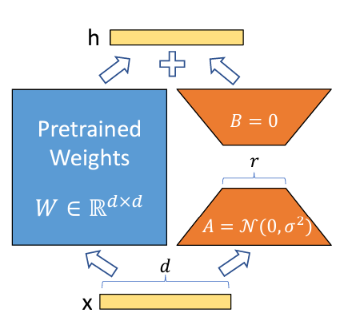

To accommodate a higher capacity rank ($r=32$) without destabilizing the learning rate, we implement **Rank-Stabilized LoRA** (**RS-LoRA**). The original frozen weights ($W$) are combined with the new learned matrices ($A$ and $B$) scaled by a stabilization factor to calculate the updated model weights ($W'$):
$$W' = W + \left( \frac{\alpha}{\sqrt{r}} \right) A \cdot B$$

with $r$ as the rank of the matrices and $\alpha$ a scaling hyperparameter. Unlike standard LoRA which scales the weight update by $\frac{\alpha}{r}$, RS-LoRA scales by $\frac{\alpha}{\sqrt{r}}$. This mathematical adjustment prevents gradient collapse when training at higher ranks. Both are equal to 32 in our case.

If there is no final model and no checkpoint, it initiates a brand new training loop from scratch. Once training finishes, it prints the total execution time and saves the final LoRA adapter weights and the tokenizer. This ensures that the next time you run the code, it will trigger the first step and skip training.

In [ ]:
final_model_dir = os.path.join(cache_dir, "final_finetuned_model")

if os.path.exists(final_model_dir):
    print(f"Final model found at '{final_model_dir}'. Loading it directly...")

    # Load the fine-tuned adapter on top of the base model
    model.load_adapter(final_model_dir, "default")
    print("Pre-trained fine-tuned model loaded successfully! Skipping training.")

    # Retrieve and print basic training statistics from the last checkpoint
    last_checkpoint = get_last_checkpoint(checkpoint_dir) if os.path.exists(checkpoint_dir) else None

    if last_checkpoint:
        state_file_path = os.path.join(last_checkpoint, "trainer_state.json")
        if os.path.exists(state_file_path):
            with open(state_file_path, "r") as f:
                state_data = json.load(f)

            print("\n" + "="*50)
            print("PREVIOUS TRAINING STATISTICS")
            print("="*50)
            print(f"Total Epochs  : {state_data.get('epoch', 'N/A')}")
            print(f"Global Steps  : {state_data.get('global_step', 'N/A')}")

            # Extract final losses from the log history
            log_history = state_data.get("log_history", [])
            if log_history:
                # Get the last entry that contains a training loss
                train_logs = [log for log in log_history if "loss" in log]
                if train_logs:
                    print(f"Final Train Loss : {train_logs[-1]['loss']:.4f}")

                # Get the last entry that contains a validation loss
                eval_logs = [log for log in log_history if "eval_loss" in log]
                if eval_logs:
                    print(f"Final Eval Loss  : {eval_logs[-1]['eval_loss']:.4f}")
            print("="*50 + "\n")
else:
    print(f"No completed model found at '{final_model_dir}'. Initializing training...")

    # Safely check for the last valid checkpoint to prevent crash loops
    last_checkpoint = None
    if os.path.exists(checkpoint_dir):
        last_checkpoint = get_last_checkpoint(checkpoint_dir)

    if last_checkpoint is not None:
        print(f"Found existing checkpoints. Resuming training from the latest checkpoint: {last_checkpoint}")
        resume_from_ckpt = last_checkpoint
    else:
        print("\nSTARTING TRAINING LOOP!")
        resume_from_ckpt = None

    trainer_stats = trainer.train(resume_from_checkpoint=resume_from_ckpt)

    print(f"\nTraining completed! Time taken: {trainer_stats.metrics['train_runtime']} seconds")
    print(f"Saving final model and tokenizer to '{final_model_dir}'...")

    # Save the LoRA adapter weights and tokenizer
    model.save_pretrained(final_model_dir)
    tokenizer.save_pretrained(final_model_dir)
    print("Model saved successfully! Next time you run this cell, it will just load it.")

Final model found at '/content/drive/Shareddrives/MIRCV/LM_Project_Cache/final_finetuned_model'. Loading it directly...
Pre-trained fine-tuned model loaded successfully! Skipping training.

PREVIOUS TRAINING STATISTICS
Total Epochs  : 1.0
Global Steps  : 1958
Final Train Loss : 0.5758
Final Eval Loss  : 0.5715



Extracts the historic telemetry serialized inside the trainer state file to chart model convergence and optimization behaviors.

Extracting training logs from saved file and plotting history...
Total elements loaded from log_history: 215
Found 195 training points and 20 validation points.


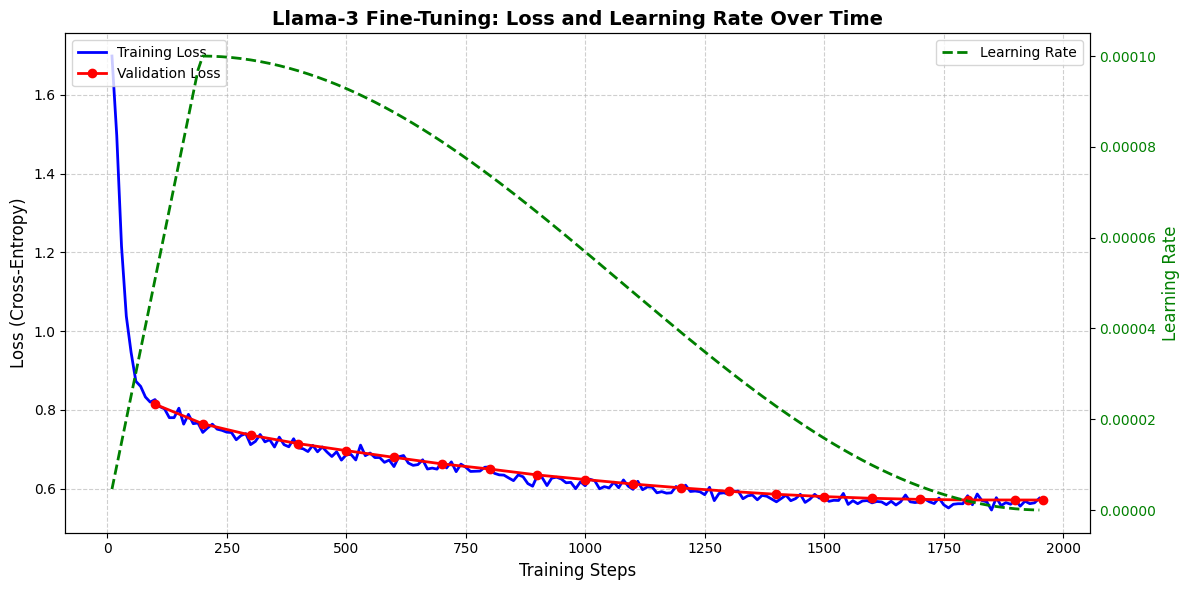

In [ ]:
print("Extracting training logs from saved file and plotting history...")

# 1. Path to the saved trainer state
state_file_path = os.path.join(cache_dir, "llama_cod_checkpoints/checkpoint-1958/trainer_state.json")

if not os.path.exists(state_file_path):
    print(f"ERROR: File not found at {state_file_path}")
    print("Please check your Google Drive or local folders and find 'trainer_state.json'.")
else:
    # 2. Load the JSON file
    with open(state_file_path, "r") as f:
        state_data = json.load(f)

    log_history = state_data.get("log_history", [])
    print(f"Total elements loaded from log_history: {len(log_history)}")

    # Initialize lists to store our metrics
    train_steps = []
    train_loss = []
    learning_rates = []

    eval_steps = []
    eval_loss = []

    # 3. Parse the dictionaries inside log_history
    for entry in log_history:
        if "loss" in entry:
            step = entry.get("step", len(train_steps))
            train_steps.append(step)
            train_loss.append(entry["loss"])

            lr = entry.get("learning_rate", learning_rates[-1] if learning_rates else 0)
            learning_rates.append(lr)

        elif "eval_loss" in entry:
            step = entry.get("step", len(eval_steps))
            eval_steps.append(step)
            eval_loss.append(entry["eval_loss"])

    print(f"Found {len(train_loss)} training points and {len(eval_loss)} validation points.")

    # 4. Create the plot if data exists
    if train_loss:
        fig, ax1 = plt.subplots(figsize=(12, 6))

        # Plot Training and Validation Loss on the primary Y-axis (left)
        ax1.plot(train_steps, train_loss, label='Training Loss', color='blue', linewidth=2)

        if eval_loss:
            ax1.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o', linewidth=2)

        ax1.set_xlabel('Training Steps', fontsize=12)
        ax1.set_ylabel('Loss (Cross-Entropy)', color='black', fontsize=12)
        ax1.tick_params(axis='y', labelcolor='black')
        ax1.legend(loc='upper left')
        ax1.grid(True, linestyle='--', alpha=0.6)

        # Create a secondary Y-axis (right) for the Learning Rate
        ax2 = ax1.twinx()
        ax2.plot(train_steps, learning_rates, label='Learning Rate', color='green', linestyle='--', linewidth=2)
        ax2.set_ylabel('Learning Rate', color='green', fontsize=12)
        ax2.tick_params(axis='y', labelcolor='green')
        ax2.legend(loc='upper right')

        plt.title('Llama-3 Fine-Tuning: Loss and Learning Rate Over Time', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("The loaded file does not contain 'loss' keys.")

Both the Training Loss and Validation Loss show a rapid initial decline, followed by a physiological stabilization (around a cross-entropy value close to 0.6). The close adherence between the validation and training curves throughout the process indicates that the model has generalized correctly, avoiding overfitting. The learning rate increases linearly in the first 200 steps or so until it peaks at 0.00010, then gradually decreases, stabilizing the weight optimization in the final stages. In practice, **the graph certifies a stable training process, successfully completed and with well-calibrated parameters**.

## Agents

In this section, we consolidate the work completed so far by encapsulating the developed components into autonomous classes that represent the final architecture of the system.

### Medical Retriever

The `MedicalRetriever` class serves as the core search engine of the diagnostic system. It is designed to efficiently recall and rank candidate diseases based on a patient's symptom profile by seamlessly orchestrating multiple retrieval methodologies.

The class architecture is structured around the following key components:
- **Initialization and Indexing:** Dynamically loads the fine-tuned Bi-Encoder and Cross-Encoder models into memory. It constructs enriched textual representations from the provided disease database and autonomously builds both the FAISS dense vector index and the BM25 sparse lexical index;
- **Dense Semantic Search:** Utilizes the FAISS index to rapidly identify semantically related diseases based on normalized embeddings. It features dynamic search capabilities, supporting either global database scans or constrained exact-matrix multiplication when candidate restrictions are applied;
- **Hybrid Lexical Fusion:** Integrates the BM25 algorithm to capture exact keyword matches that dense vectors might miss. It implements a consensus mechanism that mathematically boosts the scores of diseases identified by both engines, ensuring robust recall;
- **Neural Re-ranking:** Employs a Cross-Encoder to perform high-precision pairwise relevance scoring on the initial candidate pool. The system calculates the final disease ranking by normalizing and interpolating the dense, sparse, and neural scores based on the parameterized `cross_weight`;
- **Public Interface:** Exposes a unified `retrieve` method that acts as the entry point for the AI agent. It seamlessly manages query processing, handles explicit symptom negations, and guarantees that only the top k unique, highest-scoring candidate diseases are extracted and returned.


In [ ]:
class MedicalRetriever:
    """
    Hybrid medical retrieval system implementing a multi-stage Learning-to-Rank pipeline.

    The retriever identifies the most relevant candidate diseases given a set of symptoms
    by combining:
        1. Dense retrieval using a fine-tuned Bi-Encoder and FAISS similarity search.
        2. Sparse retrieval refinement using BM25 lexical matching.
        3. Neural re-ranking using a Cross-Encoder.

    The class automatically initializes the required models and builds vector and lexical
    indexes from the provided disease database.
    """
    def __init__(
        self,
        disease_database,
        cache_dir: str = '/content/drive/Shareddrives/MIRCV/LM_Project_Cache',
        k: int = 5,
        rerank_pool: int = 50,
        cross_weight: float = 0.5,
        negation_weight: float = 0.3,
        bm25_k1: float = 1.5,
        bm25_b: float = 0.75,
        use_bm25: bool = True,
        use_cross_encoder: bool = True,
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        # Store retrieval and ranking configuration
        self.k = k
        self.rerank_pool = rerank_pool
        self.cross_weight = cross_weight
        self.negation_weight = negation_weight
        self.use_bm25 = use_bm25
        self.use_cross_encoder = use_cross_encoder
        self.bm25_k1 = bm25_k1
        self.bm25_b = bm25_b

        # Define query/document formatting templates
        self.query_prefix = "Diagnose the patient based on these symptoms: "
        self.doc_prefix = "Disease overview and typical symptoms: "

        print("INITIALIZING MEDICAL RETRIEVER")

        # Load fine-tuned Bi-Encoder for semantic retrieval
        embedding_path = os.path.join(cache_dir, "medical_retriever_pubmedbert_finetuned")
        print(f"Loading embedding model from: {embedding_path}...")
        self.embedding_model = SentenceTransformer(embedding_path, device=device)

        # Load Cross-Encoder for final candidate re-ranking
        if self.use_cross_encoder:
            cross_encoder_path = os.path.join(cache_dir, "medical_cross_encoder_finetuned")
            print(f"Loading Cross-Encoder from: {cross_encoder_path}...")
            self.cross_encoder = CrossEncoder(cross_encoder_path, device=device)
        else:
            self.cross_encoder = None

        # Convert database to DataFrame format
        print("Processing disease database...")
        if isinstance(disease_database, pd.DataFrame):
            df_diseases = disease_database
        else:
            df_diseases = disease_database.to_pandas()

        disease_to_symptoms = dict(
            zip(df_diseases["disease"], df_diseases["common_symptom"])
        )

        # Create enriched disease descriptions for retrieval
        print("Building disease document corpus...")
        df_diseases["rich_text"] = df_diseases.apply(
            lambda row:
            f"{self.doc_prefix}{row['disease']}. "
            f"Symptoms: {disease_to_symptoms.get(row['disease'], 'N/A')}",
            axis=1
        )

        self.database_documents = df_diseases["rich_text"].tolist()
        self.disease_names = df_diseases["disease"].tolist()
        self.disease_name_to_idx = {
            name: i for i, name in enumerate(self.disease_names)
        }

        # Encode diseases and build FAISS vector index
        print(f"Vectorizing {len(self.database_documents)} diseases...")
        disease_vectors = self.embedding_model.encode(
            self.database_documents,
            batch_size=32,
            convert_to_numpy=True,
            show_progress_bar=True
        )

        faiss.normalize_L2(disease_vectors)

        vector_dimension = disease_vectors.shape[1]
        self.vector_index = faiss.IndexFlatIP(vector_dimension)
        self.vector_index.add(disease_vectors)

        # Build BM25 index for lexical matching
        if self.use_bm25:
            print(f"Building BM25 index (k1={self.bm25_k1}, b={self.bm25_b})...")
            tokenized_documents = [
                doc.lower().split() for doc in self.database_documents
            ]
            self.bm25_index = BM25Okapi(
                tokenized_documents,
                k1=self.bm25_k1,
                b=self.bm25_b
            )
        else:
            self.bm25_index = None

        print("Retrieval module initialized successfully!\n")

    def _dense_search(self, q_vec_row: np.ndarray, restrict_idx: list = None, top_k: int = 30) -> dict:
        # Search only inside provided candidates if restriction is enabled
        if restrict_idx is not None:
            candidate_vectors = np.vstack([self.vector_index.reconstruct(int(i)) for i in restrict_idx])
            scores = candidate_vectors @ q_vec_row
            return {
                int(i): float(score)
                for i, score in zip(restrict_idx, scores)
            }

        # Otherwise perform global FAISS similarity search
        scores, indices = self.vector_index.search(q_vec_row.reshape(1, -1), top_k)
        return {
            int(idx): float(scores[0][i])
            for i, idx in enumerate(indices[0])
        }

    def _retrieve_top_k_diseases(
        self,
        symptom_text: str,
        query_neg: str = None,
        candidate_diseases: list = None,
        bm25_missing_penalty: float = 0.1,
        bm25_consensus_boost: float = 0.05
    ) -> list:
        if not symptom_text:
            return []

        # Restrict search space if candidate diseases are provided
        restrict_idx = None

        if candidate_diseases:
            restrict_idx = [
                self.disease_name_to_idx[d]
                for d in candidate_diseases
                if d in self.disease_name_to_idx
            ]

            if not restrict_idx:
                restrict_idx = None

        # Encode symptom query
        queries = [self.query_prefix + symptom_text]

        if query_neg:
            queries.append(self.query_prefix + f"{symptom_text}, {query_neg}")

        encoded_queries = self.embedding_model.encode(queries, convert_to_numpy=True)

        faiss.normalize_L2(encoded_queries)

        pool_size = (
            len(restrict_idx)
            if restrict_idx is not None
            else self.rerank_pool
        )

        # STAGE 1: Dense semantic retrieval
        dense_results = self._dense_search(
            encoded_queries[0],
            restrict_idx,
            pool_size
        )

        # STAGE 2: Hybrid fusion with BM25 lexical retrieval
        if self.use_bm25 and restrict_idx is None:
            query_tokens = symptom_text.lower().split()
            bm25_scores = self.bm25_index.get_scores(query_tokens)
            top_sparse = np.argsort(bm25_scores)[::-1][:pool_size]
            min_dense = min(dense_results.values()) if dense_results else 0.0

            for idx in top_sparse:
                idx = int(idx)
                # Reward diseases found by both retrieval methods
                if idx in dense_results:
                    dense_results[idx] += bm25_consensus_boost
                # Add strong lexical matches missing from semantic retrieval
                else:
                    dense_results[idx] = min_dense - bm25_missing_penalty

        # STAGE 3: Penalize Diseases Matching explicit absent Symptoms
        if query_neg and len(encoded_queries) > 1:
            neg_results = self._dense_search(
                encoded_queries[1],
                restrict_idx,
                pool_size
            )
            if neg_results:
                fallback_score = min(neg_results.values())
                for idx in dense_results:
                    penalty = neg_results.get(idx, fallback_score)
                    dense_results[idx] -= self.negation_weight * penalty

        # STAGE 4: Cross-Encoder neural re-ranking
        candidate_indices = list(dense_results.keys())

        if (self.use_cross_encoder and self.cross_encoder is not None and len(candidate_indices) > 1):

            pairs = [
                [symptom_text, self.database_documents[idx]]
                for idx in candidate_indices
            ]

            cross_scores = self.cross_encoder.predict(pairs)

            # Normalize scores before combining ranking signals
            dense_scores = [
                dense_results[idx]
                for idx in candidate_indices
            ]

            min_d, max_d = min(dense_scores), max(dense_scores)
            min_c, max_c = min(cross_scores), max(cross_scores)

            dense_range = max(max_d - min_d, 1.0)
            cross_range = max(max_c - min_c, 1.0)

            final_scores = {}

            # Weighted combination of semantic and neural relevance
            for idx, ce_score in zip(candidate_indices, cross_scores):
                dense_norm = (dense_results[idx] - min_d) / dense_range
                cross_norm = (float(ce_score) - min_c) / cross_range

                final_scores[idx] = ((1 - self.cross_weight) * dense_norm + self.cross_weight * cross_norm)
        else:
            final_scores = dense_results

        # Return highest-ranked unique diseases
        ranked_indices = sorted(final_scores, key=final_scores.get, reverse=True)

        final_results = []
        seen_diseases = set()

        for idx in ranked_indices:
            disease_name = self.disease_names[idx]

            # Ensure no duplicates in the final returned list
            if disease_name not in seen_diseases:
                seen_diseases.add(disease_name)
                final_results.append({
                    "disease": disease_name,
                    "score": final_scores[idx]
                })

            # Stop once we collected the top k unique diseases
            if len(final_results) == self.k:
                break

        return final_results

    def retrieve(self, symptom_text: str, query_neg: str = None, candidate_diseases: list = None) -> list:
        """
        Retrieves the top-k diseases matching the provided symptom description.
        Supports advanced features like negation penalties and candidate restrictions.
        """
        return self._retrieve_top_k_diseases(
            symptom_text=symptom_text,
            query_neg=query_neg,
            candidate_diseases=candidate_diseases
        )

### Standard Agent

The `DiagnosisAgentCoD` class manages the multi-turn conversational loop, orchestrating the fine-tuned Language Model and the `MedicalRetriever` to execute the **Chain of Diagnosis framework**. It provides a stateful, interactive interface that dynamically handles symptom analysis, diagnostic reasoning, and patient interaction.

The inner mechanics and operational stages of this agent are structured as follows:
- **State Management and Memory Initialization:** Maintains a structural conversational log (`conversation_history`) formatted to remain compatible with the model's chat template. It injects a medical system prompt that enforces clinical directives, such as preventing duplicate questioning and guiding the model to follow specific reasoning steps before providing patient-facing replies;
- **Symptom Abstraction (Step 1):** Appends the new raw user utterance to the history and runs an initial forward pass to decode the abstracted clinical symptoms. It then uses programmatic sanitization filters (`ast.literal_eval`) to drop explicitly negated symptoms (e.g. entries starting with "no " or "without "), generating a clean keyword query for the search stage;
- **Candidate Disease Recall (Step 2):** Queries the external hybrid `MedicalRetriever` instance with the sanitized positive symptoms to gather candidate diseases. If available, it dynamically enriches these candidates with their prototypical textbook symptoms and appends the structured result to the chat logs using a native tool message block, ensuring factual grounding for subsequent generation phases;
- **Diagnostic Reasoning (Step 3):** Triggers a secondary, high-token generation pass forcing the model to perform differential analysis over the newly injected context. It uses targeted regular expressions (`re.search`) to slice the raw string output into discrete variables, the internal thought log, the operational Decision flag (**INQUIRY** or **DIAGNOSIS**), the actual patient-facing `response_text`, and the `final_diagnosis` string. The final decision is made automatically by the model without applying any optimizations;
- **Conversational Execution Loop:** It manages state transitions, appends hidden `[SYSTEM DIRECTIVE]` overrides to force a hard terminal diagnostic conclusion when hitting the `max_turns` threshold, logs session transcripts, and shuts down the loop once a definitive diagnosis has been reached.

In [ ]:
class DiagnosisAgentCoD:
    """
    Class for the Chain-of-Diagnosis (CoD) Agentic RAG inference.
    Manages a multi-turn, interactive pipeline by orchestrating Llama-3 and the MedicalRetriever.
    """
    def __init__(self, model, tokenizer, retriever, disease_to_symptoms=None):
        # Initialize primary neural and retrieval components
        self.model = model
        self.tokenizer = tokenizer
        self.retriever = retriever
        self.disease_to_symptoms = disease_to_symptoms

        self.conversation_history: List[Dict[str, str]] = []
        self._initialize_history()

    def _initialize_history(self):
        """Resets the conversational memory to the foundational system directive."""
        self.conversation_history = [
            {
                "role": "system",
                "content": "You are a medical AI assistant designed to provide accurate and comprehensive information on medical conditions. You must include reasoning steps before answering. CRITICAL RULE: Never ask the same question twice. If a patient denies a symptom, explore a different diagnostic path."
            }
        ]

    def response(self, user_text: str) -> Tuple[str, str, str, Optional[str]]:
        """Processes a single conversational turn, managing abstraction, retrieval, reasoning, and output parsing."""
        self.conversation_history.append({"role": "user", "content": user_text})
        # STEP 1: SYMPTOM ABSTRACTION
        # Instruct the language model to abstract raw patient natural language into a structured list of symptoms
        prompt_step1 = self.tokenizer.apply_chat_template(self.conversation_history, tokenize=False, add_generation_prompt=True)
        prompt_step1 += "Thinking Process:\n1. SYMPTOM ABSTRACTION:"

        inputs_1 = self.tokenizer(prompt_step1, return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            outputs_1 = self.model.generate(
                **inputs_1,
                max_new_tokens=64,
                max_length=None,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
                do_sample=False
            )

        input_length_1 = inputs_1.input_ids.shape[1]
        abstracted_symptoms = self.tokenizer.decode(outputs_1[0][input_length_1:], skip_special_tokens=True).strip()

        abstraction_content = f"Thinking Process:\n1. SYMPTOM ABSTRACTION: {abstracted_symptoms}"
        self.conversation_history.append({"role": "assistant", "content": abstraction_content})

        # Sanitize the abstracted symptoms by systematically filtering out explicit negations
        search_query = abstracted_symptoms
        try:
            sym_list = ast.literal_eval(abstracted_symptoms)
            if isinstance(sym_list, list):
                pos_sym = [s for s in sym_list if not s.strip().lower().startswith(('no ', 'without '))]
                search_query = ", ".join(pos_sym)
        except Exception:
            search_query = re.sub(r'\b[Nn]o\s+\w+', '', abstracted_symptoms)

        # STEP 2: CANDIDATE DISEASE RECALL
        # Retrieve relevant diagnostic knowledge utilizing the external MedicalRetriever instance
        retrieved_candidates = self.retriever.retrieve(search_query)

        # Format the refined candidate list into a textual representation for the language model's prompt
        enriched_diseases_list = []
        for candidate in retrieved_candidates:
            d_name = candidate["disease"]
            if self.disease_to_symptoms is not None:
                d_symptoms = self.disease_to_symptoms.get(d_name, "N/A")
                enriched_diseases_list.append(f"- {d_name} (Typical symptoms: {d_symptoms})")
            else:
                enriched_diseases_list.append(f"- {d_name}")

        separator = "\n" if self.disease_to_symptoms is not None else ", "
        recalled_diseases_str = separator.join(enriched_diseases_list) if enriched_diseases_list else "None found."

        # Inject the retrieved medical knowledge into the conversation history as a tool output
        tool_prefix = "Retrieved Candidate Diseases:\n" if self.disease_to_symptoms else "Retrieved Candidate Diseases: "
        self.conversation_history.append({
            "role": "tool",
            "name": "disease_retriever",
            "content": f"{tool_prefix}{recalled_diseases_str}"
        })

        # STEP 3: DIAGNOSTIC REASONING
        # Prompt the model to conduct clinical reasoning over the retrieved context
        prompt_step2 = self.tokenizer.apply_chat_template(self.conversation_history, tokenize=False, add_generation_prompt=True)
        prompt_step2 += "2. DIAGNOSTIC REASONING:"

        inputs_2 = self.tokenizer(prompt_step2, return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            outputs_2 = self.model.generate(
                **inputs_2,
                max_new_tokens=512,
                max_length=None,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
                do_sample=False
            )

        input_length_2 = inputs_2.input_ids.shape[1]
        reasoning_output = self.tokenizer.decode(outputs_2[0][input_length_2:], skip_special_tokens=True)

        assistant_reasoning_content = f"2. DIAGNOSTIC REASONING:{reasoning_output}"
        self.conversation_history.append({"role": "assistant", "content": assistant_reasoning_content})

        # Extract the generated text using regular expressions to extract discrete operational decisions
        decision_match = re.search(r"Decision:\s*(INQUIRY[^\n]*|DIAGNOSIS)", reasoning_output, re.IGNORECASE)
        decision = "DIAGNOSIS" if decision_match and "DIAGNOSIS" in decision_match.group(1).upper() else "INQUIRY"

        # Extract the patient-facing response
        response_match = re.search(r"Response:\s*(.*?)(?:\nFINAL DIAGNOSIS:|$)", reasoning_output, re.DOTALL | re.IGNORECASE)
        response_text = response_match.group(1).strip() if response_match else "Could you elaborate on your symptoms?"

        # Extract the final diagnostic conclusion if reached
        diagnosis_match = re.search(r"FINAL DIAGNOSIS:\s*(.*)", reasoning_output, re.IGNORECASE)
        final_diagnosis = diagnosis_match.group(1).strip() if diagnosis_match else None

        # Compile internal processing metrics for systemic transparency
        internal_log = (
            f"\n--- INTERNAL THOUGHT PROCESS ---\n"
            f"{abstraction_content}\n\n"
            f"[TOOL: Retriever (Cleaned Query: '{search_query}')]\n{tool_prefix}{recalled_diseases_str}\n\n"
            f"{assistant_reasoning_content}\n"
            f"--------------------------------\n"
        )

        return internal_log, decision, response_text, final_diagnosis

    def chat(self, initial_query: Optional[str] = None, verbose: bool = False, max_turns: int = 5) -> str:
        """
        Initiates a multi-turn, stateful diagnostic session within the standard output interface.
        Enforces a hard limit on inquiries to ensure timely diagnostic conclusions.
        """
        print("="*50)
        print("DIAGNOSTIC AGENT INITIALIZED (Base Version)")
        print("Type 'exit' or 'quit' to end the session.")
        print("="*50 + "\n")

        self._initialize_history()
        transcript = ""
        turn_count = 0

        user_input = initial_query

        while True:
            if not user_input:
                user_input = input("Patient: ")

            if user_input.lower() in ['exit', 'quit']:
                print("\nSession terminated.")
                break

            turn_count += 1

            # Intervene automatically when the maximum permitted conversational turns are reached
            if turn_count == max_turns:
                user_input += "\n[SYSTEM DIRECTIVE: You have asked enough questions. You MUST make a Decision: DIAGNOSIS now based on the current symptoms.]"

            transcript += f"Patient: {user_input}\n"

            if not verbose:
                print("\n[Agent is analyzing symptoms and retrieving medical knowledge...]")

            internal_log, decision, response_text, final_diagnosis = self.response(user_input)

            if verbose:
                print(internal_log)
                transcript += f"{internal_log}\n"

            print(f"\nDoctorGPT: {response_text}")
            transcript += f"DoctorGPT: {response_text}\n"

            # Terminate the loop upon reaching a definitive clinical conclusion
            if decision == "DIAGNOSIS" or final_diagnosis:
                diagnosis_to_print = final_diagnosis if final_diagnosis else "Refer to response text."
                final_msg = f"\n[FINAL DIAGNOSIS REACHED: {diagnosis_to_print}]"
                print(final_msg)
                transcript += f"{final_msg}\n"
                break
            else:
                user_input = None

        return transcript

### Advanced Agent

The `AdvancedDiagnosisAgentCoD` class represents a significant architectural evolution over the base agent. While the standard version relies entirely on the Language Model's internal logic to drive the conversation, this advanced iteration integrates deterministic mathematical controllers, bringing the implementation closer to that of the original paper.

Here is how the class executes the 5 core CoD steps:
- **Symptom Abstraction & Stateful Tracking (Step 1):** The model translates the patient's natural language into a structured list of clinical terms. Unlike the base version, this class statefully tracks both affirmed (`known_patient_symptoms`) and explicitly denied (`negated_patient_symptoms`) symptoms across the entire multi-turn session, ensuring a cumulative clinical picture;
- **Candidate Disease Recall (Step 2):** It queries the `MedicalRetriever` using the accumulated positive symptoms, but crucially passes the tracked negations as well. This allows the retriever to mathematically penalize diseases that feature symptoms the patient has explicitly denied, drastically improving retrieval precision;
- **Diagnostic Reasoning (Step 3):** The agent formats the retrieved diseases and their typical symptoms into a strict template, prompting the SLM to generate a differential analysis comparing the patient's presentation against the medical knowledge base;
- **Confidence Distribution (Step 4):** The model outputs a probability distribution for the candidate diseases. The agent parses this JSON and immediately calculates its *Shannon Entropy* to mathematically quantify the current level of diagnostic uncertainty;
- **Decision Making (Step 5):** This is where the advanced agent takes control. It evaluates the highest confidence score against a hard, deterministic threshold (τ). If confidence is $\ge$ τ, it outputs a final DIAGNOSIS. If confidence is $<$ τ, it triggers an INQUIRY. Instead of letting the SLM randomly guess what to ask next, the *Information Gain Controller* calculates which specific symptom mathematically best splits the remaining candidate diseases. It then uses a hidden `[System Directive]` to inject a hard constraint, forcing the SLM to ask the patient about that exact symptom.



In [ ]:
class AdvancedDiagnosisAgentCoD:
    """
    Advanced Class for the Chain-of-Diagnosis (CoD) Agentic RAG inference.
    Implements:
    1. Hybrid Retrieval synchronized with the standalone MedicalRetriever module.
    2. Deterministic Confidence Thresholding (Tau).
    3. Algorithmic Active Information Acquisition (Discriminative Symptom Controller).
    4. Candidate-conditioned retrieval.
    5. Negation-aware retrieval scoring using dynamic FAISS penalties.
    6. Tracking of confidence and entropy history for performance evaluation.
    """
    def __init__(self, model, tokenizer, retriever, disease_to_symptoms=None, tau=0.6):
        # Bind the loaded SLM, tokenizer, and the custom MedicalRetriever instance
        self.model = model
        self.tokenizer = tokenizer
        self.retriever = retriever

        # Dictionary mapping diseases to their string of typical symptoms
        self.disease_to_symptoms = disease_to_symptoms

        # The confidence threshold: if the SLM's certainty is >= tau, it stops asking questions and diagnoses
        self.tau = tau

        # Memory structures for multi-turn conversations
        self.conversation_history: List[Dict[str, str]] = []

        # Sets to keep track of what the patient has explicitly confirmed or denied across all turns
        self.known_patient_symptoms = set()
        self.negated_patient_symptoms = set()

        # Optional constraint to force the retriever to only look at specific diseases
        self.candidate_diseases: Optional[List[str]] = None

        # Telemetry structures to track how the model's uncertainty changes over time
        self.confidence_history: List[Dict[str, float]] = []
        self.entropy_history: List[float] = []

        # Populate the initial state
        self._initialize_history()

    def _initialize_history(self):
        """Wipes the conversation history and resets all symptom/metric trackers to start a new patient case."""
        # The base persona and strict instructions for the SLM
        self.system_prompt = {
            "role": "system",
            "content": "You are a medical AI assistant. You must include reasoning steps before answering. You must strictly follow any [System Directive] given to you."
        }
        self.conversation_history = [self.system_prompt]
        self.known_patient_symptoms.clear()
        self.negated_patient_symptoms.clear()
        self.candidate_diseases = None
        self.confidence_history.clear()
        self.entropy_history.clear()

    def set_candidates(self, candidate_diseases: Optional[List[str]] = None):
        """Restricts the search space. Used mainly when testing on specific subsets."""
        self.candidate_diseases = candidate_diseases if candidate_diseases else None

    def _get_best_discriminatory_symptom(self, controller_dict: Dict[str, List[str]], confidence_dict: Dict[str, float]) -> Optional[str]:
        """
        Uses Shannon Entropy and Information Gain to mathematically determine the best symptom
        to ask the patient about, in order to differentiate between the current candidate diseases.
        """
        total_conf = sum(confidence_dict.values())
        if total_conf <= 0:
            return None

        # Convert raw SLM confidence scores into a normalized probability distribution (summing to 1.0)
        prior_probs = {d: (c / total_conf) for d, c in confidence_dict.items()}

        # Calculate the base Shannon Entropy of the current diagnostic uncertainty
        current_entropy = -sum(p * math.log2(p) for p in prior_probs.values() if p > 0)

        # If entropy is 0, the model is already 100% certain of one disease
        if current_entropy == 0:
            return None

        # Invert the dictionary: map each unique symptom to the set of diseases that present it
        symptom_map = {}
        for disease, symptoms in controller_dict.items():
            # Ensure every retrieved disease has at least a tiny base probability to avoid division by zero
            if disease not in prior_probs:
                prior_probs[disease] = 0.001
            for sym in symptoms:
                symptom_map.setdefault(sym, set()).add(disease)

        best_symptom = None
        max_ig = -1.0

        # Evaluate the Information Gain for every single known symptom of the retrieved diseases
        for sym, diseases_with_sym in symptom_map.items():
            # Skip symptoms we already know the patient has or doesn't have
            if sym in self.known_patient_symptoms:
                continue

            # Calculate the marginal probability that the patient actually HAS this symptom
            p_s_yes = sum(prior_probs[d] for d in diseases_with_sym if d in prior_probs)
            # Calculate the marginal probability that the patient DOES NOT HAVE this symptom
            p_s_no = 1.0 - p_s_yes

            # Skip symptoms that are almost impossible or almost certain (low discriminative power)
            if p_s_yes <= 0.001 or p_s_no <= 0.001:
                continue

            # Calculate the expected conditional entropy if the patient answers YES
            h_c_given_yes = 0.0
            for d in diseases_with_sym:
                if d in prior_probs:
                    p = prior_probs[d] / p_s_yes
                    if p > 0:
                        h_c_given_yes -= p * math.log2(p)

            # Calculate the expected conditional entropy if the patient answers NO
            h_c_given_no = 0.0
            for d in set(prior_probs.keys()) - diseases_with_sym:
                p = prior_probs[d] / p_s_no
                if p > 0:
                    h_c_given_no -= p * math.log2(p)

            # Information Gain (IG) = Current Entropy - Expected Conditional Entropy
            # The higher the IG, the more uncertainty this symptom will remove
            ig = current_entropy - (p_s_yes * h_c_given_yes + p_s_no * h_c_given_no)

            # Keep track of the symptom that maximizes Information Gain
            if ig > max_ig:
                max_ig = ig
                best_symptom = sym

        return best_symptom

    def response(self, user_text: str, force_diagnosis: bool = False) -> Tuple[str, str, str, Optional[str]]:
        """Handles a single agentic turn: symptom extraction, retrieval, reasoning, decision, and generation."""
        # Context Window Management: to avoid CUDA OutOfMemory, keep only the system prompt and the last 4 messages
        if len(self.conversation_history) > 5:
            self.conversation_history = [self.system_prompt] + self.conversation_history[-4:]

        # Append the new patient input
        self.conversation_history.append({"role": "user", "content": user_text})

        # STEP 1: SYMPTOM ABSTRACTION
        # Build the prompt forcing the SLM to start outputting the abstracted symptoms list
        prompt_step1 = self.tokenizer.apply_chat_template(self.conversation_history, tokenize=False, add_generation_prompt=True)
        prompt_step1 += "Thinking Process:\n1. SYMPTOM ABSTRACTION:"

        # Tokenize and move tensors to the correct device (GPU/CPU)
        inputs_1 = self.tokenizer(prompt_step1, return_tensors="pt").to(self.model.device)

        # Generate only the symptom list (short max_new_tokens to save compute)
        with torch.no_grad():
            outputs_1 = self.model.generate(
                **inputs_1, max_new_tokens=64, max_length=None,
                pad_token_id=self.tokenizer.eos_token_id, eos_token_id=self.tokenizer.eos_token_id, do_sample=False
            )

        # Decode only the newly generated tokens, ignoring the prompt
        abstracted_symptoms = self.tokenizer.decode(outputs_1[0][inputs_1.input_ids.shape[1]:], skip_special_tokens=True).strip()
        abstraction_content = f"Thinking Process:\n1. SYMPTOM ABSTRACTION: {abstracted_symptoms}"

        # Save this partial thought to the ongoing conversation
        self.conversation_history.append({"role": "assistant", "content": abstraction_content})

        # Parse the stringified list generated by the SLM (e.g. "['fever', 'no cough']")
        search_query = abstracted_symptoms
        try:
            sym_list = ast.literal_eval(abstracted_symptoms)
            pos_sym = []
            if isinstance(sym_list, list):
                for s in sym_list:
                    s_clean = s.strip().lower()
                    # Detect negative symptoms (e.g. "without pain")
                    if s_clean.startswith(('no ', 'without ')):
                        # Remove the negation prefix to get the clean anatomical term
                        neg_name = re.sub(r'^(no|without)\s+', '', s_clean)
                        self.negated_patient_symptoms.add(neg_name)
                        self.known_patient_symptoms.add(neg_name)
                    else:
                        # It's a positive symptom
                        self.known_patient_symptoms.add(s_clean)
                        pos_sym.append(s)
                # Combine positive symptoms for the main FAISS/BM25 query
                search_query = ", ".join(pos_sym)
        except Exception:
            # Fallback if AST parsing fails: remove "no" words via regex
            search_query = re.sub(r'\b[Nn]o\s+\w+', '', abstracted_symptoms)

        # Combine negated symptoms for the secondary penalty query in FAISS
        query_neg = ", ".join(sorted(self.negated_patient_symptoms)) if self.negated_patient_symptoms else None

        # STEP 2: CANDIDATE DISEASE RECALL
        # Call the unified MedicalRetriever passing positive and negative symptoms
        retrieved_candidates = self.retriever.retrieve(
            symptom_text=search_query,
            query_neg=query_neg,
            candidate_diseases=self.candidate_diseases
        )

        # Format the retrieved diseases to be injected into the SLM context
        enriched_diseases_list = []
        controller_dict = {}
        for candidate in retrieved_candidates:
            d_name = candidate["disease"]
            # Append typical symptoms if the mapping dictionary is provided
            if self.disease_to_symptoms is not None:
                d_symptoms_str = self.disease_to_symptoms.get(d_name, "N/A")
                enriched_diseases_list.append(f"- {d_name} (Typical symptoms: {d_symptoms_str})")

                # Build the controller_dict needed for the Information Gain calculation later
                controller_dict[d_name] = (
                    [s.strip().lower() for s in d_symptoms_str.split(',')] if d_symptoms_str != "N/A" else []
                )
            else:
                enriched_diseases_list.append(f"- {d_name}")
                controller_dict[d_name] = []

        # Join the list into a single string
        separator = "\n" if self.disease_to_symptoms is not None else ", "
        recalled_diseases_str = separator.join(enriched_diseases_list) if enriched_diseases_list else "None found."

        # Simulate a tool call result
        tool_prefix = "Retrieved Candidate Diseases:\n" if self.disease_to_symptoms else "Retrieved Candidate Diseases: "
        self.conversation_history.append({
            "role": "tool", "name": "disease_retriever", "content": f"{tool_prefix}{recalled_diseases_str}"
        })

        # STEP 3: DIAGNOSTIC REASONING
        # Force the SLM to start writing its reasoning over the retrieved context
        prompt_step2 = self.tokenizer.apply_chat_template(self.conversation_history, tokenize=False, add_generation_prompt=True)
        prompt_step2 += "2. DIAGNOSTIC REASONING:"
        inputs_2 = self.tokenizer(prompt_step2, return_tensors="pt").to(self.model.device)

        # Generate the reasoning block
        with torch.no_grad():
            outputs_2 = self.model.generate(
                **inputs_2, max_new_tokens=512, max_length=None,
                pad_token_id=self.tokenizer.eos_token_id, eos_token_id=self.tokenizer.eos_token_id, do_sample=False
            )

        text_stage_2 = self.tokenizer.decode(outputs_2[0][inputs_2.input_ids.shape[1]:], skip_special_tokens=True)

        # STEP 4: CONFIDENCE DISTRIBUTION
        # Use regex to extract the JSON dictionary representing the model's confidence distribution
        conf_match = re.search(r"(.*?)\n\nConfidence Distribution:\n(\{.*?\})", text_stage_2, re.DOTALL | re.IGNORECASE)
        if conf_match:
            reasoning_text = conf_match.group(1).strip()
            conf_json_str = conf_match.group(2).strip()
            try:
                # Parse the JSON string into a Python dictionary
                confidence_dict = json.loads(conf_json_str)
                # Find the highest confidence score and the corresponding disease name
                c_max = max(confidence_dict.values())
                best_disease = max(confidence_dict, key=confidence_dict.get)
            except Exception:
                c_max, confidence_dict, best_disease = 0.0, {}, None
        else:
            # Fallback if the regex fails to find the expected pattern
            reasoning_text, conf_json_str, c_max, confidence_dict, best_disease = text_stage_2.split("Decision:")[0], "{}", 0.0, {}, None

        # Track the mathematical uncertainty (Shannon Entropy) for analysis and debugging
        if confidence_dict:
            total_conf = sum(confidence_dict.values())
            if total_conf > 0:
                probs = {d: c / total_conf for d, c in confidence_dict.items()}
                turn_entropy = -sum(p * math.log2(p) for p in probs.values() if p > 0)
            else:
                turn_entropy = 0.0
        else:
            turn_entropy = 0.0

        self.confidence_history.append(confidence_dict)
        self.entropy_history.append(turn_entropy)

        # STEP 5: DECISION MAKING
        # Core agentic logic: if confidence is high enough (>= tau) or forced, conclude the loop
        computed_decision = "DIAGNOSIS" if (force_diagnosis or c_max >= self.tau) else "INQUIRY"

        controller_log_msg = ""

        # If the model is uncertain, intervene algorithmically
        if computed_decision == "INQUIRY":
            # Ask the Information Gain calculator which symptom is best to ask next
            best_symptom_to_ask = self._get_best_discriminatory_symptom(controller_dict, confidence_dict)

            if best_symptom_to_ask:
                # Create a hidden prompt injection forcing the SLM to ask about this specific symptom
                directive = f"\n[System Directive: You MUST explicitly ask the patient if they are experiencing '{best_symptom_to_ask}'. This is necessary to distinguish between the candidate diseases.]"
                forced_injection = f"{reasoning_text}\n\nConfidence Distribution:\n{conf_json_str}\n\nDecision: {computed_decision}{directive}\nResponse:"

                # Mark this symptom as known so we don't calculate IG for it again
                self.known_patient_symptoms.add(best_symptom_to_ask.lower())
                controller_log_msg = f"Symptom selected by Information Gain Controller: '{best_symptom_to_ask}'"
            else:
                # If the math couldn't find a good symptom, let the SLM decide naturally
                forced_injection = f"{reasoning_text}\n\nConfidence Distribution:\n{conf_json_str}\n\nDecision: {computed_decision}\nResponse:"
                controller_log_msg = "No suitable distinguishing symptom found. Reverting to LLM free-choice."
        else:
            # If diagnosing, force the model to provide a conclusive response without further questions
            directive = "\n[System Directive: You are now providing the final diagnosis. Do NOT ask any further questions. Explain the diagnosis and provide clinical recommendations.]"
            forced_injection = f"{reasoning_text}\n\nConfidence Distribution:\n{conf_json_str}\n\nDecision: {computed_decision}{directive}\nResponse:"

        # Combine the prompt and generate the final text that the user will actually see
        prompt_step3 = prompt_step2 + forced_injection
        inputs_3 = self.tokenizer(prompt_step3, return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            outputs_3 = self.model.generate(
                **inputs_3, max_new_tokens=128, max_length=None,
                pad_token_id=self.tokenizer.eos_token_id, eos_token_id=self.tokenizer.eos_token_id, do_sample=False
            )

        # Decode the final patient-facing response
        final_response_text = self.tokenizer.decode(outputs_3[0][inputs_3.input_ids.shape[1]:], skip_special_tokens=True)

        # Clean the string from the internal "FINAL DIAGNOSIS:" tag
        response_clean = final_response_text.split("FINAL DIAGNOSIS:")[0].strip()
        final_diagnosis = best_disease if computed_decision == "DIAGNOSIS" else None

        # Reconstruct the entire internal thought process to save in the history
        full_assistant_content = f"2. DIAGNOSTIC REASONING: {forced_injection} {final_response_text}"
        self.conversation_history.append({"role": "assistant", "content": full_assistant_content})

        # Format debugging strings to print out the telemetry of this turn
        candidates_log = f"Candidate-conditioned on: {self.candidate_diseases}" if self.candidate_diseases else "Open-ended search (full database)"
        negation_log = f"Negated symptoms tracked: {sorted(self.negated_patient_symptoms)}" if self.negated_patient_symptoms else "No negated symptoms tracked yet"

        # Build the internal log string
        internal_log = (
            f"\n--- INTERNAL THOUGHT PROCESS ---\n"
            f"{abstraction_content}\n\n"
            f"[RETRIEVAL MODE]: {candidates_log} | {negation_log} | BM25={self.retriever.use_bm25} | CrossEncoder={self.retriever.use_cross_encoder}\n"
            f"[TOOL: Retriever]\n{tool_prefix}{recalled_diseases_str}\n\n"
            f"2. DIAGNOSTIC REASONING: {reasoning_text}\n\n"
            f"Confidence Distribution:\n{conf_json_str}\n\n"
            f"[SYSTEM DECISION]: Max Confidence = {c_max:.2f}. Threshold = {self.tau}. Decision = {computed_decision}\n"
            f"[ALGORITHMIC CONTROLLER]: {controller_log_msg}\n"
            f"--------------------------------\n"
        )
        return internal_log, computed_decision, response_clean, final_diagnosis

    def chat(self, initial_query: Optional[str] = None, verbose: bool = False, max_turns: Optional[int] = 5,
             candidate_diseases: Optional[List[str]] = None) -> str:
        """
        Runs the interactive Command Line Interface (CLI) loop.
        Prompts the user for input, calls the response() function, and stops when a diagnosis is reached.
        """
        print("="*50)
        print(f"ADVANCED DIAGNOSTIC AGENT INITIALIZED (Tau: {self.tau} | IG Controller: Active)")
        print("Type 'exit' or 'quit' to end the session.")
        print("="*50 + "\n")

        self._initialize_history()
        self.set_candidates(candidate_diseases)

        transcript = ""
        turn_count = 0
        user_input = initial_query

        # Start the infinite loop for the diagnostic interaction
        while True:
            # Ask for user input if it wasn't passed programmatically
            if not user_input:
                user_input = input("Patient: ")

            # Exit condition
            if user_input.lower() in ['exit', 'quit']:
                print("\nSession terminated.")
                break

            turn_count += 1

            # Check if we hit the maximum allowed questions if so, trigger the forced diagnosis flag
            force_diag = (max_turns is not None) and (turn_count >= max_turns)

            # Log the patient's query
            transcript += f"Patient: {user_input}\n"

            if not verbose:
                print("\n[Agent is reasoning...]")

            # Run the heavy AI pipeline
            internal_log, decision, response_text, final_diagnosis = self.response(user_input, force_diagnosis=force_diag)

            # Print telemetry if requested
            if verbose:
                print(internal_log)
                transcript += f"{internal_log}\n"

            # Print the actual text the doctor AI is saying to the patient
            print(f"\nDoctorGPT: {response_text}")
            transcript += f"DoctorGPT: {response_text}\n"

            # Terminal condition: The agent decided to diagnose
            if decision == "DIAGNOSIS" or final_diagnosis:
                diagnosis_to_print = final_diagnosis if final_diagnosis else "Refer to response text."
                final_msg = f"\n[FINAL DIAGNOSIS REACHED: {diagnosis_to_print}]"
                print(final_msg)
                transcript += f"{final_msg}\n"
                break
            else:
                # Reset user_input so the next loop iteration waits for the user to type
                user_input = None

        return transcript

## Evaluation

In this section, we report the final experimental evaluation of the Medical Retriever and the Advanced Model, analyzing the performance of the approach adopted in this project and inspired by the original paper.

In [ ]:
# Initialize the Metical Retriever
medical_retriever = MedicalRetriever(
    disease_database=disease_database,
    cache_dir=cache_dir,
    k=3,                   # Top 3 diseases to return
    rerank_pool=50,        # Number of candidates for the Cross-Encoder to re-rank
    use_bm25=True,         # Enable Hybrid Fusion
    use_cross_encoder=True # Enable Neural Re-ranking
)

# Initialize the Advanced Diagnostic Agent
agent = AdvancedDiagnosisAgentCoD(
    model=model,
    tokenizer=tokenizer,
    retriever=medical_retriever,
    disease_to_symptoms=disease_to_symptoms,
    tau=0.6 # Confidence threshold for deterministic decision making
)



INITIALIZING MEDICAL RETRIEVER
Loading embedding model from: /content/drive/Shareddrives/MIRCV/LM_Project_Cache/medical_retriever_pubmedbert_finetuned...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading Cross-Encoder from: /content/drive/Shareddrives/MIRCV/LM_Project_Cache/medical_cross_encoder_finetuned...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Processing disease database...
Building disease document corpus...
Vectorizing 9620 diseases...


Batches:   0%|          | 0/301 [00:00<?, ?it/s]

Building BM25 index (k1=1.5, b=0.75)...
Retrieval module initialized successfully!



### Retrieval Evaluation

Let's look at what an input to the test set is composed of.

In [ ]:
print("A ELEMENT OF 'TEST' SET:")
print(test[0])

A ELEMENT OF 'TEST' SET:
{'prompt': "Hi, doctor. I'm experiencing redness and pain in my left eye. It's been bothering me for a couple of days. I'm a 35-year-old female.", 'symptoms': ['Redness', 'Pain', 'Nasal discharge', 'Crepitus on palpation', 'Deformity of the nasal bridge'], 'disease': 'Nasal Trauma'}


The `evaluate_retriever` function is the **main benchmarking tool used to quantitatively assess the retrieval performance** of the `MedicalRetriever` module. During evaluation, the function temporarily adjusts parameters such as `k` and `rerank_pool` to retrieve a larger candidate set, restoring the original configuration afterward. It also includes checkpointing support by periodically saving progress, allowing the evaluation to resume after interruptions. Finally, it computes key retrieval metrics, including **Recall@K** and **Mean Reciprocal Rank** (**MRR**), and summarizes the results in a *Pandas DataFrame*.

In [ ]:
def evaluate_retriever(
    retriever,
    test_dataset,
    dataset_name: str = "test_retrieval",
    top_k_list: list = [3, 5, 10, 30, 50, 100]
) -> dict:
    """
    Evaluates the MedicalRetriever on a test dataset with auto-resume (checkpointing).
    Calculates Recall@K and MRR@Max_K by simulating the retrieval process
    using the extracted patient symptoms as queries.
    """
    max_k = max(top_k_list)

    # Checkpoint setup
    checkpoint_dir = os.path.join(cache_dir, "eval_checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"{dataset_name}_state.json")

    # Temporarily override retriever configuration to ensure enough candidates are fetched
    original_k = retriever.k
    original_pool = retriever.rerank_pool

    retriever.k = max_k
    if retriever.rerank_pool < max_k:
        retriever.rerank_pool = max_k

    # Initialize tracking variables
    processed_indices = set()
    metrics = {f"Recall@{k}": [] for k in top_k_list}
    metrics[f"MRR@{max_k}"] = []

    # Restore from checkpoint if available
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            saved_state = json.load(f)
            processed_indices = set(saved_state.get('processed_indices', []))

            # Restore the metrics lists
            saved_metrics = saved_state.get('metrics', {})
            for key in metrics.keys():
                if key in saved_metrics:
                    metrics[key] = saved_metrics[key]
        print(f" -> Found retriever checkpoint! Resuming from case {len(processed_indices)}/{len(test_dataset)}.")

    for i, row in enumerate(tqdm(test_dataset, desc=f"Evaluating Retriever ({dataset_name})")):
        # Skip cases that have already been processed in a previous run
        if i in processed_indices:
            continue

        # Safely extract symptoms and ground truth disease
        symptoms_list = row.get("symptoms", [])
        true_disease = row.get("disease", "")
        negative_symptoms = row.get("negative_symptoms", [])

        if not symptoms_list or not true_disease:
            # Mark as processed to avoid infinite retries on broken rows
            processed_indices.add(i)
            continue

        # Format the query
        symptom_text = ", ".join(symptoms_list) if isinstance(symptoms_list, list) else str(symptoms_list)
        query_neg = ", ".join(negative_symptoms) if negative_symptoms else None

        # Execute retrieval pipeline
        retrieved_candidates = retriever.retrieve(
            symptom_text=symptom_text,
            query_neg=query_neg
        )

        retrieved_names = [res["disease"] for res in retrieved_candidates]

        # Find the rank of the true disease in the predictions
        rank = -1
        if true_disease in retrieved_names:
            rank = retrieved_names.index(true_disease) + 1

        # Compute Recall@K
        for k in top_k_list:
            hit = 1 if (0 < rank <= k) else 0
            metrics[f"Recall@{k}"].append(hit)

        # Compute Mean Reciprocal Rank (MRR)
        if 0 < rank <= max_k:
            metrics[f"MRR@{max_k}"].append(1.0 / rank)
        else:
            metrics[f"MRR@{max_k}"].append(0.0)

        processed_indices.add(i)

        # Periodically store the evaluation state to disk
        if len(processed_indices) % 50 == 0 or len(processed_indices) == len(test_dataset):
            state_to_save = {
                "processed_indices": list(processed_indices),
                "metrics": metrics
            }
            with open(checkpoint_path, 'w') as f:
                json.dump(state_to_save, f)

    # Restore the retriever to its original configuration for production use
    retriever.k = original_k
    retriever.rerank_pool = original_pool

    # Aggregate and average the results
    final_metrics = {}
    for metric_name, values in metrics.items():
        final_metrics[metric_name] = np.mean(values) if values else 0.0

    # Format the output into a clean Pandas DataFrame
    results_df = pd.DataFrame(list(final_metrics.items()), columns=["Metric", "Value"])
    formatters = {"Value": "{:.4f}".format}

    print("\n" + "="*50)
    print(f"MEDICAL RETRIEVER EVALUATION REPORT ({dataset_name.upper()})")
    print("="*50)
    print(results_df.to_string(index=False, formatters=formatters))
    print("="*50 + "\n")

    return final_metrics

In [ ]:
evaluation_results = evaluate_retriever(
     retriever=medical_retriever,
     test_dataset=test,
     top_k_list=[3, 5, 10, 30, 50, 100]
)

 -> Found retriever checkpoint! Resuming from case 3915/3915.


Evaluating Retriever (test_retrieval):   0%|          | 0/3915 [00:00<?, ?it/s]


MEDICAL RETRIEVER EVALUATION REPORT (TEST_RETRIEVAL)
    Metric  Value
  Recall@3 0.6902
  Recall@5 0.7188
 Recall@10 0.7586
 Recall@30 0.8296
 Recall@50 0.8769
Recall@100 0.9269
   MRR@100 0.6681



The evaluation metrics indicate a robust and effective retrieval architecture:
- **High Precision at the Top (MRR@100: 0.67):** A Mean Reciprocal Rank of about 0.67 means that, on average, the correct disease is ranked between position 1 and position 2. The Cross-Encoder is doing an excellent job of pushing the right answer to the very top of the list;
- **Strong Context Window Performance (Recall@3: 69%):** 69% of the times, the correct diagnosis is found within the top 3 results. This is crucial because passing a highly accurate, narrow candidate pool to the SLM reduces hallucinations and saves token processing costs;
- **Good Broad Recall (Recall@100: 93%):** The fact that the system finds the correct disease 93% of the time when looking at the top 100 results proves that the Stage-1 foundational search (FAISS + BM25) is extremely capable of capturing the relevant medical context before passing it to the neural re-ranker.

### Model Evaluation

Now let's see how the benchmarks are structured.

In [ ]:
print("AN ELEMENT OF 'DXBENCH':")
print(dxbench_dataset[0])

AN ELEMENT OF 'DXBENCH':
{'id': 'DxBench_1', 'department': 'Surgery', 'explicit_symptoms': [['Dizziness', 'True'], ['Headache', 'True']], 'implicit_symptoms': [['unsteady vision', 'True'], ['Numbness in the left hand', 'True']], 'candidate_diseases': ['Cervical Spondylosis of Sympathetic Type', 'Cerebral Insufficiency', 'Lacunar Stroke'], 'disease': 'Lacunar Stroke'}


In [ ]:
print("AN ELEMENT OF 'DXY':")
print(dxy_dataset[0])

AN ELEMENT OF 'DXY':
{'id': 'Dxy_1', 'explicit_symptoms': [['Restlessness', 'True'], ['fever', 'True'], ['Rash', 'True']], 'implicit_symptoms': [['herpes', 'True'], ['Lethargy', 'True'], ['Cough', 'False'], ['Vomiting', 'False'], ['Anorexia', 'False']], 'candidate_diseases': ['Pneumonia', 'Allergic Rhinitis', 'Hand, Foot and Mouth Disease in Children', 'Upper Respiratory Tract Infection', 'Pediatric Diarrhea'], 'disease': 'Hand, Foot and Mouth Disease in Children'}


In [ ]:
print("AN ELEMENT OF 'MUZHI':")
print(muzhi_dataset[0])

AN ELEMENT OF 'MUZHI':
{'id': 'Muzhi_1', 'explicit_symptoms': [['Fever', 'True']], 'implicit_symptoms': [['Moderate Fever', 'True'], ['Fever Reduction', 'True']], 'candidate_diseases': ['Pediatric Diarrhea', 'Pediatric Bronchitis', 'Pediatric Dyspepsia', 'Upper Respiratory Tract Infection'], 'disease': 'Upper Respiratory Tract Infection'}


The `generate_patient_prompt` dynamically synthesizes realistic, natural-language patient queries using only the explicitly affirmed symptoms. It utilizes deterministic template routing to appropriately simulate either adult or pediatric conversational perspectives, ensuring reproducible testing environments.

In [ ]:
def generate_patient_prompt(explicit_symptoms: List[str], force_child: bool = False, random_seed: int = 42) -> str:
    """
    Dynamically generates a natural language patient query starting from
    a raw list of explicit symptoms.

    If the special token "child" is present in the symptoms, or if the
    'force_child' boolean flag is set to True, the prompt is generated
    as if the speaker is describing their child's symptoms.

    :param explicit_symptoms: List of symptoms provided by the dataset.
    :param force_child: Boolean flag to force the prompt into the "child"
                        perspective regardless of the symptom list.
    :param random_seed: Integer seed to guarantee reproducibility while
                        allowing template variation.
    """
    # Detect whether this is a child case either by explicit token or boolean flag
    is_child = force_child or any(s.lower() == "child" for s in explicit_symptoms)

    # Remove the special token so it isn't treated as a clinical symptom
    symptoms = [s for s in explicit_symptoms if s.lower() != "child"]

    if not symptoms:
        if is_child:
            return (
                "Hello doctor. My child isn't feeling well, but I'm not sure how to describe the symptoms."
            )
        return (
            "Hello doctor, I'm not feeling well but I'm not sure how to describe my symptoms."
        )

    # Format symptoms list grammatically
    if len(symptoms) == 1:
        symptoms_str = symptoms[0]
    elif len(symptoms) == 2:
        symptoms_str = " and ".join(symptoms)
    else:
        symptoms_str = ", ".join(symptoms[:-1]) + f", and {symptoms[-1]}"

    # Template selection based on the determined perspective
    if is_child:
        templates = [
            f"Hello doctor. My child has been experiencing {symptoms_str}. Could you help me understand what might be going on?",
            f"Hi doctor. My child has {symptoms_str}. Should I be worried?",
            f"My child has been dealing with {symptoms_str} lately. Could you tell me what it might be?",
            f"I'm concerned because my child has developed {symptoms_str}.",
            f"Doctor, my child isn't feeling well and has {symptoms_str}. What could be causing this?",
            f"My child started having {symptoms_str} a few days ago. Should I seek medical attention?",
            f"My child has shown symptoms including {symptoms_str}. Could this indicate something serious?",
            f"I'm looking for advice. My child has {symptoms_str}. What do you think?",
            f"My child has been complaining about {symptoms_str}. Could you help me understand the possible causes?",
            f"My child woke up with {symptoms_str}. Should I be concerned?",
            f"My child has been feeling unwell because of {symptoms_str}. Could you advise me?",
            f"I'm worried about my child. They've been experiencing {symptoms_str}. Any thoughts?"
        ]
    else:
        templates = [
            f"Hello doctor, recently I have been experiencing {symptoms_str}. Can you help me figure out what's wrong?",
            f"Hi doctor, I am feeling quite unwell. I have {symptoms_str}. What do you think it could be?",
            f"Doctor, I need your help. My main symptoms right now are {symptoms_str}. I'm a bit worried.",
            f"I've been dealing with {symptoms_str} lately and it's really bothering me. Any idea what this is?",
            f"Good morning doctor. For the past few days, I've had {symptoms_str}. Should I be concerned?",
            f"Hello doctor. I've recently started experiencing {symptoms_str}. Could you help me understand what might be happening?",
            f"Hi doctor. I've had {symptoms_str} for a little while now and I'm starting to get concerned.",
            f"I'm not feeling like myself lately. I've been having {symptoms_str}. Any idea what could be causing this?",
            f"I wanted to ask for your opinion because I've been experiencing {symptoms_str}.",
            f"Doctor, I've noticed {symptoms_str} over the past few days. What do you think?",
            f"I'm feeling pretty sick lately. My symptoms include {symptoms_str}.",
            f"Could you help me? I've been dealing with {symptoms_str} and I'm not sure what it means.",
            f"I've started having {symptoms_str} recently and I'd like to know what could be causing them.",
            f"Hello doctor. My symptoms are {symptoms_str}. Should I seek medical attention?",
            f"I've been experiencing {symptoms_str} and they're becoming difficult to ignore.",
            f"I'm a little worried because I have {symptoms_str}. What could this indicate?",
            f"For the last few days I've had {symptoms_str}. Do these symptoms suggest anything in particular?",
            f"I've developed {symptoms_str} recently. Could this be a sign of an illness?",
            f"My health hasn't been great lately because I've been experiencing {symptoms_str}.",
            f"Doctor, I've been struggling with {symptoms_str}. I'd appreciate your advice.",
            f"I've noticed symptoms like {symptoms_str}. Could you help me understand what they might mean?",
            f"Recently I've had {symptoms_str}, and I'm wondering whether I should be concerned.",
            f"I've been feeling unwell due to {symptoms_str}. Could you give me some guidance?",
            f"My symptoms are mainly {symptoms_str}. What would you suspect?",
            f"I've had {symptoms_str} since yesterday. Any idea what might be causing this?",
            f"I've been experiencing {symptoms_str}, and they're not improving. What should I think about?",
            f"I'm looking for some medical advice because I've developed {symptoms_str}.",
            f"Could these symptoms—{symptoms_str}—be related to something serious?",
            f"I've been having {symptoms_str}, and I'd like to understand the possible causes.",
            f"I'm concerned about {symptoms_str}. What do you think could be going on?"
        ]

    # Create a unique but deterministic seed by combining the user's random_seed
    # and the specific symptoms. This ensures reproducibility while preventing
    # the exact same template from being selected for every single row in a dataset map.
    seed_string = f"{random_seed}_{''.join(explicit_symptoms)}"
    rng = random.Random(seed_string)

    return rng.choice(templates)

This is a **data sanitization utility that normalizes disparate and noisy symptom formats** (e.g., flat strings vs. nested lists with boolean flags) and separates them by clinical polarity (present vs. absent).

In [ ]:
def extract_symptom_names(symptom_data) -> list:
    """
    Safely extracts the string names of symptoms from various formats.
    Handles:
    - ["fever", "cough"] (List of strings)
    - [["fever", True], ["cough", False]] (List of lists)
    - None or empty values
    """
    if not symptom_data:
        return []

    cleaned = []
    for item in symptom_data:
        if isinstance(item, str):
            cleaned.append((item.strip(), True))
        elif isinstance(item, (list, tuple)) and len(item) > 0:
            name = str(item[0]).strip()
            polarity_raw = str(item[1]).strip().lower() if len(item) > 1 else "true"
            is_positive = polarity_raw in ("true", "1", "yes")
            cleaned.append((name, is_positive))

    return cleaned

`format_benchmark_dataset` is the orchestrator that **maps the raw dataset rows into the target schema**. It generates the initial patient prompt (with  `generate_patient_prompt`), aggregates the complete set of symptoms (saniting them with `extract_symptom_names`), and isolates the target ground-truth disease and candidate pools.

In [ ]:
def format_benchmark_dataset(example: dict, force_child: bool = False, random_seed: int = 42) -> dict:
    """
    Formats a benchmark sample into the standardized representation required by
    the diagnostic evaluation pipeline.
    """
    # Retrieve the explicit and implicit symptom annotations from the dataset
    raw_explicit = example.get("explicit_symptoms") or []
    raw_implicit = example.get("implicit_symptoms") or []

    # Extract symptom names together with their associated polarity
    explicit_pairs = extract_symptom_names(raw_explicit)
    implicit_pairs = extract_symptom_names(raw_implicit)
    all_pairs = explicit_pairs + implicit_pairs

    # Separate positive and negative symptoms
    positive_symptoms = [name for name, is_pos in all_pairs if is_pos]
    negative_symptoms = [name for name, is_pos in all_pairs if not is_pos]

    # Construct the patient self-report exclusively from explicitly
    # affirmed symptoms, reflecting the information initially disclosed
    # by the patient before any diagnostic interaction.
    positive_explicit = [name for name, is_pos in explicit_pairs if is_pos]

    # Retrieve the reference diagnosis and the candidate disease set
    target_disease = example.get("disease", "")
    candidate_diseases = example.get("candidate_diseases") or []

    # Generate the initial patient prompt
    patient_prompt = generate_patient_prompt(
        explicit_symptoms=positive_explicit,
        force_child=force_child,
        random_seed=random_seed
    )

    return {
        "prompt": patient_prompt,
        "symptoms": positive_symptoms,
        "negative_symptoms": negative_symptoms,
        "candidate_diseases": candidate_diseases,
        "disease": target_disease,
    }

The execution and subsequent output block serve as a Data Inspection Check. It visually verifies that the complex, nested arrays of the raw JSON data are successfully flattened into clean, autonomous agent-ready dictionaries. We also remove unnecessary columns that we no longer need.

In [ ]:
print("\nFormatting benchmark datasets to match the Agentic evaluation format...")

formatted_dxbench = dxbench_dataset.map(format_benchmark_dataset, remove_columns=dxbench_dataset.column_names, num_proc=1)
formatted_dxy = dxy_dataset.map(format_benchmark_dataset, remove_columns=dxy_dataset.column_names, fn_kwargs={"force_child": True}, num_proc=1)
formatted_muzhi = muzhi_dataset.map(format_benchmark_dataset, remove_columns=muzhi_dataset.column_names, fn_kwargs={"force_child": True}, num_proc=1)


Formatting benchmark datasets to match the Agentic evaluation format...


In [ ]:
print("DATA INSPECTION: Raw vs Formatted (First 5 cases)")
print("RAW DATASET (dxbench_dataset)")
# Extract the first 5 items (handles both standard lists and HuggingFace dataset objects)
raw_samples = dxbench_dataset[:5] if isinstance(dxbench_dataset, list) else [dxbench_dataset[i] for i in range(5)]

for i, sample in enumerate(raw_samples):
    print(f"\n--- Raw Case {i+1} ---")
    print(json.dumps(sample, indent=4, ensure_ascii=False))

print("\n")
print("FORMATTED DATASET (formatted_dxbench)")
# Extract the first 5 items from the formatted dataset
formatted_samples = formatted_dxbench[:5] if isinstance(formatted_dxbench, list) else [formatted_dxbench[i] for i in range(5)]

for i, sample in enumerate(formatted_samples):
    print(f"\n--- Formatted Case {i+1} ---")
    print(json.dumps(sample, indent=4, ensure_ascii=False))

DATA INSPECTION: Raw vs Formatted (First 5 cases)
RAW DATASET (dxbench_dataset)

--- Raw Case 1 ---
{
    "id": "DxBench_1",
    "department": "Surgery",
    "explicit_symptoms": [
        [
            "Dizziness",
            "True"
        ],
        [
            "Headache",
            "True"
        ]
    ],
    "implicit_symptoms": [
        [
            "unsteady vision",
            "True"
        ],
        [
            "Numbness in the left hand",
            "True"
        ]
    ],
    "candidate_diseases": [
        "Cervical Spondylosis of Sympathetic Type",
        "Cerebral Insufficiency",
        "Lacunar Stroke"
    ],
    "disease": "Lacunar Stroke"
}

--- Raw Case 2 ---
{
    "id": "DxBench_2",
    "department": "Surgery",
    "explicit_symptoms": [
        [
            "Poor hand function",
            "True"
        ],
        [
            "Hand stiffness",
            "True"
        ],
        [
            "Without sensation",
            "True"
        ]
  

`format_retrieval_output` is the function that acts as the formatting bridge between the **vector database** (**FAISS**) and the **Language Model**:
- **Knowledge Injection:** It takes the raw output of the retriever and dynamically appends the typical clinical symptoms associated with each disease using the `disease_symptom_dict`;
- **Prompt Grounding:** It outputs a highly structured textual string (RETRIEVED CANDIDATE DISEASES: ...) that is injected directly into the LM's context, providing the factual grounding necessary for accurate differential diagnosis.

In [ ]:
def format_retrieval_output(retrieved_diseases: list, disease_symptom_dict: dict) -> str:
    """
    Transform the list of diseases retrieved from FAISS into the exact text string
    used in the training set, including typical symptoms from the dictionary.

    :param retrieved_diseases: List of dicts from FAISS (e.g., [{"disease": "...", "score": 0.9}])
                              or list of strings (e.g., ["Biliary Atresia", ...]).
    :param disease_symptom_dict: Your 'disease_to_symptoms' dictionary.
    """
    if not retrieved_diseases:
        return "RETRIEVED CANDIDATE DISEASES:\nNone found."

    formatted_lines = ["RETRIEVED CANDIDATE DISEASES:"]

    for item in retrieved_diseases:
        # Extracts the disease identifier independently of the retrieval output format
        disease_name = item["disease"] if isinstance(item, dict) else item

        # Retrieves the associated symptoms from the knowledge base while providing
        # a fallback value when the disease is not available in the dictionary.
        symptoms = disease_symptom_dict.get(
            disease_name,
            "Symptoms not specified in database"
        )

        # Generates the final structured representation used as contextual input
        # for the diagnostic reasoning model.
        line = f"- {disease_name} (Typical symptoms: {symptoms})"
        formatted_lines.append(line)

    return "\n".join(formatted_lines)

`simulate_patient_answer` serves as a deterministic mock patient, enabling§ fully autonomous, multi-turn evaluations without human intervention:
- **Keyword Matching:** When the diagnostic agent executes an **INQUIRY**, this function parses the doctor's question and cross-references it against the case's hidden implicit_symptoms;
- **Simulated Feedback:** It returns a natural language confirmation ("Yes...") if a symptom matches, or a denial ("No...") if it does not, allowing the agent to continuously gather missing clinical context.

In [ ]:
def simulate_patient_answer(doctor_inquiry: str, implicit_symptoms: list) -> str:
    """
    Simulates the patient's response during INQUIRY rounds.
    If the agent asks about a symptom from the 'implicit_symptoms' list,
    the patient confirms.
    Otherwise, they deny.
    """
    inquiry_lower = doctor_inquiry.lower()
    matched_symptoms = [sym for sym in implicit_symptoms if sym.lower() in inquiry_lower]

    if matched_symptoms:
        return "Yes, I am experiencing that."
    else:
        return "No, I am not experiencing that."

The `evaluate_single_case` function **manages the complete end-to-end evaluation of a single clinical case within the CoD framework**. It resets the agent state, optionally restricts the retrieval space to benchmark candidates, and simulates the diagnostic conversation by iteratively processing patient responses until the model reaches a diagnosis. To avoid endless interactions, **a maximum turn limit forces a final prediction when necessary**. The function also analyzes **retrieval logs** to distinguish **reasoning errors from retrieval failures** and measures the **reduction in diagnostic uncertainty** through the change in **Shannon Entropy**.

In [ ]:
def evaluate_single_case(agent, case_data: dict, max_turns: int = 5) -> dict:
    """
    Executes a full inference pipeline for a single clinical case, interfacing
    with the Agentic RAG formatted benchmark datasets. Includes Entropy Reduction tracking.
    Forces diagnosis when max_turns is reached.

    :param agent: Diagnostic agent responsible for retrieval and reasoning.
    :param case_data: Dictionary containing the benchmark case information,
                      including symptoms, target disease, candidate diseases,
                      and initial patient prompt.
    :param max_turns: Maximum number of conversational interactions allowed
                      before forcing the model to provide a diagnosis.
    """
    target_disease = case_data.get("disease", "")
    candidates = case_data.get("candidate_diseases", None)
    all_positive_symptoms = case_data.get("symptoms", [])

    # Initializes the conversation with the patient's initial symptom report
    user_input = case_data.get("prompt", "I am not feeling well.")

    # Reset the agent state to ensure an independent evaluation for each case
    agent._initialize_history()

    # Provides candidate diseases when the agent supports constrained retrieval
    if hasattr(agent, "set_candidates"):
        agent.set_candidates(candidates)

    turn_count = 0
    retrieval_success_in_any_turn = False
    final_predicted_disease = None

    while turn_count < max_turns:
        turn_count += 1

        # Ensures that the model produces a final diagnosis after reaching
        # the maximum number of allowed interactions.
        force_diag = turn_count == max_turns

        internal_log, decision, response_text, final_diagnosis = agent.response(
            user_text=user_input,
            force_diagnosis=force_diag,
        )

        # Checks whether the correct disease has been retrieved at any point
        # during the interaction, regardless of its ranking position.
        if target_disease and target_disease.lower() in internal_log.lower():
            retrieval_success_in_any_turn = True

        # Terminates the interaction once the agent reaches a diagnostic decision
        if decision == "DIAGNOSIS" or final_diagnosis:
            final_predicted_disease = final_diagnosis
            break

        # Simulates the patient's answer
        user_input = simulate_patient_answer(response_text,all_positive_symptoms)

    # Computes whether the predicted diagnosis exactly matches the reference label
    is_correct = 0
    if final_predicted_disease and target_disease:
        clean_target = target_disease.lower().strip()
        clean_predicted = final_predicted_disease.lower().strip()

        if clean_target == clean_predicted:
            is_correct = 1

    # Identifies cases where the final error is likely caused by retrieval failure
    # rather than by incorrect diagnostic reasoning.
    retrieval_bottleneck = (
        1 if (is_correct == 0 and not retrieval_success_in_any_turn) else 0
    )

    # Measures the reduction in diagnostic uncertainty throughout the interaction
    # using the entropy values collected by the agent.
    entropy_reduction = 0.0

    if hasattr(agent, "entropy_history") and len(agent.entropy_history) > 0:
        initial_entropy = agent.entropy_history[0]
        final_entropy = agent.entropy_history[-1]
        entropy_reduction = initial_entropy - final_entropy

    return {
        "is_correct": is_correct,
        "turns_taken": turn_count,
        "retrieval_success": 1 if retrieval_success_in_any_turn else 0,
        "retrieval_bottleneck": retrieval_bottleneck,
        "entropy_reduction": entropy_reduction,
    }

`run_benchmark_evaluation` is the primary macro-orchestrator for validating the agent's performance across entire benchmark datasets (**DxBench**, **Dxy**, **Muzhi**). It is specifically engineered for long-running, compute-intensive execution:
- **Fault-Tolerant Checkpointing:** It features a robust auto-resume mechanism. By serializing the evaluation state to disk (*eval_checkpoints* directory) every 50 iterations, it ensures that if the execution environment crashes or times out, the script can resume exactly where it left off without duplicating work;
- **Batch Case Processing:** It iterates sequentially through the provided datasets, invoking the `evaluate_single_case` logic for every single patient profile;
- **Macro-Metric Aggregation:** Once all cases are processed, it aggregates the micro-metrics into high-level dataset statistics, calculating the global **Accuracy**, **Average Inquiries per case**, and **Average Entropy Reduction**;
- **Tabular Reporting:** Finally, it compiles the aggregated telemetry into a standardized Pandas DataFrame, outputting a clean, human-readable statistical report to gauge the model's overall clinical viability.



In [ ]:
def run_benchmark_evaluation(agent, benchmark_datasets: dict,
                             track_retrieval_bottleneck: bool = True,
                             max_turns: int = 5) -> pd.DataFrame:
    """
    Executes rigorous evaluation with Auto-Resume (Checkpointing) every 50 cases.
    Returns a Pandas DataFrame with the final aggregated metrics.

    :param agent: Diagnostic agent evaluated during the benchmark.
    :param benchmark_datasets: Dictionary containing the benchmark datasets,
                               where each key identifies a dataset and each
                               value contains the corresponding clinical cases.
    :param track_retrieval_bottleneck: Enables computation of retrieval-specific
                                       metrics for analysing retrieval failures.
    :param max_turns: Maximum number of conversational interactions allowed for
                      each clinical case.

    :return: DataFrame containing aggregated evaluation metrics for each dataset.
    """
    print("\n" + "=" * 80)
    print("STARTING AGENT EVALUATION")
    print("=" * 80)

    # Creates a checkpoint directory to resume interrupted evaluations
    checkpoint_dir = os.path.join(cache_dir, "eval_checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)

    print(f"Checkpoint directory ready at: {checkpoint_dir}")

    all_datasets_final_metrics = []

    for dataset_name, dataset in benchmark_datasets.items():
        if not dataset:
            continue

        print(f"\n[{dataset_name}] Evaluating {len(dataset)} cases...")
        checkpoint_path = os.path.join(checkpoint_dir, f"{dataset_name}_state.json")

        processed_indices = set()
        results_list = []

        # Restores previous evaluation progress if a checkpoint is available
        if os.path.exists(checkpoint_path):
            with open(checkpoint_path, "r") as f:
                saved_state = json.load(f)
                processed_indices = set(saved_state.get('processed_indices', []))
                results_list = saved_state.get('results_list', [])
            print(f"  -> Found checkpoint! Resuming from case {len(processed_indices)}/{len(dataset)}.")

        for i, case in enumerate(tqdm(dataset, desc=dataset_name)):
            # Skips cases that have already been processed in a previous run
            if i in processed_indices:
                continue

            # Executes the complete diagnostic interaction for the current case
            res = evaluate_single_case(agent, case, max_turns=max_turns)
            results_list.append(res)
            processed_indices.add(i)

            # Periodically stores the current evaluation state to disk.
            # The checkpoint frequency provides a balance between safety and
            # unnecessary disk operations.
            if len(processed_indices) % 50 == 0 or len(processed_indices) == len(dataset):
                running_correct = sum(r["is_correct"] for r in results_list)
                running_acc = running_correct / len(results_list)

                state_to_save = {
                    "processed_indices": list(processed_indices),
                    "results_list": results_list
                }
                with open(checkpoint_path, 'w') as f:
                    json.dump(state_to_save, f)

                # Print displayed every 50 iterations or at the exact end of the dataset
                print(f"\n  [CHECKPOINT SAVED] {dataset_name} - {len(processed_indices)}/{len(dataset)} cases completed.")
                print(f"  -> Running Accuracy: {running_acc:.2%}")

        # Computes the aggregated metrics after completing the evaluation
        total_cases = len(results_list)

        if total_cases == 0:
            continue

        dataset_accuracy = sum(r["is_correct"] for r in results_list) / total_cases
        dataset_avg_turns = sum(r["turns_taken"] for r in results_list) / total_cases

        # Calculates entropy reduction strictly for multi-turn interactions
        multi_turn_cases = [r for r in results_list if r["turns_taken"] > 1]
        if len(multi_turn_cases) > 0:
            dataset_entropy_red = sum(r["entropy_reduction"] for r in multi_turn_cases) / len(multi_turn_cases)
        else:
            dataset_entropy_red = 0.0

        metrics_dict = {
            "Dataset": dataset_name,
            "Accuracy": dataset_accuracy,
            "Avg Inquiries": dataset_avg_turns,
            "Entropy Reduction": dataset_entropy_red
        }

        # Adds retrieval analysis metrics when enabled. These indicators help
        # distinguish reasoning errors from failures caused by insufficient
        # retrieval of relevant medical candidates.
        if track_retrieval_bottleneck:
            dataset_hit_rate = sum(r["retrieval_success"] for r in results_list) / total_cases
            dataset_bottleneck = sum(r["retrieval_bottleneck"] for r in results_list) / total_cases
            metrics_dict["Retrieval Hit Rate"] = dataset_hit_rate
            metrics_dict["Retrieval Bottleneck"] = dataset_bottleneck

        all_datasets_final_metrics.append(metrics_dict)

    # Converts the aggregated evaluation results into a tabular representation.
    results_df = pd.DataFrame(all_datasets_final_metrics)

    # Defines human-readable formatting for the generated evaluation report.
    formatters = {
        "Accuracy": "{:.2%}".format,
        "Avg Inquiries": "{:.2f}".format,
        "Entropy Reduction": "{:.4f}".format,
    }

    if track_retrieval_bottleneck:
        formatters["Retrieval Hit Rate"] = "{:.2%}".format
        formatters["Retrieval Bottleneck"] = "{:.2%}".format

    print("\n" + "="*80)
    print("FINAL EVALUATION REPORT")
    print("="*80)
    print(results_df.to_string(index=False, formatters=formatters))
    print("="*80)

    return results_df

In [ ]:
benchmark_datasets = {
    "DxBench": formatted_dxbench,
    "Dxy": formatted_dxy,
    "Muzhi": formatted_muzhi
}

# Run the evaluation by passing your agent instance
run_benchmark_evaluation(agent=agent, benchmark_datasets=benchmark_datasets, track_retrieval_bottleneck=False)


STARTING AGENT EVALUATION
Checkpoint directory ready at: /content/drive/Shareddrives/MIRCV/LM_Project_Cache/eval_checkpoints

[DxBench] Evaluating 1148 cases...
  -> Found checkpoint! Resuming from case 1148/1148.


DxBench:   0%|          | 0/1148 [00:00<?, ?it/s]


[Dxy] Evaluating 104 cases...
  -> Found checkpoint! Resuming from case 104/104.


Dxy:   0%|          | 0/104 [00:00<?, ?it/s]


[Muzhi] Evaluating 142 cases...
  -> Found checkpoint! Resuming from case 142/142.


Muzhi:   0%|          | 0/142 [00:00<?, ?it/s]


FINAL EVALUATION REPORT
Dataset Accuracy Avg Inquiries Entropy Reduction
DxBench   51.05%          2.88            0.1163
    Dxy   51.92%          1.83            0.1306
  Muzhi   51.41%          2.56            0.3027


,Dataset,Accuracy,Avg Inquiries,Entropy Reduction
0,DxBench,0.510453,2.875436,0.116257
1,Dxy,0.519231,1.826923,0.130601
2,Muzhi,0.514085,2.563380,0.302690


The evaluation results across DxBench, Dxy, and Muzhi demonstrate the functional viability of the `AdvancedDiagnosisAgentCoD` agent, while also highlighting specific areas for future optimization:
- **Diagnostic Accuracy:** The final diagnostic Accuracy remains remarkably consistent across all three evaluation sets, hovering **around 51%**. While this establishes a solid foundational baseline, demonstrating that the agent correctly navigates the complex differential diagnosis space and reaches the exact ground-truth disease in more than half of the cases, it also indicates a low Accuracy compared to what we expected to obtain, not usable in a medical environment.
- **Interactive Reasoning:** The Average Inquiries metric demonstrates that the agent does not make premature guesses. When its confidence falls below the deterministic threshold $\tau$, it actively gathers additional information before reaching a conclusion. An **average of 2-3 questions per case** (with the highest value on DxBench) closely reflects real-world medical triage behavior, showing that the model can recognize uncertainty and delay diagnosis until sufficient evidence has been collected. It should be remembered, however, that the model is limited to a maximum of 5 rounds, as is the case in the paper;
- **Average Entropy Reduction:** Entropy Reduction measures the decrease in uncertainty between the agent's initial and final diagnostic states using Shannon Entropy. It demonstrates that the generated questions are informative rather than random. Through the Information Gain Controller, each patient response eliminates incorrect hypotheses and increases confidence in the most likely diagnoses. The consistently positive values confirm that the conversational process effectively reduces uncertainty, with the **highest reduction observed on the Muzhi dataset (0.30)**, indicating highly targeted questioning in pediatric cases.



## Conclusions

### Comparison with Original Paper

#### Medical Retriever Comparison
| Metric     | Our Project | Original Study | Difference |
|------------|------------:|---------------:|-----------:|
| Recall@3   | 0.6902 | 0.7357 | -0.0455 |
| Recall@5   | 0.7188 | 0.7807 | -0.0619 |
| Recall@10  | 0.7586 | 0.8430 | -0.0844 |
| Recall@30  | 0.8296 | 0.9047 | -0.0751 |
| Recall@50  | 0.8769 | 0.9313 | -0.0544 |
| Recall@100 | 0.9269 | 0.9573 | -0.0304 |
| MRR@100    | 0.6681 | 0.6926 | -0.0245 |

The **Medical Retriever** achieves Recall scores that are consistently but only slightly lower than those reported in the original study, with differences ranging from approximately 2% to 8%. Although our multi-stage architecture is *more sophisticated*, the baseline model in the original paper was trained on substantially **more powerful hardware, enabling its Dense Retriever to learn a slightly more discriminative vector representation**. Nevertheless, our model attains an MRR@100 of 0.67, indicating that the correct disease is frequently ranked among the top results and, in many cases, appears at or near the first position. We also have a Recall@3 of 0.69 which is still quite close to that of the original study. This suggests that the Retriever remains highly effective despite the modest reduction in Recall. However, we evaluated it on a test set, while in the study it was on a validation set. Although ours is slightly higher on the test than on the validation, it's reasonable to assume their metric is slightly inflated since it wasn't tested on a real test.

#### Advanced Agent Comparison
The values in the original study refer to DiagnosisGPT with confidence threshold $\tau=0.6$ and with a maximum of inquiries of 5, which is the best performing setup reported in the paper and the threshold we used.
| Dataset | Metric | Our Project | Original Study |
|---------|--------|-------------:|---------------:|
| DxBench | Accuracy | 51.05% | 64.5% |
| DxBench | Avg. Inquiries | 2.88 | 3.1 |
| Dxy | Accuracy | 51.92% | 75.4% |
| Dxy | Avg. Inquiries | 1.83 | 2.8 |
| Muzhi | Accuracy | 51.41% | 65.5% |
| Muzhi | Avg. Inquiries | 2.56 | 2.4 |

Our system achieves an **Accuracy of approximately 51-52%**, compared with the **64-75% reported by DiagnosisGPT**, while maintaining a comparable average number of inquiries. For the Entropy Reduction, both projects confirm the fundamental principle of Chain-of-Diagnosis: the investigation process reduces model uncertainty. The performance gap is primarily due to differences in **model capacity and training resources**. The original study fine-tuned `Yi-34B-Base` (*34B parameters*) on a server equipped with **eight NVIDIA A100 GPUs**, whereas our implementation uses the much smaller `Llama-3.2-3B-Instruct` model (*3B parameters*). To enable training and inference on a single NVIDIA T4 GPU, we also employed 4-bit quantization and parameter-efficient fine-tuning with LoRA instead of full fine-tuning. These design choices substantially reduce computational requirements but inevitably come at the cost of lower diagnostic accuracy. Although this trade-off was expected, we had hoped to achieve results closer to those reported in the original study.

A key limitation is that the overall system performance is constrained by the combined effectiveness of both the retrieval module and the language model, leading to lower end-to-end metrics than either component can achieve individually. However, this limitation also applies to the original framework described in the paper.

### Differences with the Original Paper

While sharing the same data ecosystem, the implementation deviates from the original study in several architectural and methodological aspects, in order to ensure local execution on resource-constrained hardware. In this section we summarize some differences already seen and described, but also some that we have not yet discussed.

#### Models Dimensions and Training
- **Original Paper:** `DiagnosisGPT` was developed by fully fine-tuning `Yi-based` models (34B parameters), updating all model weights on a cluster of eight NVIDIA A100 GPUs to maximize diagnostic performance.
- **Current Project:** `AdvancedDiagnosisAgentCoD` uses the smaller `Llama-3.2-3B-Instruct` model with *4-bit quantization* and *LoRA-based parameter-efficient fine-tuning*. Optimized with Unsloth and RS-LoRA, it runs on a single NVIDIA T4 GPU, trading some Accuracy for much lower computational cost.  

#### Information Retrieval Module
- **Original Paper:** The Disease Retriever is based on an all-mpnet-base-v2 model trained using dense retrieval methods (with the DRhard library). Retrieval is based solely on the cosine similarity (calculated on dense embeddings) between the symptom query and the disease documents.
- **Current Project:** The system architecture of the `MedicalRetriever` has been redesigned as a three-stage pipeline, integrating dense semantic search, hybrid lexical fusion, and neural re-ranking to optimize Recall@3.

#### Negative Penalization
- **Original Paper:** The retrieval pipeline does not apply any penalty for explicitly denied symptoms.
- **Current Project.** The pipeline introduces a negative symptom penalization mechanism. When a patient explicitly denies a symptom, a secondary FAISS query identifies diseases associated with that symptom, and their retrieval scores are dynamically reduced. The system tracks confirmed (`known_patient_symptoms`) and denied (`negated_patient_symptoms`) symptoms, excluding already investigated symptoms from the entropy calculation. This additional refinement stage is not present in the original system.

### Future Improvements

The performance gap compared with the original study is primarily explained by the trade-off between computational efficiency and model capacity (3B with PEFT vs. 34B with full fine-tuning). Nevertheless, the proposed architecture still offers opportunities for further optimization:
- **Model Size:** Despite the reduced Accuracy, replacing the current model with `Llama-3.2-8B-Instruct` could substantially improve performance while remaining practical for resource-constrained environments. This configuration may narrow the gap with `Yi-34B-Base`, offering a better balance between model capacity and computational efficiency;
- **Hyperparameter Tuning:** Many hyperparameters in the `MedicalRetriever`, `AdvancedDiagnosisAgentCoD`, and the training pipeline have not yet been fully optimized. Systematic hyperparameter tuning could further improve performance, but it would be prohibitively time-consuming under the project's hardware constraints;
- **Knowledge Augmented Generation:** Transform the disease database into a [Medical Knowledge Graph](https://arxiv.org/abs/2409.13731). Instead of retrieving only text passages, the RAG system would query a graph encoding explicit relationships (e.g., Symptom X → indicates → Disease Y, probability Z). Providing structured relational knowledge would reduce the reasoning burden on the SLM and improve the diagnostic reasoning stage;
- **Tree of Diagnosis:** Replace the current Chain of Diagnosis approach with a Tree of Diagnosis architecture based on the [Tree of Thoughts](https://arxiv.org/abs/2305.10601) paradigm. Rather than following a single reasoning path, the model would explore multiple diagnostic hypotheses in parallel, evaluate their consistency with the available evidence, and iteratively prune less plausible branches. This structured search strategy could improve diagnostic accuracy, reduce reasoning errors caused by early incorrect assumptions, and produce more robust and explainable clinical decisions;
- **Adaptive Confidence Thresholding:** Introduce an adaptive threshold mechanism in which the decision threshold ($\tau$) is dynamically adjusted according to the clinical context rather than remaining fixed. The threshold could be estimated from factors such as the Entropy of the candidate diseases returned by the Cross-Encoder and the clinical severity of the most likely diagnoses. For example, when potentially life-threatening conditions are identified, the controller could require a higher confidence threshold (e.g., $\tau = 0.85$) before reaching a diagnosis. This adaptive strategy would make the Decision Making Controller more flexible, risk-aware, and closer to the reasoning process used in real-world medical triage.

### Results

In this project, we developed a complete Language Model pipeline for interpretable medical diagnosis inspired by the Chain of Diagnosis framework. By combining parameter-efficient fine-tuning of `Llama-3.2-3B-Instruct` with a multi-stage retrieval system based on FAISS, BM25, and Cross-Encoder reranking, we reproduced the core reasoning workflow of the original architecture while significantly reducing computational requirements. The resulting system demonstrates that a compact, locally executable medical assistant can integrate external medical knowledge, perform structured diagnostic reasoning, and generate transparent decision-making processes. Although it does not fully replicate the original CoD infrastructure, the proposed approach provides a practical and scalable foundation for deploying retrieval-augmented medical language models on commodity hardware. We have to focus on improving retrieval and Model Accuracy, expanding the medical knowledge base, and validating the system on larger real-world clinical benchmarks.

In [ ]:
agent = AdvancedDiagnosisAgentCoD(
    model=model,
    tokenizer=tokenizer,
    retriever=medical_retriever,
    disease_to_symptoms=disease_to_symptoms,
    tau=0.6
)

# patient_query = "Hello Doctor. I have a severe, throbbing headache on the right side of my head. I feel nauseous and I absolutely cannot stand bright lights or loud noises."
output = agent.chat(verbose=True)

ADVANCED DIAGNOSTIC AGENT INITIALIZED (Tau: 0.6 | IG Controller: Active)
Type 'exit' or 'quit' to end the session.

Patient: Hello Doctor. I have a severe, throbbing headache on the right side of my head. I feel nauseous and I absolutely cannot stand bright lights or loud noises.

--- INTERNAL THOUGHT PROCESS ---
Thinking Process:
1. SYMPTOM ABSTRACTION: ['Severe, throbbing headache on the right side of the head', 'Nausea', 'Photophobia', 'Phonophobia']

[RETRIEVAL MODE]: Open-ended search (full database) | No negated symptoms tracked yet | BM25=True | CrossEncoder=True
[TOOL: Retriever]
Retrieved Candidate Diseases:
- Constant Exotropia (Typical symptoms: Occasional double vision, nausea, and vomiting occurring under sunlight or when fatigued and distracted)
- Acute Comitant Strabismus (Typical symptoms: Rhombohedron phenomenon, Diplopia, Visual impairment)
- Orbital Hematoma (Typical symptoms: Proptosis, nausea, vomiting, inability to move the eyeball voluntarily)

2. DIAGNOSTIC REAS